In [40]:
#Cleaning the Standard Data
import pandas as pd
import matplotlib.pyplot as plt

def clean_standard_df(df, season):
    df = df.copy()
    df["Season"] = season

    df['Nation'] = df['Nation'].str.split().str[-1]  # keeps "ENG"
    if "Comp" in df.columns:
        df['Comp'] = df['Comp'].str.split().str[1:].str.join(' ')
    else:
        df["Comp"] = "UCL"

    df = df[~df["Player"].isin(["Cédric Orengo", "Agustín Pastoriza", "Adrián", "Jussi Jääskeläinen"])]
    
    
    # Filter out header rows and nulls
    df = df[df["Rk"].str.isdigit()]
    df = df[~(df["Nation"].isnull() | df["Age"].isnull() | df["Born"].isnull() | df["PKatt"].isnull())]
    
    
    # Drop unwanted columns (only if they exist, for safety across seasons)
    df = df.drop(columns=[c for c in ['Rk', 'Matches'] if c in df.columns])
    
    int_cols = ['Age', 'Born', 'MP', 'Starts', 'Min', 'CrdY', 'CrdR', 'PK', 'PKatt', 'Gls', 'Ast', 'G-PK', 'G+A']
    float_cols = ['90s', 'G+A-PK', 'Gls.1', 'Ast.1', 'G+A.1', 'G-PK.1']
    
    df[int_cols + float_cols] = df[int_cols + float_cols].replace({',': ''}, regex=True)


    int_cols = [c for c in int_cols if c in df.columns]
    float_cols = [c for c in float_cols if c in df.columns]
    
    df[int_cols] = df[int_cols].apply(pd.to_numeric, errors='coerce').astype('Int16')
    df[float_cols] = df[float_cols].apply(pd.to_numeric, errors='coerce').astype('float16')

    #Filtering out
    df = df[df["90s"] > 5]
    
    return df

files_standard = {
    #"13-14": "Data/StandardData/Leagues13-14.csv",
    #"14-15": "Data/StandardData/Leagues14-15.csv",
    #"15-16": "Data/StandardData/Leagues15-16.csv",
    "16-17": "Data/StandardData/Leagues16-17.csv",
    "17-18": "Data/StandardData/Leagues17-18.csv",
    "18-19": "Data/StandardData/Leagues18-19.csv",
    "19-20": "Data/StandardData/Leagues19-20.csv",
    "20-21": "Data/StandardData/Leagues20-21.csv",
    "21-22": "Data/StandardData/Leagues21-22.csv",
    "22-23": "Data/StandardData/Leagues22-23.csv",
    "23-24": "Data/StandardData/Leagues23-24.csv",
    "24-25": "Data/StandardData/Leagues24-25.csv",
}

dfs_standard = [clean_standard_df(pd.read_csv(path), season) for season, path in files_standard.items()]
df_standard_all = pd.concat(dfs_standard, ignore_index=True) # Creates One Giant Dataframe with a season column to differentiate columns
#df_23_24 = df_standard_all[df_standard_all['Player'] == 'Érik Lamela']
#print(df_23_24.head())
#print(df_standard_all.info())
null_by_season = (df_standard_all.groupby("Season").apply(lambda x: x.isna().mean() * 100).T)  # columns = seasons, rows = features)
print(null_by_season) 

Season  16-17  17-18  18-19  19-20  20-21  21-22  22-23  23-24  24-25
Player    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Nation    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Pos       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Squad     0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Comp      0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Age       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Born      0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
MP        0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Starts    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Min       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
90s       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Gls       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Ast       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
G+A       0.0    0.0

In [41]:
#Cleaning the Goal Keeping Data
import pandas as pd
import matplotlib.pyplot as plt

def clean_gk_df(df, season):
    df = df.copy()
    df["Season"] = season

    df['Nation'] = df['Nation'].str.split().str[-1]  # keeps "ENG"
    if "Comp" in df.columns:
        df['Comp'] = df['Comp'].str.split().str[1:].str.join(' ')
    else:
        df["Comp"] = "UCL"
    
    # Filter rows
    df = df[df["Rk"].str.isdigit()]
    df = df[~(df["Nation"].isnull() | df["Age"].isnull() | df["Born"].isnull() | df["Starts"].isnull() | df["Min"].isnull() | df["Saves"].isnull())]
    
    
    # Drop unwanted columns (REMOVE Save%.1 from here)
    df = df.drop(columns=[c for c in ['Rk', 'Matches', 'W', 'D', 'L', 'PKatt', 'PKA', 'PKsv', 'PKm', 'Save%.1'] if c in df.columns])
    
    int_cols = ['Age', 'Born', 'MP', 'Starts', 'Min', 'GA', 'SoTA', 'Saves', 'CS']
    float_cols = ['90s', 'GA90', 'Save%', 'CS%',]
    
    # Keep only existing
    int_cols = [c for c in int_cols if c in df.columns]
    float_cols = [c for c in float_cols if c in df.columns]
    
    # Remove commas
    df[int_cols + float_cols] = df[int_cols + float_cols].replace({',': ''}, regex=True)
    
    # Convert types
    df[int_cols] = df[int_cols].apply(pd.to_numeric, errors='coerce').astype('Int16')
    df[float_cols] = df[float_cols].apply(pd.to_numeric, errors='coerce').astype('float16')

    #Taking care of NULL values
    mask = df['CS%'].isna()
    df.loc[mask, 'CS%'] = (df.loc[mask, 'CS'] / df.loc[mask, 'MP'] * 100).astype('float16')

    sota = df.loc[mask, 'SoTA']
    df.loc[sota, 'Save%'] = ((sota - df.loc[mask, 'GA']) / sota.where(sota != 0, pd.NA) * 100).astype('float16')
    df = df[~(df["Save%"].isnull())]
    df = df[df["90s"] > 5]

    return df

files_gk = {
    #"13-14": "Data/GoalKeepingData/GK13-14.csv",
    #"14-15": "Data/GoalKeepingData/GK14-15.csv",
    #"15-16": "Data/GoalKeepingData/GK15-16.csv",
    "16-17": "Data/GoalKeepingData/GK16-17.csv",
    "17-18": "Data/GoalKeepingData/GK17-18.csv",
    "18-19": "Data/GoalKeepingData/GK18-19.csv",
    "19-20": "Data/GoalKeepingData/GK19-20.csv",
    "20-21": "Data/GoalKeepingData/GK20-21.csv",
    "21-22": "Data/GoalKeepingData/GK21-22.csv",
    "22-23": "Data/GoalKeepingData/GK22-23.csv",
    "23-24": "Data/GoalKeepingData/GK23-24.csv",
    "24-25": "Data/GoalKeepingData/GK24-25.csv",
}
dfs_gk = [clean_gk_df(pd.read_csv(path), season) for season, path in files_gk.items()]
df_gk_all = pd.concat(dfs_gk, ignore_index=True) # Creates One Giant Dataframe with a season column to differentiate columns
df_23_24 = df_gk_all[df_gk_all['Season'] == '17-18']
#missing_save = df_23_24[df_23_24["Save%.1"].isna()]

#print(df_gk_all.columns)
#print(missing_save[["Player", "Season", 'PKsv', 'PKatt', 'PKm', "Save%.1"]])
null_by_season = (df_gk_all.groupby("Season").apply(lambda x: x.isna().mean() * 100).T)  # columns = seasons, rows = features)
print(null_by_season) 

Season  16-17  17-18  18-19  19-20  20-21  21-22  22-23  23-24  24-25
Player    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Nation    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Pos       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Squad     0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Comp      0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Age       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Born      0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
MP        0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Starts    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Min       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
90s       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
GA        0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
GA90      0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
SoTA      0.0    0.0

In [42]:
#Cleaning the Defense Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

def clean_defense_df(df, season):
    df = df.copy()
    df["Season"] = season

    df['Nation'] = df['Nation'].str.split().str[-1]  # keeps "ENG"
    if "Comp" in df.columns:
        df['Comp'] = df['Comp'].str.split().str[1:].str.join(' ')
    else:
        df["Comp"] = "UCL"

    df = df[~df["Player"].isin(["Cédric Orengo", "Agustín Pastoriza", "Adrián", "Jussi Jääskeläinen"])]
    
    # Filter out header rows and nulls
    df = df[df["Rk"].str.isdigit()]
    df = df[~(df["Nation"].isnull() | df["Age"].isnull() | df["Born"].isnull() | df["Fls"].isnull() | df["OG"].isnull())]
    
    # Drop unwanted columns (only if they exist, for safety across seasons)
    df = df.drop(columns=[c for c in ['Rk', 'Matches', 'PKwon', 'PKcon'] if c in df.columns])  
    
    int_cols = ['Age', 'Born', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW', 'OG'] #Add straight reds, Dropped maybe add back: 'Fld', 'Off', 'Crs', 'Int', 'TklW', 'OG' Always Drop: 'PKwon', 'PKcon'
    float_cols = ['90s']

    df[int_cols + float_cols] = df[int_cols + float_cols].replace({',': ''}, regex=True)


    int_cols = [c for c in int_cols if c in df.columns]
    float_cols = [c for c in float_cols if c in df.columns]
    
    df[int_cols] = df[int_cols].apply(pd.to_numeric, errors='coerce').astype('Int16')
    df[float_cols] = df[float_cols].apply(pd.to_numeric, errors='coerce').astype('float16')

    mask = df["2CrdY"].isna() & ((df["CrdR"] == 0) | (df["CrdY"] < 2))
    df.loc[mask, "2CrdY"] = 0

    df["2CrdY"] = df["2CrdY"].fillna(0)
    df = df[df["90s"] > 5]
    
    return df

files_defense = {
    #"13-14": "Data/DefenseData/Defense13-14.csv",
    #"14-15": "Data/DefenseData/Defense14-15.csv",
    #"15-16": "Data/DefenseData/Defense15-16.csv",
    "16-17": "Data/DefenseData/Defense16-17.csv",
    "17-18": "Data/DefenseData/Defense17-18.csv",
    "18-19": "Data/DefenseData/Defense18-19.csv",
    "19-20": "Data/DefenseData/Defense19-20.csv",
    "20-21": "Data/DefenseData/Defense20-21.csv",
    "21-22": "Data/DefenseData/Defense21-22.csv",
    "22-23": "Data/DefenseData/Defense22-23.csv",
    "23-24": "Data/DefenseData/Defense23-24.csv",
    "24-25": "Data/DefenseData/Defense24-25.csv",
}

dfs_defense = [clean_defense_df(pd.read_csv(path), season) for season, path in files_defense.items()]
df_defense_all = pd.concat(dfs_defense, ignore_index=True) # Creates One Giant Dataframe with a season column to differentiate columns
#one_season = df_defense_all[df_defense_all['Season'] == '14-15']
#print(one_season.head())

#print(df_defense_all.columns)
null_by_season = (df_defense_all.groupby("Season").apply(lambda x: x.isna().mean() * 100).T)  # columns = seasons, rows = features)
print(null_by_season) 

Season  16-17  17-18  18-19  19-20  20-21  21-22  22-23  23-24  24-25
Player    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Nation    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Pos       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Squad     0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Comp      0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Age       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Born      0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
90s       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
CrdY      0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
CrdR      0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
2CrdY     0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Fls       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Fld       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Off       0.0    0.0

In [43]:
#Cleaning the Attacking Data
import pandas as pd
import matplotlib.pyplot as plt

def clean_attack_df(df, season):
    df = df.copy()
    df["Season"] = season

    df['Nation'] = df['Nation'].str.split().str[-1]  # keeps "ENG"
    if "Comp" in df.columns:
        df['Comp'] = df['Comp'].str.split().str[1:].str.join(' ')
    else:
        df["Comp"] = "UCL"
    

    df = df[~df["Player"].isin(["Cédric Orengo", "Agustín Pastoriza", "Adrián", "Jussi Jääskeläinen"])]
    
    # Filter out header rows and nulls
    df = df[df["Rk"].str.isdigit()]
    df = df[~(df["Nation"].isnull() | df["Age"].isnull() | df["Born"].isnull() | df["Sh"].isnull())]
    
    # Drop unwanted columns (only if they exist, for safety across seasons)
    df = df.drop(columns=[c for c in ['Rk', 'Matches'] if c in df.columns]) 
    
    int_cols = ['Age', 'Born', 'Gls', 'SoT', 'PK', 'PKatt', 'Sh']
    float_cols = ['90s', 'SoT/90', 'G/SoT', 'SoT%', 'Sh/90', 'G/Sh']
    
    df[int_cols + float_cols] = df[int_cols + float_cols].replace({',': ''}, regex=True)


    int_cols = [c for c in int_cols if c in df.columns]
    float_cols = [c for c in float_cols if c in df.columns]
    
    df[int_cols] = df[int_cols].apply(pd.to_numeric, errors='coerce').astype('Int16')
    df[float_cols] = df[float_cols].apply(pd.to_numeric, errors='coerce').astype('float16')

    #Taking Care of Null values
    df.loc[df["SoT"] == 0, "G/SoT"] = 0
    df = df[~df["SoT"].isnull()]
    df["SoT%"] = (((df["SoT"]/ df["Sh"])*100).fillna(0)).clip(upper=100.0)
    df["G/Sh"] = ((df["Gls"]/ df["Sh"]).fillna(0)).clip(upper=1.0)
    df["no_shots_flag"] = (df["Sh"] == 0).astype(int)
    df["G/SoT"] = ((df["Gls"]/ df["SoT"]).fillna(0)).clip(upper=1.0)
    df = df[df["90s"] > 5]
    
    return df

files_attacking = {
    #"13-14": "Data/AttackingData/Attack13-14.csv",
    #"14-15": "Data/AttackingData/Attack14-15.csv",
    #"15-16": "Data/AttackingData/Attack15-16.csv",
    "16-17": "Data/AttackingData/Attack16-17.csv",
    "17-18": "Data/AttackingData/Attack17-18.csv",
    "18-19": "Data/AttackingData/Attack18-19.csv",
    "19-20": "Data/AttackingData/Attack19-20.csv",
    "20-21": "Data/AttackingData/Attack20-21.csv",
    "21-22": "Data/AttackingData/Attack21-22.csv",
    "22-23": "Data/AttackingData/Attack22-23.csv",
    "23-24": "Data/AttackingData/Attack23-24.csv",
    "24-25": "Data/AttackingData/Attack24-25.csv",
}

dfs_attack = [clean_attack_df(pd.read_csv(path), season) for season, path in files_attacking.items()]
df_attack_all = pd.concat(dfs_attack, ignore_index=True) # Creates One Giant Dataframe with a season column to differentiate columns
df_23_24 = df_attack_all[df_attack_all['Season'] == '23-24']
#print(df_23_24.head())

null_by_season = (df_attack_all.groupby("Season").apply(lambda x: x.isna().mean() * 100).T)  # columns = seasons, rows = features)
print(null_by_season) 

#print(df_attack_all.info())

#Emanuele Torrasi
#check_player = df_attack_all[df_attack_all['Player'] == 'Emanuele Torrasi']
#print(check_player)

Season         16-17  17-18  18-19  19-20  20-21  21-22  22-23  23-24  24-25
Player           0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Nation           0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Pos              0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Squad            0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Comp             0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Age              0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Born             0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
90s              0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Gls              0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Sh               0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
SoT              0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
SoT%             0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0

In [44]:
# Using Previous Methods to Clean the FBRef Champions League Data

files_ucl_attack = {
    #"13-14": "Data/UCLData/UCL13-14Attack.csv",
    #"14-15": "Data/UCLData/UCL14-15Attack.csv",
    #"15-16": "Data/UCLData/UCL15-16Attack.csv",
    "16-17": "Data/UCLData/UCL16-17Attack.csv",
    "17-18": "Data/UCLData/UCL17-18Attack.csv",
    "18-19": "Data/UCLData/UCL18-19Attack.csv",
    "19-20": "Data/UCLData/UCL19-20Attack.csv",
    "20-21": "Data/UCLData/UCL20-21Attack.csv",
    "21-22": "Data/UCLData/UCL21-22Attack.csv",
    "22-23": "Data/UCLData/UCL22-23Attack.csv",
    "23-24": "Data/UCLData/UCL23-24Attack.csv",
    "24-25": "Data/UCLData/UCL24-25Attack.csv",
}
files_ucl_defense = {
    #"13-14": "Data/UCLData/UCL13-14Defense.csv",
    #"14-15": "Data/UCLData/UCL14-15Defense.csv",
    #"15-16": "Data/UCLData/UCL15-16Defense.csv",
    "16-17": "Data/UCLData/UCL16-17Defense.csv",
    "17-18": "Data/UCLData/UCL17-18Defense.csv",
    "18-19": "Data/UCLData/UCL18-19Defense.csv",
    "19-20": "Data/UCLData/UCL19-20Defense.csv",
    "20-21": "Data/UCLData/UCL20-21Defense.csv",
    "21-22": "Data/UCLData/UCL21-22Defense.csv",
    "22-23": "Data/UCLData/UCL22-23Defense.csv",
    "23-24": "Data/UCLData/UCL23-24Defense.csv",
    "24-25": "Data/UCLData/UCL24-25Defense.csv",
}
files_ucl_gk = {
    #"13-14": "Data/UCLData/UCL13-14GK.csv",
    #"14-15": "Data/UCLData/UCL14-15GK.csv",
    #"15-16": "Data/UCLData/UCL15-16GK.csv",
    "16-17": "Data/UCLData/UCL16-17GK.csv",
    "17-18": "Data/UCLData/UCL17-18GK.csv",
    "18-19": "Data/UCLData/UCL18-19GK.csv",
    "19-20": "Data/UCLData/UCL19-20GK.csv",
    "20-21": "Data/UCLData/UCL20-21GK.csv",
    "21-22": "Data/UCLData/UCL21-22GK.csv",
    "22-23": "Data/UCLData/UCL22-23GK.csv",
    "23-24": "Data/UCLData/UCL23-24GK.csv",
    "24-25": "Data/UCLData/UCL24-25GK.csv",
}
files_ucl_standard = {
    #"13-14": "Data/UCLData/UCL13-14Standard.csv",
    #"14-15": "Data/UCLData/UCL14-15Standard.csv",
    #"15-16": "Data/UCLData/UCL15-16Standard.csv",
    "16-17": "Data/UCLData/UCL16-17Standard.csv",
    "17-18": "Data/UCLData/UCL17-18Standard.csv",
    "18-19": "Data/UCLData/UCL18-19Standard.csv",
    "19-20": "Data/UCLData/UCL19-20Standard.csv",
    "20-21": "Data/UCLData/UCL20-21Standard.csv",
    "21-22": "Data/UCLData/UCL21-22Standard.csv",
    "22-23": "Data/UCLData/UCL22-23Standard.csv",
    "23-24": "Data/UCLData/UCL23-24Standard.csv",
    "24-25": "Data/UCLData/UCL24-25Standard.csv",
}

#UCL Attacking Data
dfs_ucl_attack = [clean_attack_df(pd.read_csv(path), season) for season, path in files_ucl_attack.items()]
df_ucl_attack_all = pd.concat(dfs_ucl_attack, ignore_index=True) # Creates One Giant Dataframe with a season column to differentiate columns
#UCL Defense Data
dfs_ucl_defense = [clean_defense_df(pd.read_csv(path), season) for season, path in files_ucl_defense.items()]
df_ucl_defense_all = pd.concat(dfs_ucl_defense, ignore_index=True) # Creates One Giant Dataframe with a season column to differentiate columns
#UCL Goalkeeping Data
dfs_ucl_gk = [clean_gk_df(pd.read_csv(path), season) for season, path in files_ucl_gk.items()]
df_ucl_gk_all = pd.concat(dfs_ucl_gk, ignore_index=True) # Creates One Giant Dataframe with a season column to differentiate columns
#UCL Standard Data
dfs_ucl_standard = [clean_standard_df(pd.read_csv(path), season) for season, path in files_ucl_standard.items()]
df_ucl_standard_all = pd.concat(dfs_ucl_standard, ignore_index=True) # Creates One Giant Dataframe with a season column to differentiate columns

df_ucl_attack_all["Squad"] = df_ucl_attack_all["Squad"].str.replace(r"^[a-z]{2,3}\s+", "", regex=True)
df_ucl_defense_all["Squad"] = df_ucl_defense_all["Squad"].str.replace(r"^[a-z]{2,3}\s+", "", regex=True)
df_ucl_gk_all["Squad"] = df_ucl_gk_all["Squad"].str.replace(r"^[a-z]{2,3}\s+", "", regex=True)
df_ucl_standard_all["Squad"] = df_ucl_standard_all["Squad"].str.replace(r"^[a-z]{2,3}\s+", "", regex=True)

#Getting rid of Jurriën Timber 20-21 seasons in UCL
# Standard dataframe
mask_standard = ((df_ucl_standard_all["Player"] == "Jurriën Timber") & (df_ucl_standard_all["Season"] == "20-21"))
df_ucl_standard_all.loc[mask_standard, ["Min", "Gls.1", "Ast.1", "G+A.1", "G-PK.1", "G+A-PK"]] = 0
# Attacking dataframe
mask_attack = ((df_ucl_attack_all["Player"] == "Jurriën Timber") & (df_ucl_attack_all["Season"] == "20-21"))
df_ucl_attack_all.loc[mask_attack, ["SoT/90"]] = 0

null_by_season = (df_ucl_attack_all.groupby("Season").apply(lambda x: x.isna().mean() * 100).T)  # columns = seasons, rows = features)
print(null_by_season) 

Season         16-17  17-18  18-19  19-20  20-21  21-22  22-23  23-24  24-25
Player           0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Nation           0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Pos              0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Squad            0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Age              0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Born             0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
90s              0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Gls              0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Sh               0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
SoT              0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
SoT%             0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0
Sh/90            0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0

In [45]:
# Feature Engineering
# League Defense
df_defense_all["DirectRCrd"] = (df_defense_all["CrdR"] - df_defense_all["2CrdY"]).apply(pd.to_numeric, errors='coerce').astype('Int16')
df_defense_all["CrdY/90"] = (df_defense_all["CrdY"] / df_defense_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')
df_defense_all["CrdR/90"] = (df_defense_all["CrdR"] / df_defense_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')
df_defense_all["Fls/90"] = (df_defense_all["Fls"] / df_defense_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')

# League Standard
df_standard_all["SubIn"] = (df_standard_all["MP"] - df_standard_all["Starts"]).apply(pd.to_numeric, errors='coerce').astype('Int16')
df_standard_all.rename(columns={
    "Gls.1": "G/90",
    "Ast.1": "Ast/90",
    "G-PK.1": "G-PK/90",
    "G+A-PK": "G+A-PK/90"
}, inplace=True)
df_standard_all["G+A-PK"] = (df_standard_all["Gls"] + df_standard_all["Ast"] - df_standard_all["PK"]).apply(pd.to_numeric, errors='coerce').astype('Int16')

# League Goalkeeping
df_gk_all["Save/90"] = (df_gk_all["Saves"] / df_gk_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')
df_gk_all["SoTA/90"] = (df_gk_all["SoTA"] / df_gk_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')

# UCL Defense
df_ucl_defense_all["DirectRCrd"] = (df_ucl_defense_all["CrdR"] - df_ucl_defense_all["2CrdY"]).apply(pd.to_numeric, errors='coerce').astype('Int16')
df_ucl_defense_all["CrdY/90"] = (df_ucl_defense_all["CrdY"] / df_ucl_defense_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')
df_ucl_defense_all["CrdR/90"] = (df_ucl_defense_all["CrdR"] / df_ucl_defense_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')
df_ucl_defense_all["Fls/90"] = (df_ucl_defense_all["Fls"] / df_ucl_defense_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')

# UCL Standard
df_ucl_standard_all["SubIn"] = (df_ucl_standard_all["MP"] - df_ucl_standard_all["Starts"]).apply(pd.to_numeric, errors='coerce').astype('Int16')
df_ucl_standard_all.rename(columns={
    "Gls.1": "G/90",
    "Ast.1": "Ast/90",
    "G+A.1": "G+A/90",
    "G-PK.1": "G-PK/90",
    "G+A-PK": "G+A-PK/90"
}, inplace=True)
df_ucl_standard_all["G-PK+A"] = (df_ucl_standard_all["Gls"] + df_ucl_standard_all["Ast"] - df_ucl_standard_all["PK"]).apply(pd.to_numeric, errors='coerce').astype('Int16')
df_ucl_standard_all

# UCL Goalkeeping
df_ucl_gk_all["Save/90"] = (df_ucl_gk_all["Saves"] / df_ucl_gk_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')
df_ucl_gk_all["SoTA/90"] = (df_ucl_gk_all["SoTA"] / df_ucl_gk_all["90s"]).apply(pd.to_numeric, errors='coerce').astype('float16')






# Doing some additional Cleaning
skip_cols = {"Player", "Nation", "Pos", "Squad", "Age", "Born", "Season", "Comp"}

def prefix_ucl(df):
    return df.rename(
        columns={
            col: col if col in skip_cols or col.startswith("ucl_") else f"ucl_{col}"
            for col in df.columns
        }
    )

df_ucl_attack_all   = prefix_ucl(df_ucl_attack_all)
df_ucl_defense_all  = prefix_ucl(df_ucl_defense_all)
df_ucl_gk_all       = prefix_ucl(df_ucl_gk_all)
df_ucl_standard_all = prefix_ucl(df_ucl_standard_all)

# Merging UCL with League Data
raw_attack_all = df_attack_all.merge(
    df_ucl_attack_all,
    on=["Player", "Season", "Squad"],
    how="left"
)
raw_defense_all = df_defense_all.merge(
    df_ucl_defense_all,
    on=["Player", "Season", "Squad"],
    how="left"
)
raw_gk_all = df_gk_all.merge(
    df_ucl_gk_all,
    on=["Player", "Season", "Squad"],
    how="left"
)
raw_standard_all = df_standard_all.merge(
    df_ucl_standard_all,
    on=["Player", "Season", "Squad"],
    how="left"
)

def clean_merge(df):
    # Drop all _y columns
    df = df.loc[:, ~df.columns.str.endswith("_y")]
    # Rename _x columns back to original
    df = df.rename(
        columns={col: col[:-2] for col in df.columns if col.endswith("_x")}
    )
    return df

attack_all   = clean_merge(raw_attack_all.copy())
defense_all  = clean_merge(raw_defense_all.copy())
gk_all       = clean_merge(raw_gk_all.copy())
standard_all = clean_merge(raw_standard_all.copy())

def clean_column_names(df):
    df.columns = (
        df.columns
        .str.replace("+", "_plus_", regex=False)
        .str.replace("-", "_minus_", regex=False)
        .str.replace("/", "_per_", regex=False)
        .str.replace("%", "_perc", regex=False)
    )
    return df

standard_all = clean_column_names(standard_all)
attack_all   = clean_column_names(attack_all)
defense_all  = clean_column_names(defense_all)
gk_all       = clean_column_names(gk_all)

standard_all = standard_all.rename(columns={"G_plus_A.1": "G_plus_A_per_90"})
gk_all       = gk_all.rename(columns={"GA90": "GA_per_90"})

for df in [df_attack_all, df_defense_all, df_gk_all, df_standard_all,
           df_ucl_attack_all, df_ucl_defense_all, df_ucl_gk_all, df_ucl_standard_all]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Getting Rid of duplicate Columns in standard, attack, defense, goalkeeping except primary keys
def dedupe(df):
    return df.drop_duplicates(subset=["Player", "Season", "Squad"])

standard_all = dedupe(standard_all)
attack_all   = dedupe(attack_all)
defense_all  = dedupe(defense_all)
gk_all       = dedupe(gk_all)

std_cols = set(standard_all.columns)
atk_cols = set(attack_all.columns)
def_cols = set(defense_all.columns)
gk_cols  = set(gk_all.columns)
key_cols = {"Player", "Season", "Squad"}

attack_all  = attack_all[[col for col in attack_all.columns if col in (key_cols | (atk_cols - std_cols))]]
defense_all = defense_all[[col for col in defense_all.columns if col in (key_cols | (def_cols - std_cols - atk_cols))]]
gk_all      = gk_all[[col for col in gk_all.columns if col in (key_cols | (gk_cols - std_cols - atk_cols - def_cols))]]

# Making Season Total Columns
standard_all["season_MP"]     = standard_all["MP"]     + standard_all["ucl_MP"].fillna(0)
standard_all["season_Starts"] = standard_all["Starts"] + standard_all["ucl_Starts"].fillna(0)
standard_all["season_Min"]    = standard_all["Min"]    + standard_all["ucl_Min"].fillna(0)
standard_all["season_90s"]    = standard_all["90s"]    + standard_all["ucl_90s"].fillna(0)

# Filter before computing further season stats
standard_all = standard_all[standard_all["MP"] >= 5]
standard_all = standard_all[standard_all["season_90s"] >= 5]

standard_all["season_Gls"]             = standard_all["Gls"]             + standard_all["ucl_Gls"].fillna(0)
standard_all["season_Ast"]             = standard_all["Ast"]             + standard_all["ucl_Ast"].fillna(0)
standard_all["season_G_plus_A"]        = standard_all["G_plus_A"]        + standard_all["ucl_G_plus_A"].fillna(0)
standard_all["season_G_minus_PK"]      = standard_all["G_minus_PK"]      + standard_all["ucl_G_minus_PK"].fillna(0)
standard_all["G_plus_A_minus_PK"]      = standard_all["Gls"] + standard_all["Ast"] - standard_all["PK"]
standard_all["season_G_plus_A_minus_PK"] = standard_all["G_plus_A_minus_PK"] + standard_all["ucl_G_minus_PK_plus_A"].fillna(0)
standard_all["season_PK"]              = standard_all["PK"]              + standard_all["ucl_PK"].fillna(0)
standard_all["season_PKatt"]           = standard_all["PKatt"]           + standard_all["ucl_PKatt"].fillna(0)
standard_all["season_CrdY"]            = standard_all["CrdY"]            + standard_all["ucl_CrdY"].fillna(0)
standard_all["season_CrdR"]            = standard_all["CrdR"]            + standard_all["ucl_CrdR"].fillna(0)
standard_all["season_SubIn"]           = standard_all["SubIn"]           + standard_all["ucl_SubIn"].fillna(0)

standard_all.replace([np.inf, -np.inf], np.nan, inplace=True)

standard_all["season_G_per_90"]                  = standard_all["season_Gls"]             / standard_all["season_90s"]
standard_all["season_Ast_per_90"]                = standard_all["season_Ast"]             / standard_all["season_90s"]
standard_all["season_G_plus_A_per_90"]           = standard_all["season_G_plus_A"]        / standard_all["season_90s"]
standard_all["season_G_plus_A_minus_PK_per_90"]  = standard_all["season_G_plus_A_minus_PK"] / standard_all["season_90s"]

# Merge valid players + needed season columns into sub-tables (inner join filters to valid players)
attack_all = attack_all.merge(
    standard_all[["Player", "Season", "Squad", "season_90s", "season_Gls"]],
    on=["Player", "Season", "Squad"],
    how="inner"
)
defense_all = defense_all.merge(
    standard_all[["Player", "Season", "Squad", "season_90s", "season_CrdY"]],
    on=["Player", "Season", "Squad"],
    how="inner"
)
gk_all = gk_all.merge(
    standard_all[["Player", "Season", "Squad", "season_90s", "season_MP"]],
    on=["Player", "Season", "Squad"],
    how="inner"
)

# Attack season totals
attack_all["season_SoT"] = attack_all["SoT"] + attack_all["ucl_SoT"].fillna(0)
attack_all.replace([np.inf, -np.inf], np.nan, inplace=True)
attack_all["season_SoT_per_90"] = attack_all["season_SoT"] / attack_all["season_90s"]
attack_all["season_G_per_SoT"]  = (attack_all["season_Gls"] / attack_all["season_SoT"]).replace([np.inf, -np.inf], np.nan)
# Cap at 1.0 as a sanity check
attack_all.loc[attack_all["season_G_per_SoT"] > 1, "season_G_per_SoT"] = np.nan

# Defense season totals
defense_all["season_DirectRCrd"] = defense_all["DirectRCrd"] + defense_all["ucl_DirectRCrd"].fillna(0)
defense_all["season_Fls"]        = defense_all["Fls"]        + defense_all["ucl_Fls"].fillna(0)
defense_all["season_2CrdY"]      = defense_all["2CrdY"]      + defense_all["ucl_2CrdY"].fillna(0)
defense_all.replace([np.inf, -np.inf], np.nan, inplace=True)
defense_all["season_Fls_per_90"]  = defense_all["season_Fls"]  / defense_all["season_90s"]
defense_all["season_CrdY_per_90"] = defense_all["season_CrdY"] / defense_all["season_90s"]

# GK season totals
gk_all["season_Saves"] = gk_all["Saves"] + gk_all["ucl_Saves"].fillna(0)
gk_all["season_GA"]    = gk_all["GA"]    + gk_all["ucl_GA"].fillna(0)
gk_all["season_SoTA"]  = gk_all["SoTA"]  + gk_all["ucl_SoTA"].fillna(0)
gk_all["season_CS"]    = gk_all["CS"]    + gk_all["ucl_CS"].fillna(0)
gk_all.replace([np.inf, -np.inf], np.nan, inplace=True)
gk_all["season_CS_perc"] = ((gk_all["season_CS"] / gk_all["season_MP"])*100).clip(upper=100)
gk_all["season_Save_perc"]   = ((gk_all["season_Saves"] / gk_all["season_SoTA"])*100).replace([np.inf, -np.inf], np.nan)
gk_all["season_Save_per_90"] = gk_all["season_Saves"] / gk_all["season_90s"]
gk_all["season_GA_per_90"]   = gk_all["season_GA"]    / gk_all["season_90s"]
gk_all["season_SoTA_per_90"] = gk_all["season_SoTA"]  / gk_all["season_90s"]
gk_all["CS_perc"]   = gk_all["CS_perc"].clip(upper=100.0)   # already a percentage 0-100
gk_all["Save_perc"] = gk_all["Save_perc"].clip(upper=100.0)

# Final cleanup
standard_all = standard_all.replace([np.inf, -np.inf], np.nan)
attack_all   = attack_all.replace([np.inf, -np.inf], np.nan)
defense_all  = defense_all.replace([np.inf, -np.inf], np.nan)
gk_all       = gk_all.replace([np.inf, -np.inf], np.nan)

gk_players = standard_all.set_index(["Player", "Season", "Squad"])["Pos"]
gk_all["is_gk"] = gk_all.set_index(["Player", "Season", "Squad"]).index.map(
    lambda x: 1 if gk_players.get(x) == "GK" else 0
)

gk_cols = [
    'GA', 'GA_per_90', 'SoTA', 'Saves', 'Save_perc', 'CS', 'CS_perc',
    'Save_per_90', 'SoTA_per_90',
    'ucl_GA', 'ucl_GA90', 'ucl_SoTA', 'ucl_Saves',
    'ucl_Save_perc', 'ucl_CS', 'ucl_CS_perc',
    'ucl_Save_per_90', 'ucl_SoTA_per_90',
    'season_Saves', 'season_GA', 'season_SoTA', 'season_CS',
    'season_CS_perc', 'season_Save_perc', 'season_Save_per_90',
]
gk_all.loc[gk_all["is_gk"] == 0, gk_cols] = 0
gk_all[gk_cols] = gk_all[gk_cols].fillna(0)
gk_all = gk_all[gk_all["Player"] != "Gabi"]

standard_desc = standard_all.describe()
attack_desc = attack_all.describe()
defense_desc = defense_all.describe()
gk_dec = gk_all.describe()


print(gk_all.columns.tolist())
#with open("standard_desc.txt", "w") as f: f.write(standard_desc.to_string(index=True))
#with open("attack_desc.txt", "w") as f: f.write(attack_desc.to_string(index=True))
#with open("defense_desc.txt", "w") as f: f.write(defense_desc.to_string(index=True))
#with open("gk_dec.txt", "w") as f: f.write(gk_dec.to_string(index=True))

['Player', 'Squad', 'GA', 'GA_per_90', 'SoTA', 'Saves', 'Save_perc', 'CS', 'CS_perc', 'Season', 'Save_per_90', 'SoTA_per_90', 'ucl_GA', 'ucl_GA90', 'ucl_SoTA', 'ucl_Saves', 'ucl_Save_perc', 'ucl_CS', 'ucl_CS_perc', 'ucl_Save_per_90', 'ucl_SoTA_per_90', 'season_90s', 'season_MP', 'season_Saves', 'season_GA', 'season_SoTA', 'season_CS', 'season_CS_perc', 'season_Save_perc', 'season_Save_per_90', 'season_GA_per_90', 'season_SoTA_per_90', 'is_gk']


In [46]:
import os
import kagglehub

path_market = kagglehub.dataset_download("xfkzujqjvx97n/football-datasets")

dfs = {}

for root, dirs, files in os.walk(path_market):
    for file in files:
        if file.endswith(".csv"):
            full_path = os.path.join(root, file)
            dfs[file] = pd.read_csv(full_path)

# See what you actually loaded
for key in dfs:
    print(key)

/var/folders/2j/bknf_0rj7cx6c2xncrgdpc5r0000gn/T/ipykernel_51999/2235398753.py:12: DtypeWarning: Columns (0: third_club_url, 1: third_club_name, 2: fourth_club_url, 3: fourth_club_name) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs[file] = pd.read_csv(full_path)


player_profiles.csv
player_national_performances.csv
player_performances.csv
player_injuries.csv
team_children.csv
team_competitions_seasons.csv
player_latest_market_value.csv
player_market_value.csv
player_teammates_played_with.csv
team_details.csv
transfer_history.csv


In [47]:
#Getting only the information I need:
player_value = dfs["player_market_value.csv"]
player_id = dfs["player_profiles.csv"]

player_value_named = player_value.merge(player_id[["player_id", "player_name"]], on="player_id", how="left")

player_value_named["date_unix"] = pd.to_datetime(player_value_named["date_unix"])
player_value_named = player_value_named[(player_value_named["date_unix"] >= "2017-01-01") & (player_value_named["date_unix"] <= "2026-01-01")]

player_value_named["player_name"] = (player_value_named["player_name"].str.split(" (", regex=False).str[0])
player_value_named = player_value_named[player_value_named["player_name"].notna()]

player_value_named["value"] = pd.to_numeric(player_value_named["value"], errors="coerce").astype("Int32")
player_value_named = player_value_named.rename(columns={"date_unix": "date"})

player_value_named = player_value_named[["player_id", "player_name", "date", "value"]]
player_value_named


,player_id,player_name,date,value
0,1000135,Joselu Pérez,2023-12-19,100000
1,1000135,Joselu Pérez,2024-06-23,100000
10,100001,Carlos Auzqui,2017-10-08,3000000
11,100001,Carlos Auzqui,2018-05-07,2000000
12,100001,Carlos Auzqui,2020-04-07,2000000
...,...,...,...,...
901424,99995,Mehmet Yiğit,2018-02-04,250000
901425,99995,Mehmet Yiğit,2019-01-06,200000
901426,99995,Mehmet Yiğit,2020-08-26,300000
901427,99995,Mehmet Yiğit,2023-10-19,125000


In [48]:
# Getting the Market Evaluations to match up
def date_to_season(date):
    year = date.year
    prev_anchor = pd.Timestamp(year=year - 1, month=5, day=31)
    curr_anchor = pd.Timestamp(year=year, month=5, day=31)
    next_anchor = pd.Timestamp(year=year + 1, month=5, day=31)
    gaps = {
        prev_anchor: abs((date - prev_anchor).days),
        curr_anchor: abs((date - curr_anchor).days),
        next_anchor: abs((date - next_anchor).days),
    }
    closest_anchor = min(gaps, key=gaps.get)
    end_year = closest_anchor.year
    start_yy = str(end_year - 1)[-2:]
    end_yy = str(end_year)[-2:]
    return f"{start_yy}-{end_yy}"

def get_best_valuation_per_season(player_vals, max_gap_days=61):
    results = []
    for season in player_vals["season"].unique():
        season_rows = player_vals[player_vals["season"] == season].copy()
        if (season_rows["value"] == 0).all():
            continue
        end_year = int("20" + season.split("-")[1])
        anchor   = pd.Timestamp(year=end_year, month=5, day=31)
        season_rows["gap_days"] = (season_rows["date"] - anchor).abs().dt.days
        in_window = season_rows[season_rows["gap_days"] <= max_gap_days]
        candidate = in_window if not in_window.empty else season_rows
        best = candidate.loc[candidate["gap_days"].idxmin()]
        results.append(best)
    return pd.DataFrame(results)

# Make sure date column is datetime
player_value_named["date"] = pd.to_datetime(player_value_named["date"])

# Drop zero-value rows before any season logic
player_value_named = player_value_named[player_value_named["value"] > 0].copy()

# Assign closest season
player_value_named["season"] = player_value_named["date"].apply(date_to_season)

# Build name→id map BEFORE the loop, while all columns are intact
name_to_id = (
    player_value_named[["player_id", "player_name"]]
    .drop_duplicates("player_name")
    .set_index("player_name")["player_id"]
)

# Manual loop — immune to pandas version groupby column-survival quirks
chunks = []
for player_name, group in player_value_named.groupby("player_name"):
    best = get_best_valuation_per_season(group)
    best["player_name"] = player_name   # explicitly re-stamp player_name
    chunks.append(best)

player_value_named = pd.concat(chunks, ignore_index=True)

# Re-attach player_id from the map built before the loop
player_value_named["player_id"] = player_value_named["player_name"].map(name_to_id)

print(player_value_named[["player_id", "player_name", "season", "value"]].head(10))
print(f"Unique players : {player_value_named['player_id'].nunique()}")
print(f"Total rows     : {len(player_value_named)}")

with open("player_value_named.txt", "w", encoding="utf-8") as f:
    f.write(player_value_named.to_string(index=False))

   player_id         player_name season   value
0     115608  A-Jay Leitch-Smith  17-18  300000
1     105997     A. J. DeLaGarza  18-19  600000
2     105997     A. J. DeLaGarza  21-22  200000
3     105997     A. J. DeLaGarza  19-20  400000
4     105997     A. J. DeLaGarza  17-18  600000
5     105997     A. J. DeLaGarza  20-21  200000
6     105997     A. J. DeLaGarza  16-17  750000
7     306391          AJ Cochran  16-17  150000
8     306391          AJ Cochran  17-18  150000
9     306391          AJ Cochran  18-19  250000
Unique players : 54316
Total rows     : 281966


In [49]:
# Make some graphs for Visualizations

In [50]:
# Add Player ID to the other dataframes
df_standard  = df_standard_all.copy()
df_attacking = df_attack_all.copy()
df_gk        = df_gk_all.copy()
df_defense   = df_defense_all.copy()

df_standard  = df_standard.rename(columns={"Player": "player_name", "Season": "season"})
df_attacking = df_attacking.rename(columns={"Player": "player_name", "Season": "season"})
df_gk        = df_gk.rename(columns={"Player": "player_name", "Season": "season"})
df_defense   = df_defense.rename(columns={"Player": "player_name", "Season": "season"})

import unicodedata

def normalize_name(name):
    if not isinstance(name, str):
        return name
    nfkd       = unicodedata.normalize("NFKD", name)
    ascii_name = nfkd.encode("ascii", "ignore").decode("ascii")
    return ascii_name.lower().strip()

# Normalize names on both sides
player_value_named["player_name_norm"] = player_value_named["player_name"].apply(normalize_name)
df_standard["player_name_norm"]        = df_standard["player_name"].apply(normalize_name)
df_attacking["player_name_norm"]       = df_attacking["player_name"].apply(normalize_name)
df_defense["player_name_norm"]         = df_defense["player_name"].apply(normalize_name)
df_gk["player_name_norm"]             = df_gk["player_name"].apply(normalize_name)

# Build lookup
id_lookup_norm = (
    player_value_named[["player_name_norm", "season", "player_id"]]
    .drop_duplicates(subset=["player_name_norm", "season"])
)

# Merge and immediately drop unmatched rows
df_standard  = df_standard.merge(id_lookup_norm,  on=["player_name_norm", "season"], how="inner")
df_attacking = df_attacking.merge(id_lookup_norm, on=["player_name_norm", "season"], how="inner")
df_defense   = df_defense.merge(id_lookup_norm,   on=["player_name_norm", "season"], how="inner")
df_gk        = df_gk.merge(id_lookup_norm,        on=["player_name_norm", "season"], how="inner")

# Sanity check
for name, df in [("df_standard",  df_standard),
                 ("df_attacking", df_attacking),
                 ("df_defense",   df_defense),
                 ("df_gk",        df_gk)]:
    print(f"{name}: {len(df)} rows, 0 missing player_id")


df_standard: 16387 rows, 0 missing player_id
df_attacking: 16354 rows, 0 missing player_id
df_defense: 16353 rows, 0 missing player_id
df_gk: 1110 rows, 0 missing player_id


In [51]:
# Columns that should be summed (counting stats)
# Columns that should be averaged (rate stats)

def dedup_stat_table(df, rate_cols, count_cols, meta_cols=["Pos", "Squad", "Comp", "Nation", "Born"]):
    """
    For players with two stints in a season, sum counting stats
    and average rate stats. Keep first value for meta cols.
    """
    agg_dict = {}
    for col in df.columns:
        if col in ["player_id", "season"] + meta_cols:
            continue
        elif col in rate_cols:
            agg_dict[col] = "mean"
        elif col in count_cols:
            agg_dict[col] = "sum"
        else:
            agg_dict[col] = "first"

    # Meta cols — just keep first (e.g. first squad that season)
    for col in meta_cols:
        if col in df.columns:
            agg_dict[col] = "first"

    return df.groupby(["player_id", "season"], as_index=False).agg(agg_dict)


# ── Define rate vs count cols per table ──────────────────────────────────────

standard_rate  = ["G/90", "Ast/90", "G-PK/90", "G+A-PK/90"]
standard_count = ["MP", "Starts", "Min", "90s", "Gls", "Ast", "G+A",
                  "G-PK", "PK", "PKatt", "CrdY", "CrdR", "G+A-PK", "SubIn"]

attack_rate    = ["SoT%", "Sh/90", "SoT/90", "G/Sh", "G/SoT"]
attack_count   = ["90s", "Gls", "Sh", "SoT", "PK", "PKatt"]

defense_rate   = ["CrdY/90", "CrdR/90", "Fls/90"]
defense_count  = ["90s", "CrdY", "CrdR", "2CrdY", "Fls", "Fld", "Off",
                  "Crs", "Int", "TklW", "OG", "DirectRCrd"]

gk_rate        = ["GA90", "Save%", "CS%", "Save/90", "SoTA/90"]
gk_count       = ["MP", "Starts", "Min", "90s", "GA", "SoTA", "Saves", "CS"]

# ── Deduplicate each table ────────────────────────────────────────────────────
df_standard  = dedup_stat_table(df_standard,  standard_rate,  standard_count)
df_attacking = dedup_stat_table(df_attacking, attack_rate,    attack_count)
df_defense   = dedup_stat_table(df_defense,   defense_rate,   defense_count)
df_gk        = dedup_stat_table(df_gk,        gk_rate,        gk_count)

# ── Verify no more duplicates ─────────────────────────────────────────────────
for name, df in [("df_standard",  df_standard),
                 ("df_attacking", df_attacking),
                 ("df_defense",   df_defense),
                 ("df_gk",        df_gk)]:
    dupes = df.duplicated(subset=["player_id", "season"]).sum()
    print(f"{name}: {len(df)} rows, {dupes} duplicate (player_id, season) combos")


df_standard: 16112 rows, 0 duplicate (player_id, season) combos
df_attacking: 16067 rows, 0 duplicate (player_id, season) combos
df_defense: 16066 rows, 0 duplicate (player_id, season) combos
df_gk: 1100 rows, 0 duplicate (player_id, season) combos


In [52]:
import sqlite3

con = sqlite3.connect(":memory:")

query = """
SELECT
    -- Identity
    v.player_id,
    v.player_name,
    v.season,
    v.value,

    -- Standard (meta + core stats)
    s.Pos,
    s.Squad,
    s.Age,
    s.MP,
    s.Starts,
    s.Min,
    s."90s",
    s.Gls,
    s.Ast,
    s."G+A",
    s."G-PK",
    s.PK,
    s.PKatt,
    s.CrdY,
    s.CrdR,
    s."G/90",
    s."Ast/90",
    s."G-PK/90",
    s."G+A-PK/90",
    s."G+A-PK",
    s.SubIn,

    -- Attacking (unique cols only)
    a.Sh,
    a.SoT,
    a."SoT%",
    a."Sh/90",
    a."SoT/90",
    a."G/Sh",
    a."G/SoT",
    a.no_shots_flag,

    -- Defense (unique cols only)
    d."2CrdY",
    d.Fls,
    d.Fld,
    d.Off,
    d.Crs,
    d.Int,
    d.TklW,
    d.OG,
    d.DirectRCrd,
    d."CrdY/90",
    d."CrdR/90",
    d."Fls/90",

    -- GK (NULL for outfield players)
    g.GA,
    g.GA90,
    g.SoTA,
    g.Saves,
    g."Save%",
    g.CS,
    g."CS%",
    g."Save/90",
    g."SoTA/90"

FROM values_tbl v
INNER JOIN standard_tbl s ON v.player_id = s.player_id AND v.season = s.season
LEFT JOIN attack_tbl    a ON v.player_id = a.player_id AND v.season = a.season
LEFT JOIN defense_tbl   d ON v.player_id = d.player_id AND v.season = d.season
LEFT JOIN gk_tbl        g ON v.player_id = g.player_id AND v.season = g.season
WHERE v.value > 0
"""

player_value_named.to_sql("values_tbl",   con, index=False, if_exists="replace")
df_standard.to_sql("standard_tbl",        con, index=False, if_exists="replace")
df_attacking.to_sql("attack_tbl",         con, index=False, if_exists="replace")
df_defense.to_sql("defense_tbl",          con, index=False, if_exists="replace")
df_gk.to_sql("gk_tbl",                   con, index=False, if_exists="replace")

model_df = pd.read_sql_query(query, con)

print(f"Merged dataset: {len(model_df)} rows, {len(model_df.columns)} columns")
print(f"\nMissing values per column:")
print(model_df.isnull().sum()[model_df.isnull().sum() > 0])



Merged dataset: 16112 rows, 54 columns

Missing values per column:
Sh                 998
SoT                998
SoT%               998
Sh/90              998
SoT/90             998
G/Sh               998
G/SoT              998
no_shots_flag      998
2CrdY              999
Fls                999
Fld                999
Off                999
Crs                999
Int                999
TklW               999
OG                 999
DirectRCrd         999
CrdY/90            999
CrdR/90            999
Fls/90             999
GA               15132
GA90             15132
SoTA             15132
Saves            15132
Save%            15132
CS               15132
CS%              15132
Save/90          15132
SoTA/90          15132
dtype: int64


Outfield rows : 14990
GK rows       : 1122

── Outfield Players ──────────────────────────────
Rows          : 14990
CV R²         : 0.390 ± 0.024
CV MAE        : 0.796 ± 0.013  (log scale)

Top 15 drivers:
feature  coefficient
    Age    -0.423318
     Sh     0.304001
   G/90     0.278915
 Fls/90    -0.206899
    90s     0.163598
 Ast/90     0.163353
    Fls     0.149493
  Sh/90     0.147445
   TklW     0.131274
    Min     0.128201
   SoT%     0.117613
CrdY/90     0.109867
    Crs    -0.108777
  G/SoT     0.107984
    Off    -0.104065


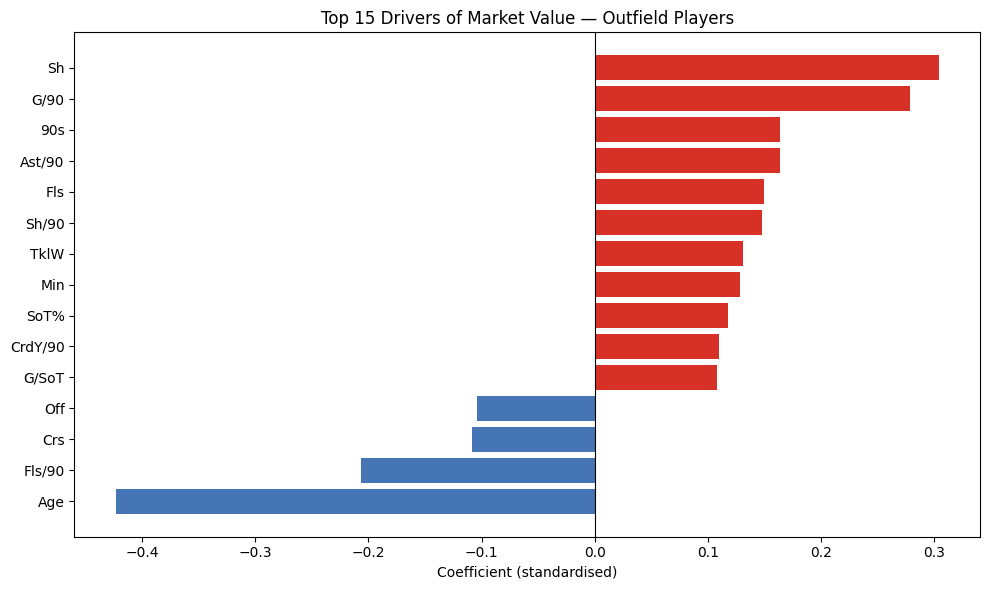


Full-data R²  : 0.394
Full-data MAE : €7,975,601

Sample predictions vs actuals:
       player_name season      actual   predicted
      Moritz Bauer  17-18  €5,000,000  €3,408,683
       Marcus Coco  16-17  €3,000,000 €16,972,857
    Kerem Demirbay  19-20 €24,000,000  €6,111,815
    Benjamin Mendy  20-21 €20,000,000  €5,312,967
    İlkay Gündoğan  18-19 €50,000,000  €4,843,798
     Claudio Yacob  17-18  €3,500,000  €1,540,050
     Joris Gnagnon  17-18 €15,000,000 €24,156,950
Maximilian Philipp  20-21  €7,000,000  €8,612,540
       Timo Werner  22-23 €25,000,000 €13,722,696
Ruben Loftus-Cheek  21-22 €20,000,000  €4,690,499

── Goalkeepers ──────────────────────────────
Rows          : 1122
CV R²         : 0.487 ± 0.033
CV MAE        : 0.735 ± 0.045  (log scale)

Top 15 drivers:
feature  coefficient
    Age    -0.567150
  Save%     0.486180
 Starts     0.329622
     CS     0.233810
  Saves     0.171467
     GA    -0.168831
Save/90    -0.166606
SoTA/90    -0.136104
   GA90    -0.125186


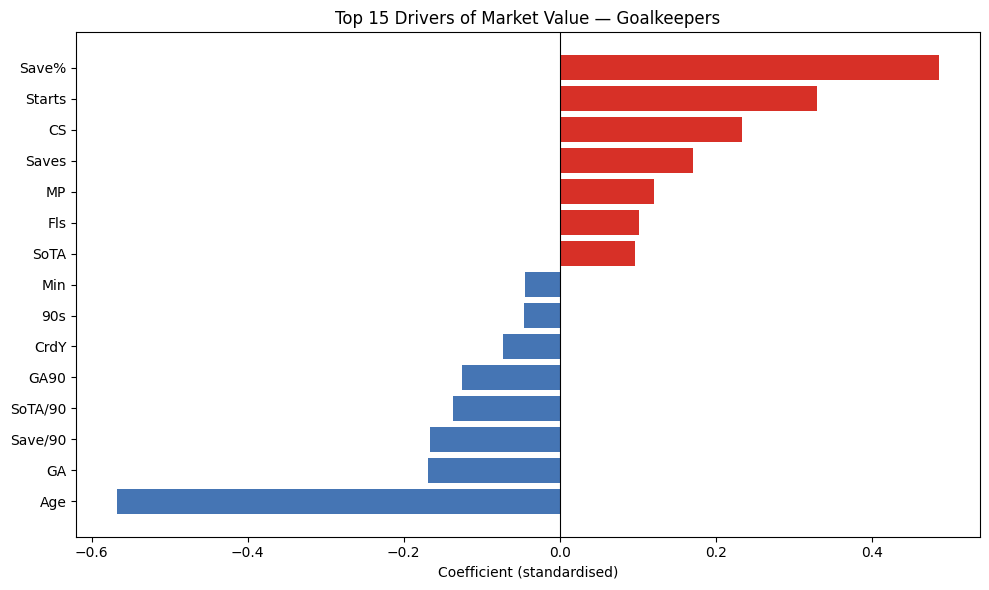


Full-data R²  : 0.523
Full-data MAE : €5,172,320

Sample predictions vs actuals:
         player_name season      actual   predicted
      Sergio Herrera  18-19    €500,000  €1,683,322
          Pepe Reina  21-22    €700,000    €465,643
     Andrea Consigli  20-21  €3,000,000  €4,146,002
         Matt Turner  23-24  €7,000,000  €1,945,342
      Walter Benítez  18-19 €10,000,000 €19,554,675
          Pepe Reina  17-18  €1,000,000  €9,771,145
Giorgi Mamardashvili  23-24 €35,000,000 €20,150,936
        Yahia Fofana  24-25  €7,000,000 €10,890,975
     Baptiste Reynet  16-17  €3,000,000  €9,057,982
        Manuel Neuer  16-17 €40,000,000 €12,528,572


In [53]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# ── 1. FILL NULLS ─────────────────────────────────────────────────────────────
gk_cols        = ["GA", "GA90", "SoTA", "Saves", "Save%", "CS", "CS%", "Save/90", "SoTA/90"]
attacking_cols = ["Sh", "SoT", "SoT%", "Sh/90", "SoT/90", "G/Sh", "G/SoT", "no_shots_flag"]
defense_cols   = ["2CrdY", "Fls", "Fld", "Off", "Crs", "Int", "TklW", "OG",
                  "DirectRCrd", "CrdY/90", "CrdR/90", "Fls/90"]

model_df[gk_cols]        = model_df[gk_cols].fillna(0)
model_df[attacking_cols] = model_df[attacking_cols].fillna(0)
model_df[defense_cols]   = model_df[defense_cols].fillna(0)

# ── 2. ENCODE POSITION ────────────────────────────────────────────────────────
def simplify_pos(pos):
    if not isinstance(pos, str):
        return "Unknown"
    pos = pos.upper()
    if "GK" in pos:
        return "GK"
    elif "DF" in pos:
        return "DF"
    elif "MF" in pos:
        return "MF"
    elif "FW" in pos:
        return "FW"
    return "Unknown"

model_df["Pos_simple"] = model_df["Pos"].apply(simplify_pos)
pos_dummies = pd.get_dummies(model_df["Pos_simple"], prefix="pos", drop_first=True)
model_df    = pd.concat([model_df, pos_dummies], axis=1)

# ── 3. LOG TRANSFORM TARGET ───────────────────────────────────────────────────
model_df["log_value"] = np.log1p(model_df["value"])

# ── 4. SPLIT INTO OUTFIELD AND GK ────────────────────────────────────────────
df_outfield = model_df[model_df["Pos_simple"] != "GK"].copy()
df_gk_model = model_df[model_df["Pos_simple"] == "GK"].copy()

print(f"Outfield rows : {len(df_outfield)}")
print(f"GK rows       : {len(df_gk_model)}")

# ── 5. DEFINE FEATURES ────────────────────────────────────────────────────────
OUTFIELD_FEATURES = [
    "Age", "MP", "Starts", "Min", "90s",
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "CrdY", "CrdR", "G/90", "Ast/90", "G-PK/90",
    "G+A-PK/90", "G+A-PK", "SubIn",
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90", "G/Sh", "G/SoT",
    "2CrdY", "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "OG", "DirectRCrd", "CrdY/90", "CrdR/90", "Fls/90",
] + [c for c in pos_dummies.columns]
OUTFIELD_FEATURES = [f for f in OUTFIELD_FEATURES if f in df_outfield.columns]

GK_FEATURES = [
    "Age", "MP", "Starts", "Min", "90s",
    "CrdY", "CrdR",
    "GA", "GA90", "SoTA", "Saves", "Save%",
    "CS", "CS%", "Save/90", "SoTA/90",
    "Fls", "Int", "TklW", "CrdY/90", "Fls/90",
]
GK_FEATURES = [f for f in GK_FEATURES if f in df_gk_model.columns]

# ── 6. MODEL FUNCTION ─────────────────────────────────────────────────────────
def run_model(df, features, label):
    X = df[features]
    y = df["log_value"]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  Ridge(alpha=10.0))
    ])

    cv_r2  = cross_val_score(pipeline, X, y, cv=5, scoring="r2")
    cv_mae = cross_val_score(pipeline, X, y, cv=5, scoring="neg_mean_absolute_error")

    print(f"\n── {label} ──────────────────────────────")
    print(f"Rows          : {len(df)}")
    print(f"CV R²         : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
    print(f"CV MAE        : {(-cv_mae.mean()):.3f} ± {cv_mae.std():.3f}  (log scale)")

    pipeline.fit(X, y)

    coef_df = (
        pd.DataFrame({
            "feature":     features,
            "coefficient": pipeline.named_steps["model"].coef_
        })
        .assign(abs_coef=lambda d: d["coefficient"].abs())
        .sort_values("abs_coef", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\nTop 15 drivers:")
    print(coef_df.head(15)[["feature", "coefficient"]].to_string(index=False))

    # Plot
    top    = coef_df.head(15).sort_values("coefficient")
    colors = ["#d73027" if c > 0 else "#4575b4" for c in top["coefficient"]]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top["feature"], top["coefficient"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Coefficient (standardised)")
    ax.set_title(f"Top 15 Drivers of Market Value — {label}")
    plt.tight_layout()
    plt.savefig(f"feature_importance_{label.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()

    # Predictions
    df = df.copy()
    df["predicted_log_value"] = pipeline.predict(X)
    df["predicted_value"]     = np.expm1(df["predicted_log_value"])

    r2  = r2_score(y, df["predicted_log_value"])
    mae = mean_absolute_error(df["value"], df["predicted_value"])

    print(f"\nFull-data R²  : {r2:.3f}")
    print(f"Full-data MAE : €{mae:,.0f}")

    print("\nSample predictions vs actuals:")
    print(
        df[["player_name", "season", "value", "predicted_value"]]
        .sample(10, random_state=42)
        .assign(
            actual    = lambda d: d["value"].map("€{:,.0f}".format),
            predicted = lambda d: d["predicted_value"].map("€{:,.0f}".format)
        )[["player_name", "season", "actual", "predicted"]]
        .to_string(index=False)
    )

    return pipeline, coef_df, df

# ── 7. RUN BOTH MODELS ────────────────────────────────────────────────────────
outfield_pipeline, outfield_coefs, df_outfield = run_model(
    df_outfield, OUTFIELD_FEATURES, "Outfield Players"
)
gk_pipeline, gk_coefs, df_gk_model = run_model(
    df_gk_model, GK_FEATURES, "Goalkeepers"
)

# ── 8. SAVE RESULTS ───────────────────────────────────────────────────────────
pd.concat([df_outfield, df_gk_model]).to_csv("model_predictions.csv", index=False)
outfield_coefs.to_csv("feature_importance_outfield.csv", index=False)
gk_coefs.to_csv("feature_importance_gk.csv", index=False)


── Outfield Players | Random Forest v2 ──────────────────────────────
Rows   : 14990
CV R²  : 0.411 ± 0.023
CV MAE : 0.794 ± 0.016  (log scale)

Top 15 drivers:
            feature  importance
                 Sh    0.220352
                Age    0.198801
             G+A-PK    0.177908
       is_declining    0.114126
                G+A    0.056391
                SoT    0.044387
                Min    0.033523
  defensive_actions    0.017833
                90s    0.017598
             Fls/90    0.014613
               TklW    0.012415
          G+A-PK/90    0.010370
goal_involvement_90    0.008967
             Starts    0.007587
               SoT%    0.007525


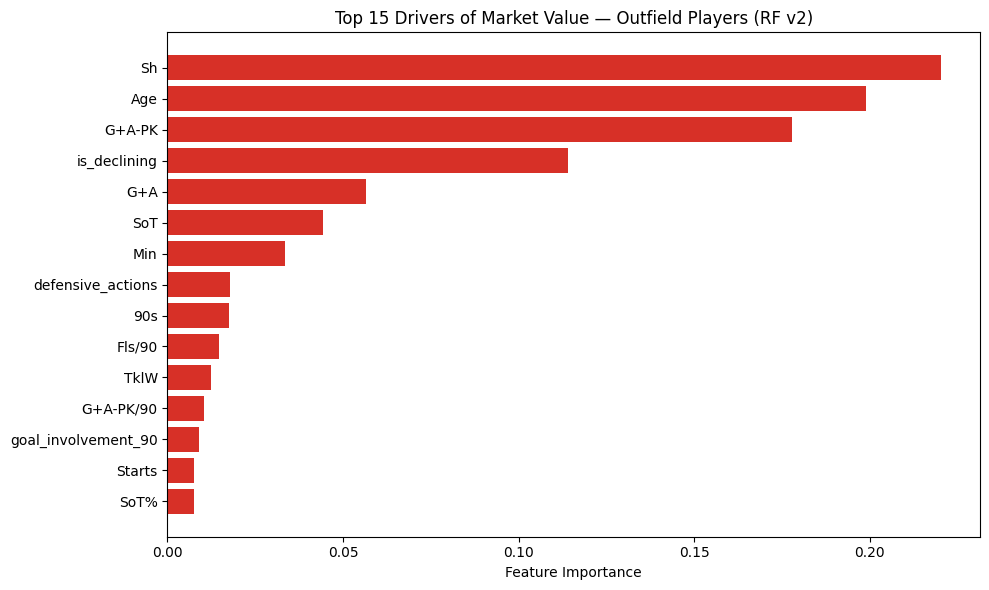


Full-data R²  : 0.446
Full-data MAE : €7,886,791

Sample predictions vs actuals:
       player_name season      actual   predicted
      Moritz Bauer  17-18  €5,000,000  €4,129,978
       Marcus Coco  16-17  €3,000,000 €12,780,397
    Kerem Demirbay  19-20 €24,000,000 €10,222,797
    Benjamin Mendy  20-21 €20,000,000  €4,955,444
    İlkay Gündoğan  18-19 €50,000,000  €8,969,826
     Claudio Yacob  17-18  €3,500,000  €2,744,674
     Joris Gnagnon  17-18 €15,000,000 €14,621,039
Maximilian Philipp  20-21  €7,000,000 €11,442,347
       Timo Werner  22-23 €25,000,000 €20,165,128
Ruben Loftus-Cheek  21-22 €20,000,000  €6,204,698

── Goalkeepers | Random Forest v2 ──────────────────────────────
Rows   : 1122
CV R²  : 0.515 ± 0.031
CV MAE : 0.717 ± 0.068  (log scale)

Top 15 drivers:
        feature  importance
            Age    0.274814
             CS    0.252405
   is_declining    0.069878
            Min    0.063553
            90s    0.056088
           GA90    0.042999
        cs_rate 

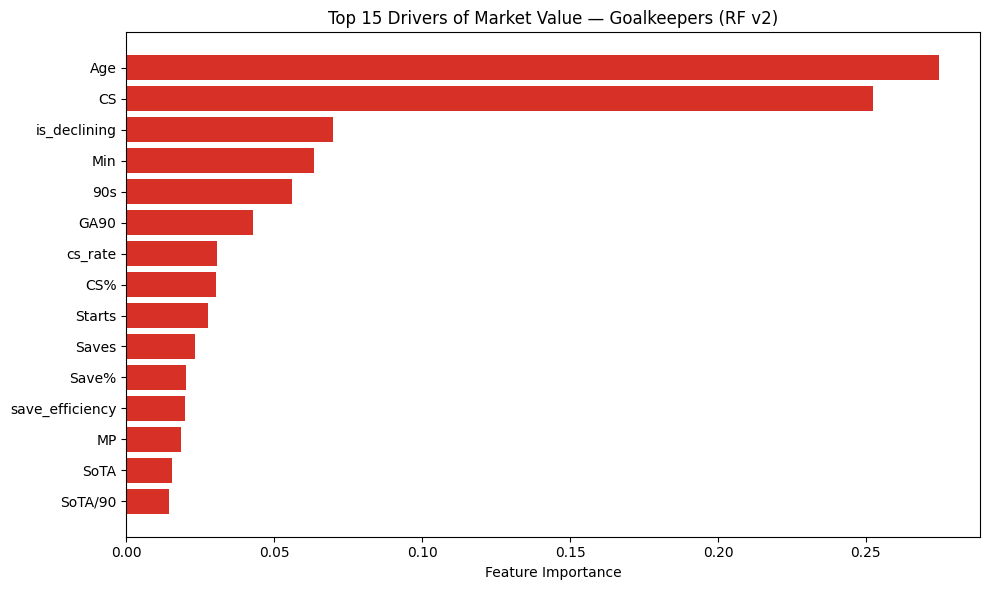


Full-data R²  : 0.652
Full-data MAE : €4,686,220

Sample predictions vs actuals:
         player_name season      actual   predicted
      Sergio Herrera  18-19    €500,000  €1,632,910
          Pepe Reina  21-22    €700,000    €589,257
     Andrea Consigli  20-21  €3,000,000  €2,893,153
         Matt Turner  23-24  €7,000,000  €2,658,888
      Walter Benítez  18-19 €10,000,000 €15,366,585
          Pepe Reina  17-18  €1,000,000  €3,157,330
Giorgi Mamardashvili  23-24 €35,000,000 €12,865,682
        Yahia Fofana  24-25  €7,000,000  €9,559,644
     Baptiste Reynet  16-17  €3,000,000  €5,883,406
        Manuel Neuer  16-17 €40,000,000 €23,808,723


In [54]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

def engineer_features(df, is_gk=False):
    df = df.copy()

    if not is_gk:
        # Peak age indicator — value peaks 23-27
        df["is_peak_age"]  = df["Age"].between(23, 27).astype(int)
        df["is_young"]     = (df["Age"] < 23).astype(int)
        df["is_declining"] = (df["Age"] > 29).astype(int)

        # Goal involvement rate — single combined metric
        df["goal_involvement_90"] = (
            df["Gls"].fillna(0) + df["Ast"].fillna(0)
        ) / df["90s"].replace(0, np.nan)

        # Shot efficiency
        df["shot_efficiency"] = df["G/SoT"].fillna(0)

        # Defensive workload
        df["defensive_actions"] = (
            df["TklW"].fillna(0) + df["Int"].fillna(0) + df["Fls"].fillna(0)
        )

    else:
        df["is_peak_age"]  = df["Age"].between(25, 32).astype(int)
        df["is_young"]     = (df["Age"] < 25).astype(int)
        df["is_declining"] = (df["Age"] > 33).astype(int)

        # GK efficiency — saves per shot on target faced
        df["save_efficiency"] = df["Save%"].fillna(0)
        df["cs_rate"]         = df["CS%"].fillna(0)

    return df

df_outfield = engineer_features(df_outfield, is_gk=False)
df_gk_model = engineer_features(df_gk_model, is_gk=True)

# Add new features to feature lists
OUTFIELD_FEATURES_V2 = OUTFIELD_FEATURES + [
    "is_peak_age", "is_young", "is_declining",
    "goal_involvement_90", "shot_efficiency", "defensive_actions"
]
OUTFIELD_FEATURES_V2 = [f for f in OUTFIELD_FEATURES_V2 if f in df_outfield.columns]

GK_FEATURES_V2 = GK_FEATURES + [
    "is_peak_age", "is_young", "is_declining",
    "save_efficiency", "cs_rate"
]
GK_FEATURES_V2 = [f for f in GK_FEATURES_V2 if f in df_gk_model.columns]

def run_model(df, features, label):
    X = df[features].fillna(0)
    y = df["log_value"]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  RandomForestRegressor(
            n_estimators=500,
            max_depth=6,          # reduced from 10 to reduce overfitting
            min_samples_leaf=10,  # increased to reduce overfitting
            max_features=0.6,     # use 60% of features per split
            n_jobs=-1,
            random_state=42
        ))
    ])

    cv_r2  = cross_val_score(pipeline, X, y, cv=5, scoring="r2")
    cv_mae = cross_val_score(pipeline, X, y, cv=5, scoring="neg_mean_absolute_error")

    print(f"\n── {label} | Random Forest v2 ──────────────────────────────")
    print(f"Rows   : {len(df)}")
    print(f"CV R²  : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
    print(f"CV MAE : {(-cv_mae.mean()):.3f} ± {cv_mae.std():.3f}  (log scale)")

    pipeline.fit(X, y)
    importances = pipeline.named_steps["model"].feature_importances_

    coef_df = (
        pd.DataFrame({"feature": features, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\nTop 15 drivers:")
    print(coef_df.head(15).to_string(index=False))

    # Plot
    top = coef_df.head(15).sort_values("importance")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top["feature"], top["importance"], color="#d73027")
    ax.set_xlabel("Feature Importance")
    ax.set_title(f"Top 15 Drivers of Market Value — {label} (RF v2)")
    plt.tight_layout()
    plt.savefig(f"feature_importance_{label.lower().replace(' ', '_')}_rf_v2.png", dpi=150)
    plt.show()

    # Predictions
    df = df.copy()
    df["predicted_log_value"] = pipeline.predict(X)
    df["predicted_value"]     = np.expm1(df["predicted_log_value"])

    r2  = r2_score(y, df["predicted_log_value"])
    mae = mean_absolute_error(df["value"], df["predicted_value"])

    print(f"\nFull-data R²  : {r2:.3f}")
    print(f"Full-data MAE : €{mae:,.0f}")

    print("\nSample predictions vs actuals:")
    print(
        df[["player_name", "season", "value", "predicted_value"]]
        .sample(10, random_state=42)
        .assign(
            actual    = lambda d: d["value"].map("€{:,.0f}".format),
            predicted = lambda d: d["predicted_value"].map("€{:,.0f}".format)
        )[["player_name", "season", "actual", "predicted"]]
        .to_string(index=False)
    )

    return pipeline, coef_df, df

# ── Run both models ───────────────────────────────────────────────────────────
outfield_pipeline, outfield_coefs, df_outfield = run_model(
    df_outfield, OUTFIELD_FEATURES_V2, "Outfield Players"
)
gk_pipeline, gk_coefs, df_gk_model = run_model(
    df_gk_model, GK_FEATURES_V2, "Goalkeepers"
)

# ── Save ──────────────────────────────────────────────────────────────────────
pd.concat([df_outfield, df_gk_model]).to_csv("model_predictions_v2.csv", index=False)
outfield_coefs.to_csv("feature_importance_outfield_rf_v2.csv", index=False)
gk_coefs.to_csv("feature_importance_gk_rf_v2.csv", index=False)

# ── Add league and club tier features ────────────────────────────────────────
# League tier — top 5 leagues command higher values
league_tier = {
    "Premier League": 1,
    "La Liga":        1,
    "Serie A":        1,
    "Bundesliga":     1,
    "Ligue 1":        1,
    "Eredivisie":     2,
    "Primeira Liga":  2,
    "Liga NOS":       2,
    "Süper Lig":      2,
    "Scottish Prem":  3,
}

Club tier distribution:
club_tier
1    2869
2    8436
3    4807
Name: count, dtype: int64

Still in Tier 3 that look like they should be higher (top 20):
Squad
Brest          128
Reims          122
Burnley        120
Granada        120
Schalke 04     120
Bordeaux       116
Getafe         114
Lorient        113
Stuttgart      112
Toulouse       110
Valladolid     108
Espanyol       107
Bournemouth    107
Levante        103
Empoli         100
Fulham          88
Parma           88
Eibar           88
Elche           85
Mallorca        84
Name: count, dtype: int64

── Outfield Players | Random Forest v2 ──────────────────────────────
Rows   : 14990
CV R²  : 0.585 ± 0.012
CV MAE : 0.643 ± 0.015  (log scale)

Top 15 drivers:
  feature  importance
club_tier    0.428412
      Age    0.213372
       Sh    0.142880
   G+A-PK    0.053611
      SoT    0.038970
      G+A    0.031211
      Min    0.027142
      90s    0.013880
     TklW    0.011520
   Starts    0.009357
    G/SoT    0.003326
    Sh/9

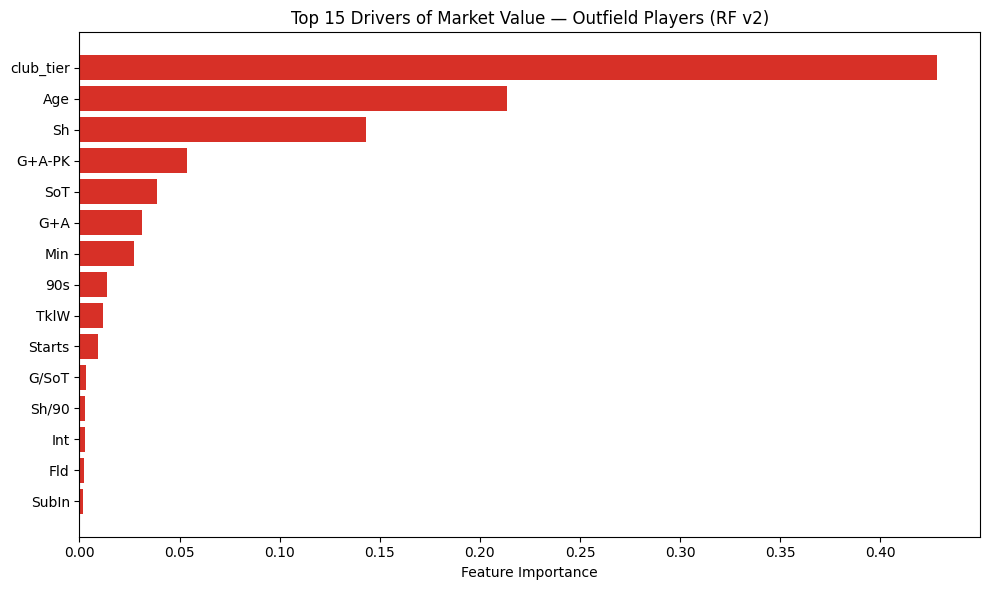


Full-data R²  : 0.606
Full-data MAE : €6,149,889

Sample predictions vs actuals:
       player_name season      actual   predicted
      Moritz Bauer  17-18  €5,000,000  €2,664,561
       Marcus Coco  16-17  €3,000,000  €6,563,921
    Kerem Demirbay  19-20 €24,000,000  €8,219,266
    Benjamin Mendy  20-21 €20,000,000 €16,324,389
    İlkay Gündoğan  18-19 €50,000,000 €29,317,925
     Claudio Yacob  17-18  €3,500,000  €1,903,161
     Joris Gnagnon  17-18 €15,000,000 €11,387,201
Maximilian Philipp  20-21  €7,000,000  €8,231,464
       Timo Werner  22-23 €25,000,000 €43,828,166
Ruben Loftus-Cheek  21-22 €20,000,000 €21,560,222

── Goalkeepers | Random Forest v2 ──────────────────────────────
Rows   : 1122
CV R²  : 0.608 ± 0.039
CV MAE : 0.651 ± 0.040  (log scale)

Top 15 drivers:
  feature  importance
      Age    0.315496
       CS    0.217640
club_tier    0.175702
      Min    0.057746
      90s    0.052618
    Saves    0.028952
   Starts    0.028777
    Save%    0.022025
     GA90    0

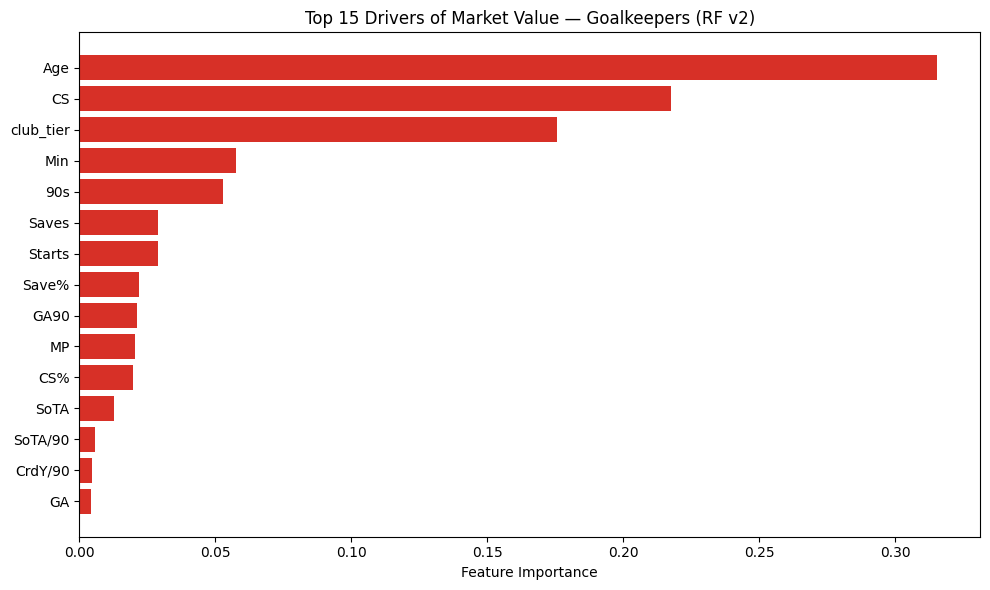


Full-data R²  : 0.728
Full-data MAE : €3,941,665

Sample predictions vs actuals:
         player_name season      actual   predicted
      Sergio Herrera  18-19    €500,000  €1,891,193
          Pepe Reina  21-22    €700,000    €581,907
     Andrea Consigli  20-21  €3,000,000  €2,931,714
         Matt Turner  23-24  €7,000,000  €2,039,752
      Walter Benítez  18-19 €10,000,000 €11,344,066
          Pepe Reina  17-18  €1,000,000  €4,735,647
Giorgi Mamardashvili  23-24 €35,000,000 €12,191,261
        Yahia Fofana  24-25  €7,000,000  €8,909,343
     Baptiste Reynet  16-17  €3,000,000  €3,846,150
        Manuel Neuer  16-17 €40,000,000 €25,194,760


In [55]:
# Adding Club Tiers
club_tier = {
    # Tier 1 — Elite
    "Manchester City":      1, "Liverpool":            1,
    "Chelsea":              1, "Arsenal":              1,
    "Manchester Utd":       1, "Tottenham":            1,
    "Tottenham Hotspur":    1,
    "Real Madrid":          1, "Barcelona":            1,
    "Atlético Madrid":      1, "Atletico Madrid":      1,
    "Bayern Munich":        1, "Borussia Dortmund":    1,
    "Dortmund":             1,
    "RB Leipzig":           1,
    "Paris S-G":            1, "Paris Saint-Germain":  1,
    "Juventus":             1, "Inter":                1,
    "AC Milan":             1, "Milan":                1,
    "Napoli":               1,

    # Tier 2 — Strong
    "Sevilla":              2, "Valencia":             2,
    "Real Sociedad":        2, "Villarreal":           2,
    "Athletic Club":        2, "Real Betis":           2,
    "Celta Vigo":           2, "Osasuna":              2,
    "Alavés":               2,
    "Bayer Leverkusen":     2, "Leverkusen":           2,
    "Eintracht Frankfurt":  2, "Freiburg":             2,
    "Wolfsburg":            2, "Gladbach":             2,
    "Union Berlin":         2, "Hoffenheim":           2,
    "Werder Bremen":        2, "Augsburg":             2,
    "Mainz 05":             2, "Hertha BSC":           2,
    "Köln":                 2,
    "Lyon":                 2, "Marseille":            2,
    "Monaco":               2, "Lille":                2,
    "Rennes":               2, "Lens":                 2,
    "Nice":                 2, "Nantes":               2,
    "Montpellier":          2, "Saint-Étienne":        2,
    "Strasbourg":           2, "Angers":               2,
    "Metz":                 2,
    "Atalanta":             2, "Roma":                 2,
    "Lazio":                2, "Fiorentina":           2,
    "Torino":               2, "Bologna":              2,
    "Sassuolo":             2, "Udinese":              2,
    "Sampdoria":            2, "Genoa":                2,
    "Hellas Verona":        2, "Cagliari":             2,
    "West Ham":             2, "West Ham United":      2,
    "Leicester City":       2, "Everton":              2,
    "Newcastle Utd":        2, "Newcastle United":     2,
    "Aston Villa":          2, "Brighton":             2,
    "Wolves":               2, "Crystal Palace":       2,
    "Southampton":          2,
}

def get_club_tier(squad):
    if not isinstance(squad, str):
        return 3
    return club_tier.get(squad, 3)

model_df["club_tier"] = model_df["Squad"].apply(get_club_tier)

# Re-split after adding club_tier
df_outfield = model_df[model_df["Pos_simple"] != "GK"].copy()
df_gk_model = model_df[model_df["Pos_simple"] == "GK"].copy()

print("Club tier distribution:")
print(model_df["club_tier"].value_counts().sort_index())

print("\nStill in Tier 3 that look like they should be higher (top 20):")
print(
    model_df[model_df["club_tier"] == 3]["Squad"]
    .value_counts()
    .head(20)
)

# ── Add club_tier to feature lists ───────────────────────────────────────────
OUTFIELD_FEATURES_V3 = OUTFIELD_FEATURES_V2 + ["club_tier"]
OUTFIELD_FEATURES_V3 = [f for f in OUTFIELD_FEATURES_V3 if f in df_outfield.columns]

GK_FEATURES_V3 = GK_FEATURES_V2 + ["club_tier"]
GK_FEATURES_V3 = [f for f in GK_FEATURES_V3 if f in df_gk_model.columns]

# ── Re-run models ─────────────────────────────────────────────────────────────
outfield_pipeline, outfield_coefs, df_outfield = run_model(
    df_outfield, OUTFIELD_FEATURES_V3, "Outfield Players"
)
gk_pipeline, gk_coefs, df_gk_model = run_model(
    df_gk_model, GK_FEATURES_V3, "Goalkeepers"
)

# ── Save ──────────────────────────────────────────────────────────────────────
pd.concat([df_outfield, df_gk_model]).to_csv("model_predictions_v3.csv", index=False)
outfield_coefs.to_csv("feature_importance_outfield_rf_v3.csv", index=False)
gk_coefs.to_csv("feature_importance_gk_rf_v3.csv", index=False)


── Outfield Players | Final Random Forest ──────────────────────────────
Train rows    : 11992
Test rows     : 2998
CV R²         : 0.615 ± 0.011  (train set)
CV MAE        : 0.609 ± 0.012  (log scale)
Test R²       : 0.633  ← honest performance on unseen data
Test MAE      : €5,871,577
Test MSE   : 112,664,379,266,242
Test RMSE  : €10,614,348

Top 15 drivers:
          feature  importance
        club_tier    0.321918
              Age    0.125922
               Sh    0.101197
     is_declining    0.067102
           G+A-PK    0.047272
              Min    0.039722
              SoT    0.030876
              G+A    0.026260
     min_per_game    0.022706
           Starts    0.019212
           Fls/90    0.015754
defensive_actions    0.015574
              Crs    0.012131
             TklW    0.010597
            Sh/90    0.010198


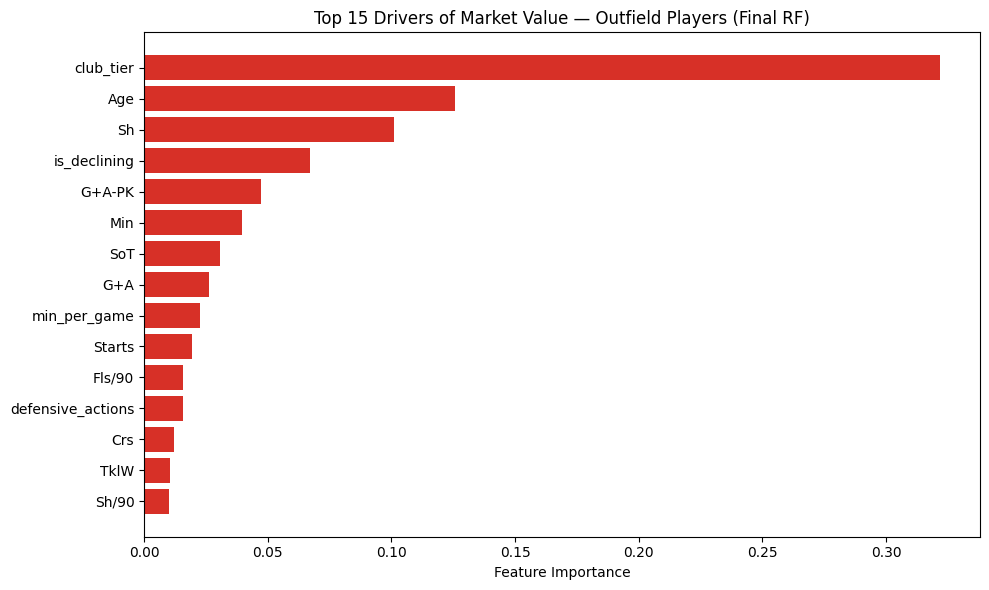


Worst 10 predictions on TEST SET:
      player_name season       actual    predicted       error
      Bukayo Saka  24-25 €150,000,000  €55,079,302 €94,920,698
  Vinicius Junior  22-23 €150,000,000  €72,791,042 €77,208,958
   Erling Haaland  22-23 €180,000,000 €106,095,701 €73,904,299
       Phil Foden  22-23 €110,000,000  €42,347,618 €67,652,382
Christian Eriksen  18-19 €100,000,000  €33,046,628 €66,953,372
      Declan Rice  24-25 €120,000,000  €54,485,464 €65,514,536
    Mohamed Salah  18-19 €150,000,000  €88,735,179 €61,264,821
  Bruno Guimarães  23-24  €85,000,000  €24,213,628 €60,786,372
   Enzo Fernández  22-23  €80,000,000  €21,270,471 €58,729,529
      Bukayo Saka  23-24 €140,000,000  €82,414,307 €57,585,693

Sample predictions from TEST SET:
        player_name season      actual   predicted
      Joris Gnagnon  17-18 €15,000,000 €20,239,982
       Frank Onyeka  21-22  €9,000,000  €2,291,942
Alireza Jahanbakhsh  19-20  €6,500,000  €2,246,698
      Mads Pedersen  22-23  €3,50

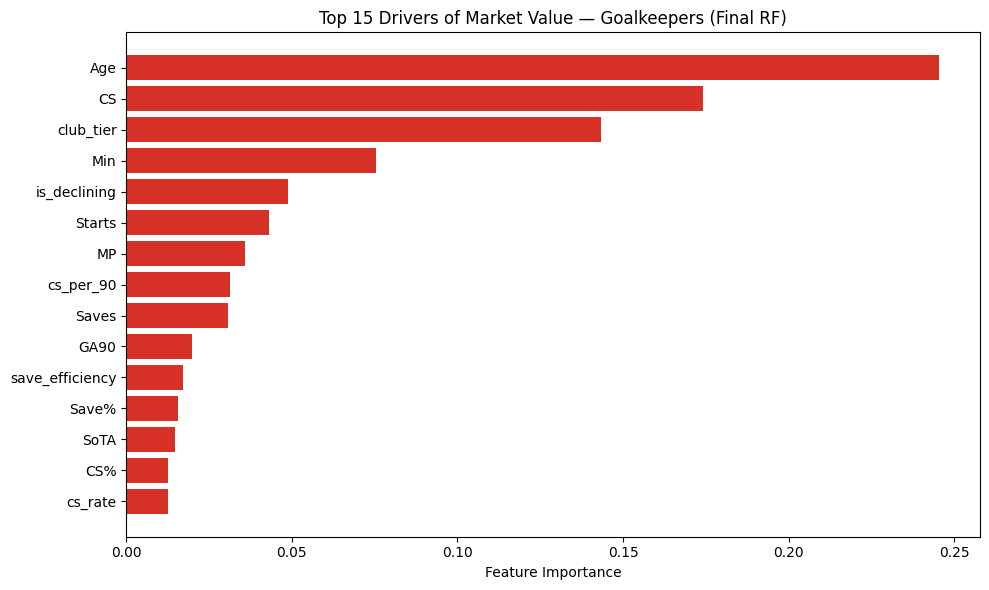


Worst 10 predictions on TEST SET:
         player_name season      actual   predicted       error
             Alisson  19-20 €72,000,000  €7,840,974 €64,159,026
        David de Gea  18-19 €65,000,000 €21,364,954 €43,635,046
   Kepa Arrizabalaga  18-19 €60,000,000 €22,514,978 €37,485,022
    Thibaut Courtois  18-19 €55,000,000 €22,417,177 €32,582,823
           Jan Oblak  19-20 €80,000,000 €50,461,286 €29,538,714
             Alisson  22-23 €35,000,000 €10,021,914 €24,978,086
Gianluigi Donnarumma  20-21 €60,000,000 €36,159,194 €23,840,806
Giorgi Mamardashvili  23-24 €35,000,000 €13,132,616 €21,867,384
        Gregor Kobel  23-24 €40,000,000 €20,127,785 €19,872,215
             Alisson  23-24 €28,000,000  €9,113,476 €18,886,524

Sample predictions from TEST SET:
      player_name season      actual   predicted
       Alex Meret  22-23 €18,000,000 €27,919,262
      Rubén Yáñez  19-20    €300,000    €970,849
  Lorenzo Montipò  23-24  €3,500,000 €10,639,179
 Stéphane Ruffier  16-17  €6,0

In [56]:
#Random Forests
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# ── 1. FEATURE ENGINEERING ────────────────────────────────────────────────────
def engineer_features(df, is_gk=False):
    df = df.copy()

    if not is_gk:
        df["is_peak_age"]  = df["Age"].between(23, 27).astype(int)
        df["is_young"]     = (df["Age"] < 23).astype(int)
        df["is_declining"] = (df["Age"] > 29).astype(int)

        df["goal_involvement_90"] = (
            df["Gls"].fillna(0) + df["Ast"].fillna(0)
        ) / df["90s"].replace(0, np.nan)

        df["shot_efficiency"]     = df["G/SoT"].fillna(0)

        df["defensive_actions"]   = (
            df["TklW"].fillna(0) + df["Int"].fillna(0) + df["Fls"].fillna(0)
        )

        df["min_per_game"]        = (
            df["Min"].fillna(0) / df["MP"].replace(0, np.nan)
        )

        df["goal_contrib_per_sh"] = (
            df["G+A-PK"].fillna(0) / df["Sh"].replace(0, np.nan)
        )

    else:
        df["is_peak_age"]  = df["Age"].between(25, 32).astype(int)
        df["is_young"]     = (df["Age"] < 25).astype(int)
        df["is_declining"] = (df["Age"] > 33).astype(int)

        df["save_efficiency"] = df["Save%"].fillna(0)
        df["cs_rate"]         = df["CS%"].fillna(0)

        df["cs_per_90"]    = (
            df["CS"].fillna(0) / df["90s"].replace(0, np.nan)
        )

        df["ga_per_sota"]  = (
            df["GA"].fillna(0) / df["SoTA"].replace(0, np.nan)
        )

    return df

# ── 2. APPLY FEATURE ENGINEERING ─────────────────────────────────────────────
df_outfield = engineer_features(df_outfield, is_gk=False)
df_gk_model = engineer_features(df_gk_model, is_gk=True)

# ── 3. FEATURE LISTS ──────────────────────────────────────────────────────────
OUTFIELD_FEATURES_FINAL = [
    # Context
    "club_tier",
    # Age
    "Age", "is_peak_age", "is_young", "is_declining",
    # Playing time
    "MP", "Starts", "Min", "SubIn", "min_per_game",# "90s"
    # Goal output
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",
    # Rates
    "G/90", "Ast/90", "goal_involvement_90",
    # Shooting
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",
    # Defense
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",
    # Discipline
    "CrdY", "CrdR",
    # Position dummies
] + [c for c in pos_dummies.columns]
OUTFIELD_FEATURES_FINAL = [
    f for f in OUTFIELD_FEATURES_FINAL if f in df_outfield.columns
]

GK_FEATURES_FINAL = [
    # Context
    "club_tier",
    # Age
    "Age", "is_peak_age", "is_young", "is_declining",
    # Playing time
    "MP", "Starts", "Min",# "90s",
    # GK core
    "GA", "GA90", "SoTA", "Saves", "Save%",
    "CS", "CS%", "Save/90", "SoTA/90",
    # Engineered
    "save_efficiency", "cs_rate", "cs_per_90", "ga_per_sota",
    # Discipline
    "CrdY", "CrdR", "CrdY/90", "Fls/90",
    "Fls", "Int", "TklW",
]
GK_FEATURES_FINAL = [
    f for f in GK_FEATURES_FINAL if f in df_gk_model.columns
]

# ── 4. MODEL FUNCTION ─────────────────────────────────────────────────────────
def run_final_rf_model(df, features, label):
    X = df[features].fillna(0)
    y = df["log_value"]

    # 80/20 train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  RandomForestRegressor(
            n_estimators=700,
            max_depth=12,
            min_samples_leaf=5,
            max_features=0.6,
            n_jobs=-1,
            random_state=42
        ))
    ])

    # CV on training set only
    cv_r2  = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="r2")
    cv_mae = cross_val_score(pipeline, X_train, y_train, cv=5,
                             scoring="neg_mean_absolute_error")

    # Fit on full training set
    pipeline.fit(X_train, y_train)

    # Evaluate on holdout test set
    test_preds = pipeline.predict(X_test)
    test_r2    = r2_score(y_test, test_preds)
    test_mae   = mean_absolute_error(
        np.expm1(y_test), np.expm1(test_preds)
    )
    # MSE
    test_mse = mean_squared_error(
    np.expm1(y_test),
    np.expm1(test_preds)
    )

    # RMSE
    test_rmse = np.sqrt(test_mse)

    print(f"\n── {label} | Final Random Forest ──────────────────────────────")
    print(f"Train rows    : {len(X_train)}")
    print(f"Test rows     : {len(X_test)}")
    print(f"CV R²         : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}  (train set)")
    print(f"CV MAE        : {(-cv_mae.mean()):.3f} ± {cv_mae.std():.3f}  (log scale)")
    print(f"Test R²       : {test_r2:.3f}  ← honest performance on unseen data")
    print(f"Test MAE      : €{test_mae:,.0f}")
    print(f"Test MSE   : {test_mse:,.0f}")
    print(f"Test RMSE  : €{test_rmse:,.0f}")

    # Feature importance
    importances = pipeline.named_steps["model"].feature_importances_
    coef_df = (
        pd.DataFrame({"feature": features, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\nTop 15 drivers:")
    print(coef_df.head(15).to_string(index=False))

    # Plot
    top    = coef_df.head(15).sort_values("importance")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top["feature"], top["importance"], color="#d73027")
    ax.set_xlabel("Feature Importance")
    ax.set_title(f"Top 15 Drivers of Market Value — {label} (Final RF)")
    plt.tight_layout()
    plt.savefig(
        f"feature_importance_{label.lower().replace(' ', '_')}_final.png",
        dpi=150
    )
    plt.show()

    # Predictions on full dataset
    df = df.copy()
    df["predicted_log_value"] = pipeline.predict(X)
    df["predicted_value"]     = np.expm1(df["predicted_log_value"])
    df["in_test_set"]         = False
    df.loc[X_test.index, "in_test_set"] = True

    # Evaluate on test set rows only
    test_df = df[df["in_test_set"]].copy()
    test_df["abs_error"] = (test_df["value"] - test_df["predicted_value"]).abs()

    print(f"\nWorst 10 predictions on TEST SET:")
    print(
        test_df.nlargest(10, "abs_error")
        .assign(
            actual    = lambda d: d["value"].map("€{:,.0f}".format),
            predicted = lambda d: d["predicted_value"].map("€{:,.0f}".format),
            error     = lambda d: d["abs_error"].map("€{:,.0f}".format)
        )[["player_name", "season", "actual", "predicted", "error"]]
        .to_string(index=False)
    )

    print(f"\nSample predictions from TEST SET:")
    print(
        test_df[["player_name", "season", "value", "predicted_value"]]
        .sample(10, random_state=42)
        .assign(
            actual    = lambda d: d["value"].map("€{:,.0f}".format),
            predicted = lambda d: d["predicted_value"].map("€{:,.0f}".format)
        )[["player_name", "season", "actual", "predicted"]]
        .to_string(index=False)
    )

    return pipeline, coef_df, df

# ── 5. RUN BOTH MODELS ────────────────────────────────────────────────────────
outfield_rf_pipeline, outfield_rf_coefs, df_outfield = run_final_rf_model(
    df_outfield, OUTFIELD_FEATURES_FINAL, "Outfield Players"
)
gk_rf_pipeline, gk_rf_coefs, df_gk_model = run_final_rf_model(
    df_gk_model, GK_FEATURES_FINAL, "Goalkeepers"
)

# ── 6. SAVE EVERYTHING ───────────────────────────────────────────────────────
pd.concat([df_outfield, df_gk_model]).to_csv("model_predictions_rf_final.csv", index=False)
outfield_rf_coefs.to_csv("feature_importance_outfield_rf_final.csv", index=False)
gk_rf_coefs.to_csv("feature_importance_gk_rf_final.csv",             index=False)

print("\nAll files saved.")


── Outfield Players | Linear Regression ──────────────────────────────
Train rows    : 11992
Test rows     : 2998
CV R²         : 0.576 ± 0.015  (train set)
CV MAE        : 0.639 ± 0.012  (log scale)
Test R²       : 0.590  ← honest performance on unseen data
Test MAE      : €6,231,560
Test MSE   : 127,322,921,093,611
Test RMSE  : €11,283,746

Top 15 drivers (by absolute coefficient):
     feature  coefficient
   club_tier    -0.556953
         Age    -0.427041
        G/90     0.369536
         Min     0.257785
     G-PK/90    -0.225762
      Fls/90    -0.195798
          Sh     0.193374
    is_young    -0.187423
is_declining    -0.170253
         Fls     0.141032
     CrdY/90     0.111133
      Ast/90     0.099326
       Sh/90     0.091723
        CrdY    -0.076853
        SoT%     0.074487


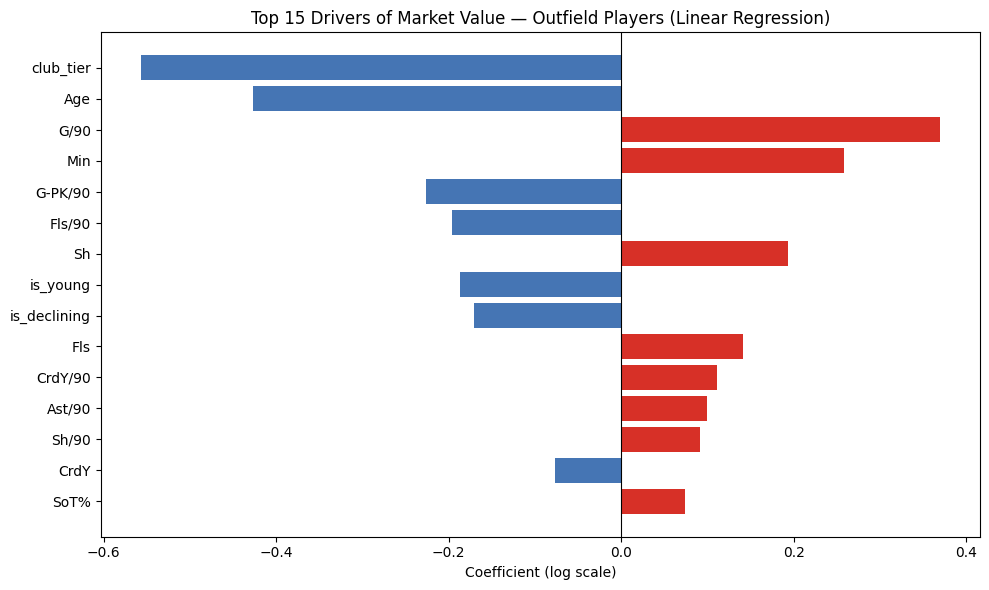


Worst 10 predictions on TEST SET:
      player_name season       actual    predicted       error
      Bukayo Saka  24-25 €150,000,000  €52,732,870 €97,267,130
      Declan Rice  24-25 €120,000,000  €40,211,163 €79,788,837
  Vinicius Junior  22-23 €150,000,000  €72,675,807 €77,324,193
       Phil Foden  22-23 €110,000,000  €35,530,620 €74,469,380
     Mauro Icardi  16-17  €50,000,000 €123,041,717 €73,041,717
Christian Eriksen  18-19 €100,000,000  €32,848,572 €67,151,428
   Erling Haaland  22-23 €180,000,000 €114,593,707 €65,406,293
   Erling Haaland  21-22 €150,000,000  €84,732,653 €65,267,347
       Paul Pogba  19-20  €80,000,000  €14,851,551 €65,148,449
  Federico Chiesa  19-20  €48,000,000 €107,176,156 €59,176,156

Sample predictions from TEST SET:
        player_name season      actual   predicted
      Joris Gnagnon  17-18 €15,000,000 €18,091,287
       Frank Onyeka  21-22  €9,000,000  €2,321,900
Alireza Jahanbakhsh  19-20  €6,500,000  €2,813,375
      Mads Pedersen  22-23  €3,50

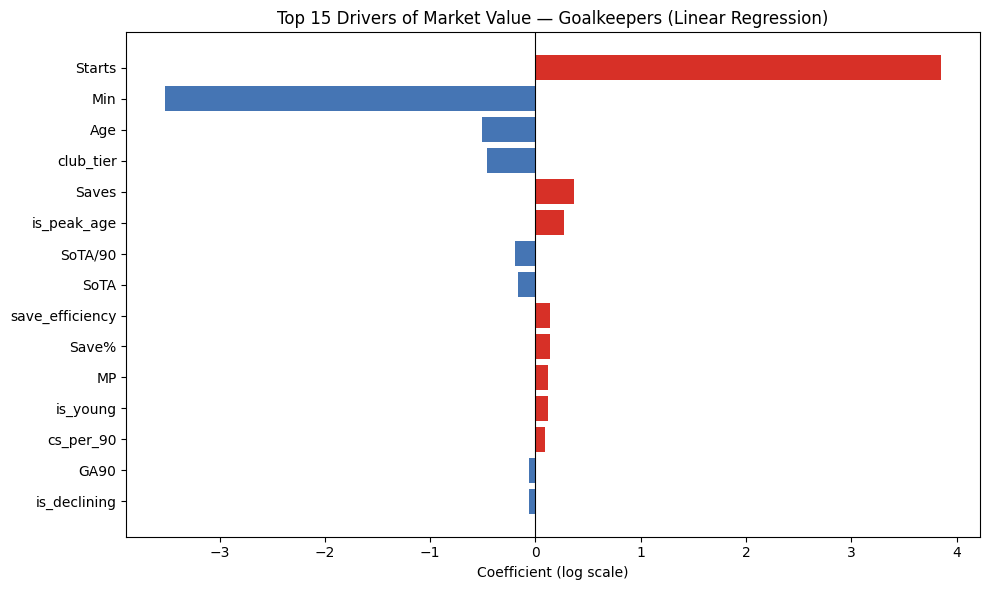


Worst 10 predictions on TEST SET:
      player_name season      actual   predicted       error
          Alisson  19-20 €72,000,000  €8,678,505 €63,321,495
     David de Gea  18-19 €65,000,000 €22,611,786 €42,388,214
        Jan Oblak  19-20 €80,000,000 €37,893,426 €42,106,574
 Thibaut Courtois  18-19 €55,000,000 €19,886,038 €35,113,962
Kepa Arrizabalaga  18-19 €60,000,000 €25,039,396 €34,960,604
          Alisson  22-23 €35,000,000  €8,013,303 €26,986,697
        Jan Oblak  21-22 €45,000,000 €21,939,533 €23,060,467
          Alisson  23-24 €28,000,000  €5,004,647 €22,995,353
     Manuel Neuer  16-17 €40,000,000 €18,097,789 €21,902,211
     David de Gea  19-20 €40,000,000 €20,181,668 €19,818,332

Sample predictions from TEST SET:
      player_name season      actual   predicted
       Alex Meret  22-23 €18,000,000 €36,800,641
      Rubén Yáñez  19-20    €300,000  €1,020,344
  Lorenzo Montipò  23-24  €3,500,000 €11,914,742
 Stéphane Ruffier  16-17  €6,000,000 €10,020,484
     Mike Maig

In [57]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# ── 1. FEATURE ENGINEERING ────────────────────────────────────────────────────
def engineer_features(df, is_gk=False):
    df = df.copy()

    if not is_gk:
        df["is_peak_age"]  = df["Age"].between(23, 27).astype(int)
        df["is_young"]     = (df["Age"] < 23).astype(int)
        df["is_declining"] = (df["Age"] > 29).astype(int)

        df["goal_involvement_90"] = (
            df["Gls"].fillna(0) + df["Ast"].fillna(0)
        ) / df["90s"].replace(0, np.nan)

        df["shot_efficiency"]     = df["G/SoT"].fillna(0)

        df["defensive_actions"]   = (
            df["TklW"].fillna(0) + df["Int"].fillna(0) + df["Fls"].fillna(0)
        )

        df["min_per_game"]        = (
            df["Min"].fillna(0) / df["MP"].replace(0, np.nan)
        )

        df["goal_contrib_per_sh"] = (
            df["G+A-PK"].fillna(0) / df["Sh"].replace(0, np.nan)
        )

    else:
        df["is_peak_age"]  = df["Age"].between(25, 32).astype(int)
        df["is_young"]     = (df["Age"] < 25).astype(int)
        df["is_declining"] = (df["Age"] > 33).astype(int)

        df["save_efficiency"] = df["Save%"].fillna(0)
        df["cs_rate"]         = df["CS%"].fillna(0)

        df["cs_per_90"]    = (
            df["CS"].fillna(0) / df["90s"].replace(0, np.nan)
        )

        df["ga_per_sota"]  = (
            df["GA"].fillna(0) / df["SoTA"].replace(0, np.nan)
        )

    return df

# ── 2. APPLY FEATURE ENGINEERING ─────────────────────────────────────────────
df_outfield = engineer_features(df_outfield, is_gk=False)
df_gk_model = engineer_features(df_gk_model, is_gk=True)

# ── 3. FEATURE LISTS ──────────────────────────────────────────────────────────
OUTFIELD_FEATURES_FINAL = [
    "club_tier",
    "Age", "is_peak_age", "is_young", "is_declining",
    "MP", "Starts", "Min", "SubIn", "min_per_game",
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",
    "G/90", "Ast/90", "goal_involvement_90",
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",
    "CrdY", "CrdR", #"90s",
] + [c for c in pos_dummies.columns]
OUTFIELD_FEATURES_FINAL = [
    f for f in OUTFIELD_FEATURES_FINAL if f in df_outfield.columns
]

GK_FEATURES_FINAL = [
    "club_tier",
    "Age", "is_peak_age", "is_young", "is_declining",
    "MP", "Starts", "Min",
    "GA", "GA90", "SoTA", "Saves", "Save%",
    "CS", "CS%", "Save/90", "SoTA/90",
    "save_efficiency", "cs_rate", "cs_per_90", "ga_per_sota",
    "CrdY", "CrdR", "CrdY/90", "Fls/90",
    "Fls", "Int", "TklW",#, "90s",
]
GK_FEATURES_FINAL = [
    f for f in GK_FEATURES_FINAL if f in df_gk_model.columns
]

# ── 4. MODEL FUNCTION ─────────────────────────────────────────────────────────
def run_final_lr_model(df, features, label):
    X = df[features].fillna(0)
    y = df["log_value"]

    # 80/20 train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LinearRegression())  # No hyperparameters needed
    ])

    # CV on training set only
    cv_r2  = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="r2")
    cv_mae = cross_val_score(pipeline, X_train, y_train, cv=5,
                             scoring="neg_mean_absolute_error")

    # Fit on full training set
    pipeline.fit(X_train, y_train)

    # Evaluate on holdout test set
    test_preds = pipeline.predict(X_test)
    test_r2    = r2_score(y_test, test_preds)
    test_mae   = mean_absolute_error(
        np.expm1(y_test), np.expm1(test_preds)
    )
    # MSE
    test_mse = mean_squared_error(
    np.expm1(y_test),
    np.expm1(test_preds)
    )

    # RMSE
    test_rmse = np.sqrt(test_mse)

    print(f"\n── {label} | Linear Regression ──────────────────────────────")
    print(f"Train rows    : {len(X_train)}")
    print(f"Test rows     : {len(X_test)}")
    print(f"CV R²         : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}  (train set)")
    print(f"CV MAE        : {(-cv_mae.mean()):.3f} ± {cv_mae.std():.3f}  (log scale)")
    print(f"Test R²       : {test_r2:.3f}  ← honest performance on unseen data")
    print(f"Test MAE      : €{test_mae:,.0f}")
    print(f"Test MSE   : {test_mse:,.0f}")
    print(f"Test RMSE  : €{test_rmse:,.0f}")

    # Coefficients instead of feature importances
    coefficients = pipeline.named_steps["model"].coef_
    coef_df = (
        pd.DataFrame({"feature": features, "coefficient": coefficients})
        .assign(abs_coefficient=lambda d: d["coefficient"].abs())
        .sort_values("abs_coefficient", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\nTop 15 drivers (by absolute coefficient):")
    print(coef_df[["feature", "coefficient"]].head(15).to_string(index=False))

    # Plot
    top = coef_df.head(15).sort_values("abs_coefficient")
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ["#d73027" if c > 0 else "#4575b4" for c in top["coefficient"]]
    ax.barh(top["feature"], top["coefficient"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Coefficient (log scale)")
    ax.set_title(f"Top 15 Drivers of Market Value — {label} (Linear Regression)")
    plt.tight_layout()
    plt.savefig(
        f"feature_importance_{label.lower().replace(' ', '_')}_lr.png",
        dpi=150
    )
    plt.show()

    # Predictions on full dataset
    df = df.copy()
    df["predicted_log_value"] = pipeline.predict(X)
    df["predicted_value"]     = np.expm1(df["predicted_log_value"])
    df["in_test_set"]         = False
    df.loc[X_test.index, "in_test_set"] = True

    # Evaluate on test set rows only
    test_df = df[df["in_test_set"]].copy()
    test_df["abs_error"] = (test_df["value"] - test_df["predicted_value"]).abs()

    print(f"\nWorst 10 predictions on TEST SET:")
    print(
        test_df.nlargest(10, "abs_error")
        .assign(
            actual    = lambda d: d["value"].map("€{:,.0f}".format),
            predicted = lambda d: d["predicted_value"].map("€{:,.0f}".format),
            error     = lambda d: d["abs_error"].map("€{:,.0f}".format)
        )[["player_name", "season", "actual", "predicted", "error"]]
        .to_string(index=False)
    )

    print(f"\nSample predictions from TEST SET:")
    print(
        test_df[["player_name", "season", "value", "predicted_value"]]
        .sample(10, random_state=42)
        .assign(
            actual    = lambda d: d["value"].map("€{:,.0f}".format),
            predicted = lambda d: d["predicted_value"].map("€{:,.0f}".format)
        )[["player_name", "season", "actual", "predicted"]]
        .to_string(index=False)
    )

    return pipeline, coef_df, df

# ── 5. RUN BOTH MODELS ────────────────────────────────────────────────────────
outfield_lr_pipeline, outfield_lr_coefs, df_outfield = run_final_lr_model(
    df_outfield, OUTFIELD_FEATURES_FINAL, "Outfield Players"
)
gk_pipeline, gk_lr_coefs, df_gk_model = run_final_lr_model(
    df_gk_model, GK_FEATURES_FINAL, "Goalkeepers"
)

# ── 6. SAVE EVERYTHING ───────────────────────────────────────────────────────
pd.concat([df_outfield, df_gk_model]).to_csv("model_predictions_lr.csv", index=False)
outfield_lr_coefs.to_csv("feature_importance_outfield_lr.csv", index=False)
gk_lr_coefs.to_csv("feature_importance_gk_lr.csv", index=False)

print("\nAll files saved.")

LINEAR REGRESSION MODEL FOR INDIVIDUAL LEAGUES

EPL Outfield Rows: 3101
EPL GK Rows: 233

── EPL Outfield Players | Linear Regression ──────────────────────────────
Train rows    : 2480
Test rows     : 621
CV R²         : 0.587 ± 0.016  (train set)
CV MAE        : 0.524 ± 0.011  (log scale)
Test R²       : 0.594  ← honest performance on unseen data
Test MAE      : €8,750,713
Test MSE   : 214,532,486,720,296
Test RMSE  : €14,646,928

Top 15 drivers (by absolute coefficient):
            feature  coefficient
          G+A-PK/90     1.405013
goal_involvement_90    -0.838311
            G-PK/90    -0.823906
               G/90     0.589565
          club_tier    -0.442585
                Age    -0.424369
             Ast/90    -0.201523
           is_young    -0.194489
                SoT     0.170866
       is_declining    -0.168057
             Starts     0.163978
              Sh/90     0.142717
             SoT/90    -0.128511
                 MP     0.125291
            CrdY/90     0.111842


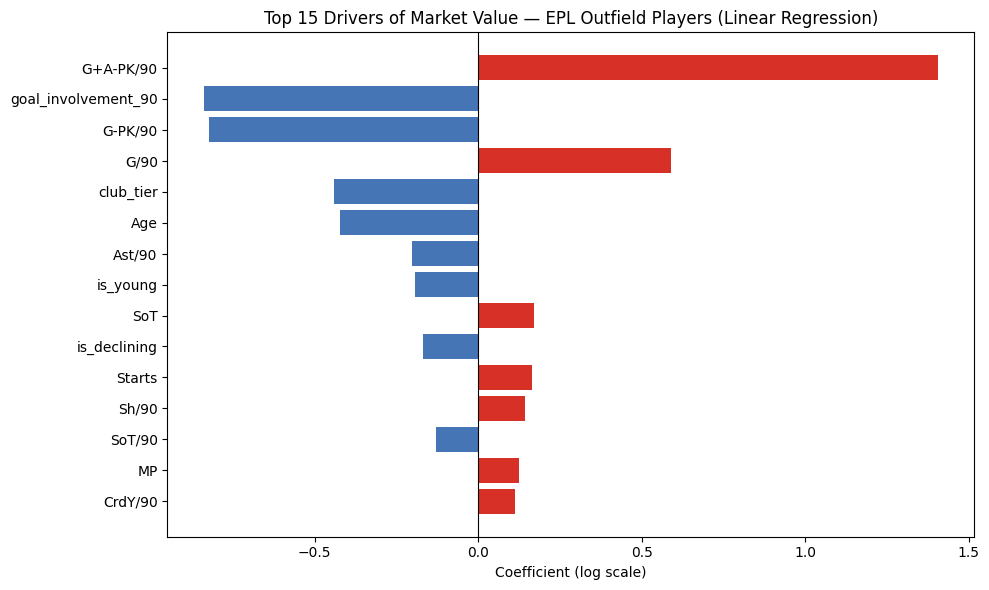


Worst 10 predictions on TEST SET:
              player_name season       actual    predicted        error
        Christian Eriksen  16-17  €40,000,000 €181,655,838 €141,655,838
              Timo Werner  19-20  €64,000,000 €137,795,233  €73,795,233
           Erling Haaland  23-24 €180,000,000 €119,094,900  €60,905,100
          Virgil van Dijk  18-19  €90,000,000  €29,928,069  €60,071,931
              Declan Rice  22-23  €90,000,000  €30,229,444  €59,770,556
               Rúben Dias  22-23  €80,000,000  €21,517,765  €58,482,235
             Nicolas Pépé  18-19  €65,000,000 €120,551,578  €55,551,578
          Aymeric Laporte  18-19  €75,000,000  €26,505,043  €48,494,957
Pierre-Emerick Aubameyang  18-19  €70,000,000  €22,294,550  €47,705,450
      Alexis Mac Allister  24-25 €100,000,000  €52,461,848  €47,538,152

Sample predictions from TEST SET:
    player_name season      actual   predicted
   Andy Carroll  16-17 €10,000,000 €18,549,482
Trevoh Chalobah  24-25 €25,000,000 €16,473,2

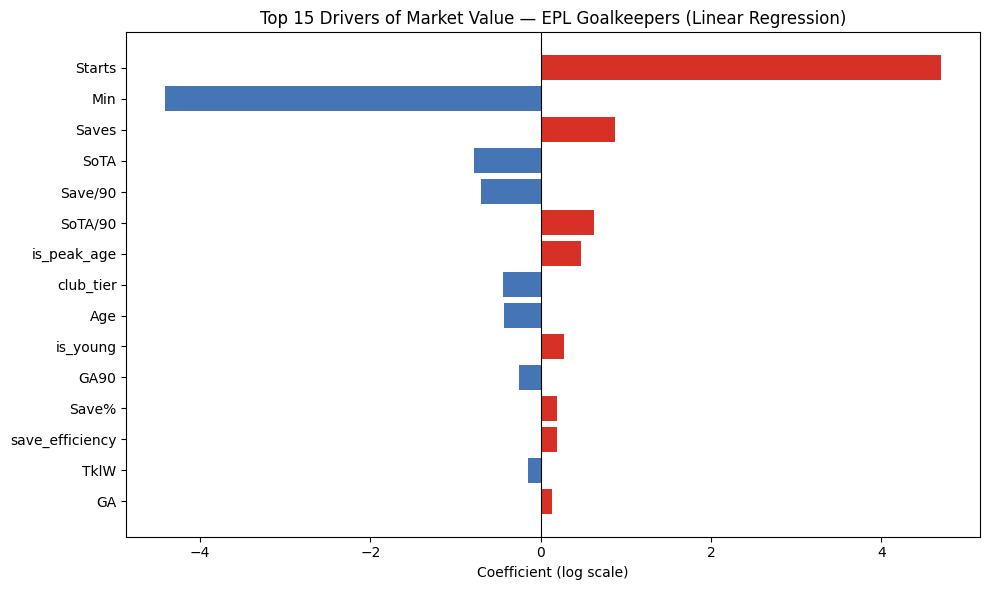


Worst 10 predictions on TEST SET:
      player_name season      actual   predicted       error
          Alisson  19-20 €72,000,000 €14,462,432 €57,537,568
Kepa Arrizabalaga  19-20 €32,000,000 €10,288,525 €21,711,475
          Alisson  23-24 €28,000,000  €8,663,011 €19,336,989
          Ederson  19-20 €56,000,000 €39,719,166 €16,280,834
   Dean Henderson  22-23 €18,000,000  €4,637,360 €13,362,640
     David de Gea  19-20 €40,000,000 €26,991,779 €13,008,221
          Alisson  24-25 €20,000,000  €8,319,455 €11,680,545
Emiliano Martínez  21-22 €28,000,000 €16,639,709 €11,360,291
          Alisson  20-21  €2,500,000 €13,563,216 €11,063,216
   Robert Sánchez  19-20    €150,000  €9,243,399  €9,093,399

Sample predictions from TEST SET:
      player_name season      actual   predicted
Kasper Schmeichel  20-21  €6,000,000  €3,399,636
Ron-Robert Zieler  16-17  €7,000,000  €6,062,518
Kasper Schmeichel  21-22  €4,000,000  €3,247,961
  Thomas Kaminski  23-24  €3,000,000  €6,697,503
      Karl Dar

In [58]:
#EPL Linear Regression
# ── 0. FILTER EPL DATASETS ───────────────────────────────────────────────────
epl_teams = [
    "Arsenal", "Aston Villa", "Bournemouth", "Brentford",
    "Brighton", "Burnley", "Chelsea", "Crystal Palace",
    "Everton", "Fulham", "Huddersfield Town", "Hull City",
    "Ipswich Town", "Leeds United", "Leicester City",
    "Liverpool", "Luton Town", "Manchester City",
    "Manchester Utd", "Newcastle United",
    "Norwich City", "Nottingham Forest",
    "Sheffield United", "Southampton", "Stoke City",
    "Sunderland", "Swansea City", "Tottenham Hotspur",
    "Watford", "West Brom", "West Ham United", "Wolves"
]

df_epl_outfield = df_outfield[
    df_outfield["Squad"].isin(epl_teams)
].copy()

df_epl_gk = df_gk_model[
    df_gk_model["Squad"].isin(epl_teams)
].copy()

print("EPL Outfield Rows:", len(df_epl_outfield))
print("EPL GK Rows:", len(df_epl_gk))


# ── 1. FEATURE ENGINEERING ────────────────────────────────────────────────────
df_epl_outfield = engineer_features(df_epl_outfield, is_gk=False)
df_epl_gk       = engineer_features(df_epl_gk, is_gk=True)


# ── 2. FEATURE LISTS ──────────────────────────────────────────────────────────
EPL_OUTFIELD_FEATURES = [
    f for f in OUTFIELD_FEATURES_FINAL
    if f in df_epl_outfield.columns
]

EPL_GK_FEATURES = [
    f for f in GK_FEATURES_FINAL
    if f in df_epl_gk.columns
]


# ── 3. RUN EPL MODELS ─────────────────────────────────────────────────────────
epl_lr_outfield_pipeline, epl_lr_outfield_coefs, df_epl_outfield = run_final_lr_model(
    df_epl_outfield,
    EPL_OUTFIELD_FEATURES,
    "EPL Outfield Players"
)

epl_lr_gk_pipeline, epl_lr_gk_coefs, df_epl_gk = run_final_lr_model(
    df_epl_gk,
    EPL_GK_FEATURES,
    "EPL Goalkeepers"
)


# ── 4. SAVE EPL RESULTS ───────────────────────────────────────────────────────
pd.concat([df_epl_outfield, df_epl_gk]).to_csv(
    "epl_model_predictions_final.csv",
    index=False
)

epl_lr_outfield_coefs.to_csv(
    "feature_importance_epl_outfield_final.csv",
    index=False
)

epl_lr_gk_coefs.to_csv(
    "feature_importance_epl_gk_final.csv",
    index=False
)

print("\nEPL models complete and saved.")

La Liga Outfield Rows: 3078
La Liga GK Rows: 242

── La Liga Outfield Players | Linear Regression ──────────────────────────────
Train rows    : 2462
Test rows     : 616
CV R²         : 0.617 ± 0.026  (train set)
CV MAE        : 0.615 ± 0.019  (log scale)
Test R²       : 0.580  ← honest performance on unseen data
Test MAE      : €5,598,681
Test MSE   : 124,906,859,953,547
Test RMSE  : €11,176,174

Top 15 drivers (by absolute coefficient):
            feature  coefficient
          club_tier    -0.681317
               G/90     0.569283
            G-PK/90    -0.487663
                Min     0.447546
                Age    -0.394164
goal_involvement_90     0.329117
                 Sh     0.292092
                 PK    -0.186889
       is_declining    -0.180276
           is_young    -0.165732
             Fls/90    -0.156444
                Fls     0.136697
               CrdY    -0.129419
            CrdY/90     0.118082
          G+A-PK/90    -0.112802


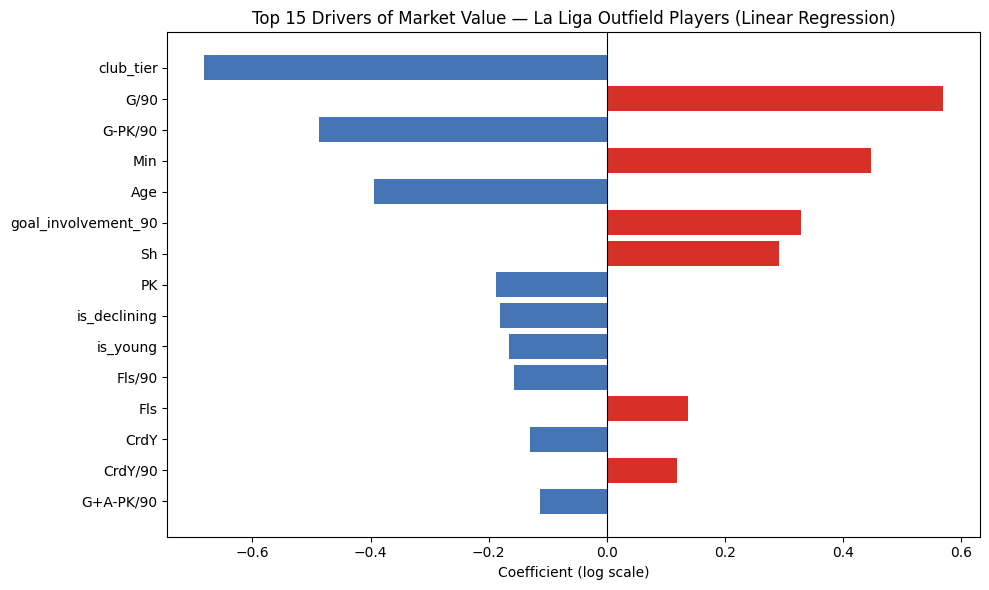


Worst 10 predictions on TEST SET:
      player_name season       actual   predicted       error
            Pedri  24-25 €140,000,000 €53,872,707 €86,127,293
             Gavi  23-24  €90,000,000 €20,934,937 €69,065,063
Antoine Griezmann  19-20  €96,000,000 €35,197,486 €60,802,514
Eduardo Camavinga  22-23  €85,000,000 €27,426,995 €57,573,005
            Pedri  22-23 €100,000,000 €42,705,710 €57,294,290
            Pedri  21-22  €80,000,000 €30,290,228 €49,709,772
      Pau Cubarsí  24-25  €80,000,000 €35,284,774 €44,715,226
            Rodri  21-22  €80,000,000 €35,459,263 €44,540,737
             Isco  18-19  €60,000,000 €16,140,504 €43,859,496
     Jules Koundé  21-22  €60,000,000 €16,251,491 €43,748,509

Sample predictions from TEST SET:
     player_name season      actual   predicted
  Borja Iglesias  24-25  €3,000,000  €5,762,308
   Gonzalo Verdú  22-23    €700,000    €444,858
William Carvalho  24-25  €1,500,000  €1,272,859
    Fermín López  23-24 €30,000,000 €27,085,374
        

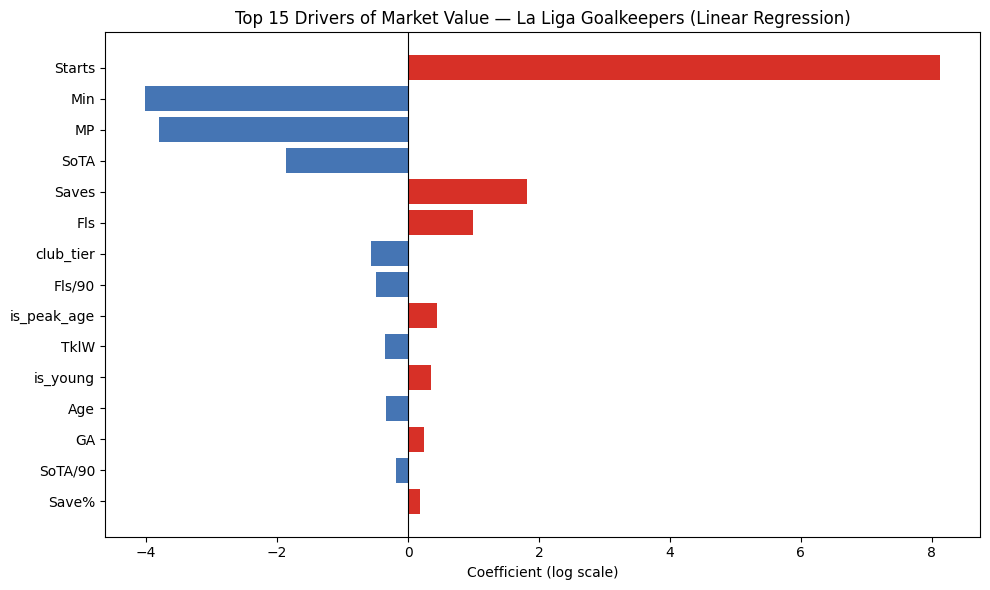


Worst 10 predictions on TEST SET:
          player_name season      actual   predicted       error
Marc-André ter Stegen  18-19 €90,000,000 €35,068,137 €54,931,863
   Julen Agirrezabala  24-25 €15,000,000  €2,079,697 €12,920,303
            Rui Silva  21-22 €15,000,000  €4,494,688 €10,505,312
       Sergio Herrera  24-25  €3,000,000 €10,047,860  €7,047,860
         Andriy Lunin  24-25 €18,000,000 €11,086,214  €6,913,786
            Jan Oblak  22-23 €35,000,000 €28,487,000  €6,513,000
         Ørjan Nyland  23-24  €1,400,000  €7,301,809  €5,901,809
        Álvaro Valles  23-24 €12,000,000  €6,698,315  €5,301,685
         Tomáš Vaclík  18-19 €18,000,000 €12,865,188  €5,134,812
          David Soria  20-21  €9,000,000  €4,241,181  €4,758,819

Sample predictions from TEST SET:
       player_name season      actual   predicted
   Filip Jørgensen  23-24 €20,000,000 €15,617,140
       Álex Remiro  21-22 €22,000,000 €20,502,757
     Álvaro Valles  23-24 €12,000,000  €6,698,315
    Vicente Gua

In [59]:
#La Liga Linear Regression
la_liga_teams = [
    "Alavés", "Almería", "Athletic Club", "Atlético Madrid",
    "Barcelona", "Celta Vigo", "Cádiz", "Dep La Coruña",
    "Eibar", "Elche", "Espanyol", "Getafe",
    "Girona", "Granada", "Huesca", "Las Palmas",
    "Leganés", "Levante", "Mallorca", "Málaga",
    "Osasuna", "Rayo Vallecano", "Real Betis",
    "Real Madrid", "Real Sociedad", "Sevilla",
    "Sporting Gijón", "Valencia", "Valladolid",
    "Villarreal"
]

df_la_liga_outfield = df_outfield[
    df_outfield["Squad"].isin(la_liga_teams)
].copy()

df_la_liga_gk = df_gk_model[
    df_gk_model["Squad"].isin(la_liga_teams)
].copy()

print("La Liga Outfield Rows:", len(df_la_liga_outfield))
print("La Liga GK Rows:", len(df_la_liga_gk))


# ── 1. FEATURE ENGINEERING ────────────────────────────────────────────────────
df_la_liga_outfield = engineer_features(df_la_liga_outfield, is_gk=False)
df_la_liga_gk       = engineer_features(df_la_liga_gk, is_gk=True)


# ── 2. FEATURE LISTS ──────────────────────────────────────────────────────────
LA_LIGA_OUTFIELD_FEATURES = [
    f for f in OUTFIELD_FEATURES_FINAL
    if f in df_la_liga_outfield.columns
]

LA_LIGA_GK_FEATURES = [
    f for f in GK_FEATURES_FINAL
    if f in df_la_liga_gk.columns
]


# ── 3. RUN EPL MODELS ─────────────────────────────────────────────────────────
la_liga_lr_outfield_pipeline, la_liga_lr_outfield_coefs, df_la_liga_outfield = run_final_lr_model(
    df_la_liga_outfield,
    LA_LIGA_OUTFIELD_FEATURES,
    "La Liga Outfield Players"
)

la_liga_lr_gk_pipeline, la_liga_lr_gk_coefs, df_la_liga_gk = run_final_lr_model(
    df_la_liga_gk,
    LA_LIGA_GK_FEATURES,
    "La Liga Goalkeepers"
)


# ── 4. SAVE La Liga RESULTS ───────────────────────────────────────────────────────
pd.concat([df_la_liga_outfield, df_la_liga_gk]).to_csv(
    "la_liga_model_predictions_final.csv",
    index=False
)

la_liga_lr_outfield_coefs.to_csv(
    "feature_importance_la_liga_outfield_final.csv",
    index=False
)

la_liga_lr_gk_coefs.to_csv(
    "feature_importance_la_liga_gk_final.csv",
    index=False
)

print("\nLa_Liga models complete and saved.")

Bundesliga Outfield Rows: 2723
Bundesliga GK Rows: 199

── Bundesliga Outfield Players | Linear Regression ──────────────────────────────
Train rows    : 2178
Test rows     : 545
CV R²         : 0.602 ± 0.036  (train set)
CV MAE        : 0.574 ± 0.020  (log scale)
Test R²       : 0.597  ← honest performance on unseen data
Test MAE      : €5,415,931
Test MSE   : 93,878,291,764,527
Test RMSE  : €9,689,081

Top 15 drivers (by absolute coefficient):
            feature  coefficient
goal_involvement_90     0.882562
          club_tier    -0.511023
                Min     0.353715
                Age    -0.325089
            G-PK/90    -0.308903
             Ast/90    -0.277967
                 Sh     0.221045
                SoT     0.186867
       is_declining    -0.186468
               G/90    -0.167344
                 PK    -0.137966
             Fls/90    -0.130081
       min_per_game     0.109782
                 MP    -0.099801
             Starts    -0.083108


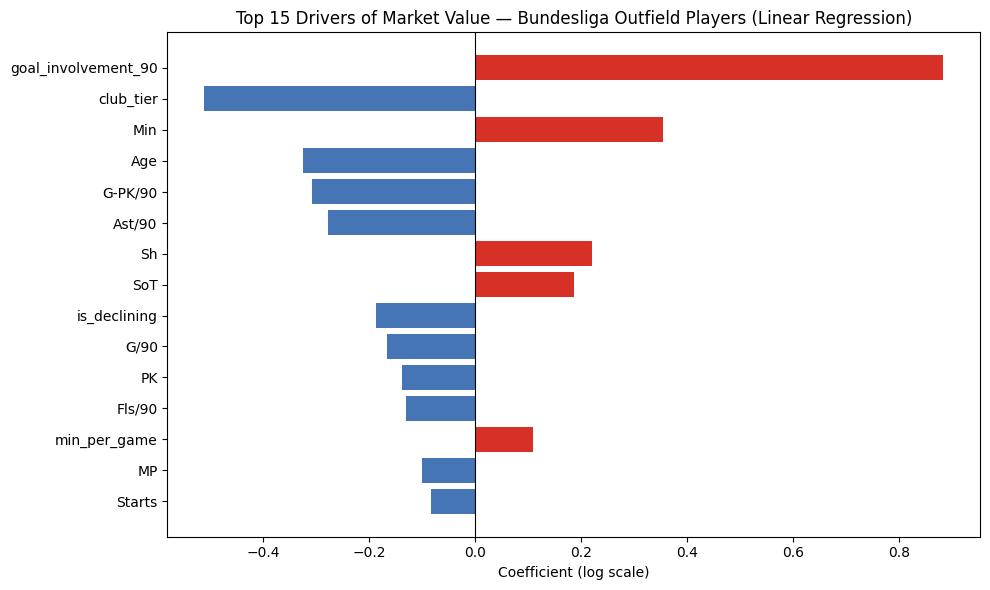


Worst 10 predictions on TEST SET:
      player_name season       actual   predicted       error
   Erling Haaland  21-22 €150,000,000 €86,870,301 €63,129,699
   Joshua Kimmich  21-22  €80,000,000 €26,554,114 €53,445,886
Randal Kolo Muani  22-23  €80,000,000 €27,562,655 €52,437,345
 Matthijs de Ligt  22-23  €75,000,000 €27,007,398 €47,992,602
       Harry Kane  24-25  €75,000,000 €31,196,605 €43,803,395
   Angelo Stiller  24-25  €45,000,000  €6,164,383 €38,835,617
    Leon Goretzka  20-21  €70,000,000 €32,331,045 €37,668,955
  Dayot Upamecano  20-21  €60,000,000 €23,968,802 €36,031,198
     Moussa Diaby  21-22  €60,000,000 €26,944,986 €33,055,014
   Piero Hincapié  23-24  €40,000,000  €7,675,208 €32,324,792

Sample predictions from TEST SET:
        player_name season      actual   predicted
    Marcin Kaminski  17-18  €2,500,000  €1,244,057
Christopher Trimmel  18-19    €600,000  €1,921,531
    Maxence Lacroix  23-24 €20,000,000 €15,789,861
          Dani Olmo  20-21 €45,000,000 €61,9

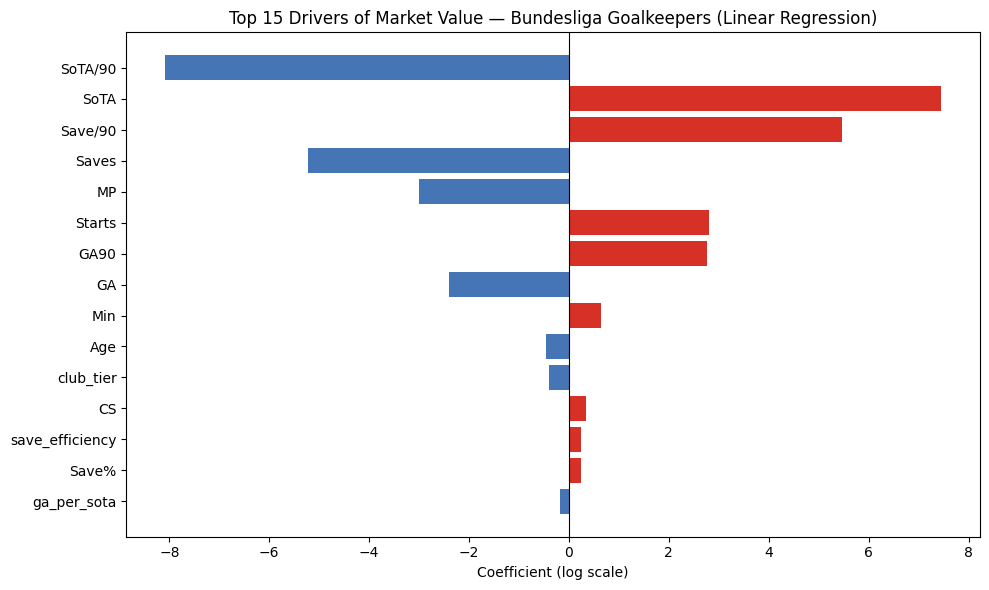


Worst 10 predictions on TEST SET:
       player_name season      actual   predicted       error
      Noah Atubolu  24-25 €18,000,000  €7,662,830 €10,337,170
      Manuel Neuer  21-22 €15,000,000  €5,011,026  €9,988,974
       Roman Bürki  17-18  €7,000,000 €15,499,901  €8,499,901
     Ralf Fährmann  17-18 €13,000,000  €5,912,870  €7,087,130
    Florian Müller  18-19 €10,000,000  €3,289,370  €6,710,630
       Kevin Trapp  22-23  €8,500,000  €2,835,742  €5,664,258
       Yann Sommer  16-17  €9,000,000  €3,374,578  €5,625,422
    Lukas Hradecky  22-23  €2,500,000  €7,463,123  €4,963,123
        Bernd Leno  16-17 €16,000,000 €11,107,774  €4,892,226
Alexander Schwolow  18-19  €9,000,000  €4,552,846  €4,447,154

Sample predictions from TEST SET:
   player_name season      actual  predicted
  Manuel Neuer  21-22 €15,000,000 €5,011,026
Lukas Hradecky  19-20  €8,000,000 €5,586,244
  Luca Philipp  24-25    €750,000 €1,553,320
Oliver Baumann  16-17  €7,000,000 €7,612,468
Florian Müller  18-19 €

In [60]:
#Bundesliga Linear Regression
bundesliga_teams = [
    "Arminia", "Augsburg", "Bayern Munich", "Bochum",
    "Darmstadt 98", "Dortmund", "Düsseldorf",
    "Eintracht Frankfurt", "Freiburg", "Gladbach",
    "Greuther Fürth", "Hamburger SV", "Hannover 96",
    "Heidenheim", "Hertha BSC", "Hoffenheim",
    "Holstein Kiel", "Ingolstadt", "Köln",
    "Leverkusen", "Mainz 05", "Paderborn 07",
    "RB Leipzig", "Schalke 04", "St Pauli",
    "Stuttgart", "Union Berlin", "Werder Bremen",
    "Wolfsburg"
]

df_bundesliga_outfield = df_outfield[
    df_outfield["Squad"].isin(bundesliga_teams)
].copy()

df_bundesliga_gk = df_gk_model[
    df_gk_model["Squad"].isin(bundesliga_teams)
].copy()

print("Bundesliga Outfield Rows:", len(df_bundesliga_outfield))
print("Bundesliga GK Rows:", len(df_bundesliga_gk))


# ── 1. FEATURE ENGINEERING ────────────────────────────────────────────────────
df_bundesliga_outfield = engineer_features(df_bundesliga_outfield, is_gk=False)
df_bundesliga_gk       = engineer_features(df_bundesliga_gk, is_gk=True)


# ── 2. FEATURE LISTS ──────────────────────────────────────────────────────────
BUNDESLIGA_OUTFIELD_FEATURES = [
    f for f in OUTFIELD_FEATURES_FINAL
    if f in df_bundesliga_outfield.columns
]

BUNDESLIGA_GK_FEATURES = [
    f for f in GK_FEATURES_FINAL
    if f in df_bundesliga_gk.columns
]


# ── 3. RUN EPL MODELS ─────────────────────────────────────────────────────────
bundesliga_lr_outfield_pipeline, bundesliga_lr_outfield_coefs, df_bundesliga_outfield = run_final_lr_model(
    df_bundesliga_outfield,
    BUNDESLIGA_OUTFIELD_FEATURES,
    "Bundesliga Outfield Players"
)

bundesliga_lr_gk_pipeline, bundesliga_lr_gk_coefs, df_bundesliga_gk = run_final_lr_model(
    df_bundesliga_gk,
    BUNDESLIGA_GK_FEATURES,
    "Bundesliga Goalkeepers"
)


# ── 4. SAVE Bundesliga RESULTS ───────────────────────────────────────────────────────
pd.concat([df_bundesliga_outfield, df_bundesliga_gk]).to_csv(
    "bundesliga_model_predictions_final.csv",
    index=False
)

bundesliga_lr_outfield_coefs.to_csv(
    "feature_importance_bundesliga_outfield_final.csv",
    index=False
)

bundesliga_lr_gk_coefs.to_csv(
    "feature_importance_bundesliga_gk_final.csv",
    index=False
)

print("\nBundesliga models complete and saved.")

Serie A Outfield Rows: 3104
Serie A GK Rows: 219

── Serie A Outfield Players | Linear Regression ──────────────────────────────
Train rows    : 2483
Test rows     : 621
CV R²         : 0.636 ± 0.034  (train set)
CV MAE        : 0.582 ± 0.023  (log scale)
Test R²       : 0.629  ← honest performance on unseen data
Test MAE      : €4,900,100
Test MSE   : 77,719,848,671,415
Test RMSE  : €8,815,886

Top 15 drivers (by absolute coefficient):
            feature  coefficient
          club_tier    -0.543357
                Age    -0.527189
               G/90     0.428890
          G+A-PK/90    -0.413053
             Ast/90     0.357649
              Sh/90     0.218060
           is_young    -0.197328
                Fls     0.188218
goal_involvement_90    -0.163716
             Fls/90    -0.149728
       is_declining    -0.145070
                Off    -0.140147
                 Sh     0.116612
                SoT     0.102372
              PKatt    -0.094697


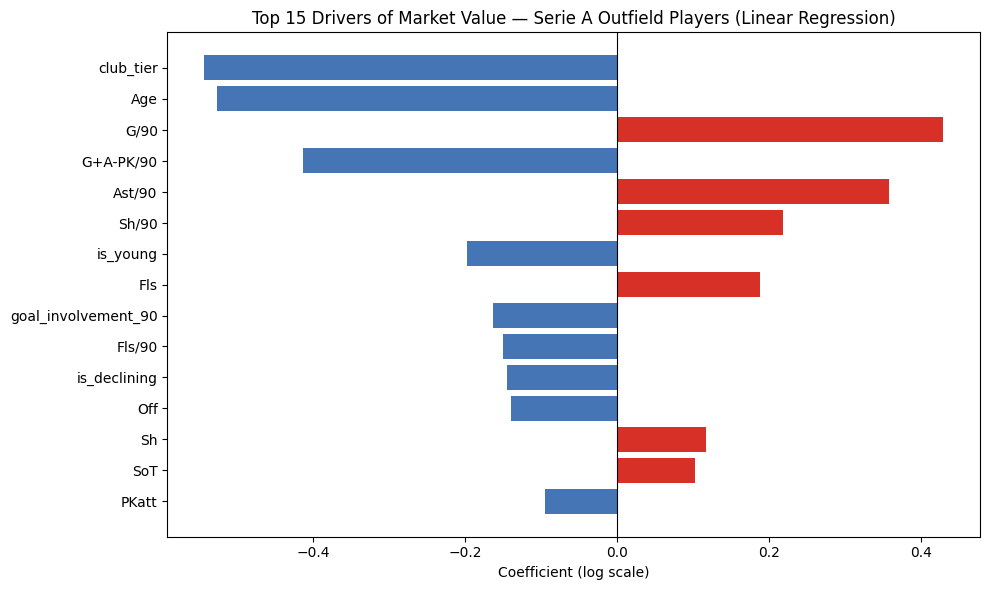


Worst 10 predictions on TEST SET:
     player_name season      actual    predicted       error
 Federico Chiesa  19-20 €48,000,000 €114,288,605 €66,288,605
  Dušan Vlahović  21-22 €85,000,000  €31,456,133 €53,543,867
Hakan Çalhanoğlu  18-19 €20,000,000  €70,927,542 €50,927,542
Lautaro Martínez  21-22 €75,000,000 €125,387,723 €50,387,723
  Milan Škriniar  22-23 €50,000,000   €9,109,727 €40,890,273
Matthijs de Ligt  19-20 €67,500,000  €28,685,974 €38,814,026
  Milan Škriniar  20-21 €60,000,000  €26,008,536 €33,991,464
Radja Nainggolan  17-18 €45,000,000  €12,421,400 €32,578,600
 Lorenzo Insigne  20-21 €48,000,000  €77,173,559 €29,173,559
   Douglas Costa  17-18 €55,000,000  €26,180,933 €28,819,067

Sample predictions from TEST SET:
        player_name season      actual   predicted
      Amir Rrahmani  21-22 €25,000,000 €20,654,297
Stephan El Shaarawy  23-24  €5,000,000  €3,951,903
     Ardian Ismajli  20-21  €2,500,000  €3,160,344
      Joan González  23-24  €4,500,000  €2,511,634
    

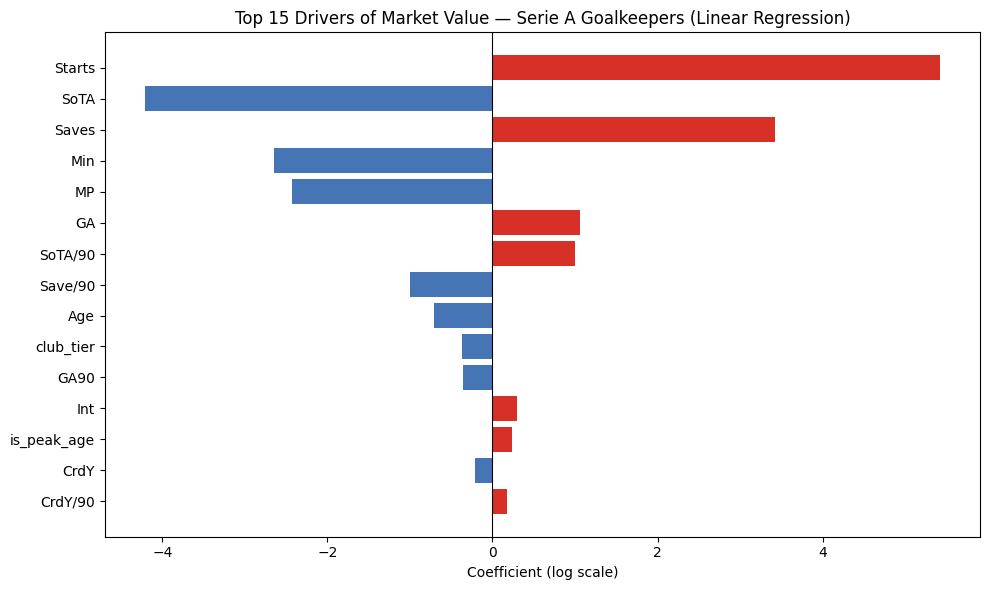


Worst 10 predictions on TEST SET:
         player_name season      actual   predicted       error
Gianluigi Donnarumma  20-21 €60,000,000 €34,191,018 €25,808,982
    Marco Sportiello  17-18  €6,000,000 €23,490,788 €17,490,788
          Alex Meret  19-20 €28,000,000 €12,929,418 €15,070,582
   Wojciech Szczesny  20-21 €25,000,000 €10,868,807 €14,131,193
        Mike Maignan  24-25 €25,000,000 €13,455,163 €11,544,837
           Pau López  18-19 €20,000,000  €8,642,275 €11,357,725
   Wojciech Szczesny  17-18 €20,000,000  €9,306,194 €10,693,806
      Alessio Cragno  20-21 €20,000,000 €10,051,790  €9,948,210
     Marco Silvestri  19-20  €4,800,000 €12,984,693  €8,184,693
 Michele Di Gregorio  23-24 €18,000,000 €11,160,591  €6,839,409

Sample predictions from TEST SET:
        player_name season      actual   predicted
   Samir Handanovič  18-19  €6,000,000  €3,211,512
 Michele Cerofolini  23-24    €700,000  €1,942,414
Michele Di Gregorio  23-24 €18,000,000 €11,160,591
   Samir Handanovič  1

In [61]:
#Serie A Linear Regression
serie_a_teams = [
    "Atalanta", "Benevento", "Bologna", "Brescia",
    "Cagliari", "Chievo", "Como", "Cremonese",
    "Crotone", "Empoli", "Fiorentina", "Frosinone",
    "Genoa", "Hellas Verona", "Inter",
    "Juventus", "Lazio", "Lecce", "Milan",
    "Monza", "Napoli", "Palermo", "Parma",
    "Pescara", "Roma", "SPAL", "Salernitana",
    "Sampdoria", "Sassuolo", "Spezia",
    "Torino", "Udinese", "Venezia"
]

df_serie_a_outfield = df_outfield[
    df_outfield["Squad"].isin(serie_a_teams)
].copy()

df_serie_a_gk = df_gk_model[
    df_gk_model["Squad"].isin(serie_a_teams)
].copy()

print("Serie A Outfield Rows:", len(df_serie_a_outfield))
print("Serie A GK Rows:", len(df_serie_a_gk))


# ── 1. FEATURE ENGINEERING ────────────────────────────────────────────────────
df_serie_a_outfield = engineer_features(df_serie_a_outfield, is_gk=False)
df_serie_a_gk       = engineer_features(df_serie_a_gk, is_gk=True)


# ── 2. FEATURE LISTS ──────────────────────────────────────────────────────────
SERIA_A_OUTFIELD_FEATURES = [
    f for f in OUTFIELD_FEATURES_FINAL
    if f in df_serie_a_outfield.columns
]

SERIA_A_GK_FEATURES = [
    f for f in GK_FEATURES_FINAL
    if f in df_serie_a_gk.columns
]


# ── 3. RUN EPL MODELS ─────────────────────────────────────────────────────────
serie_a_lr_outfield_pipeline, serie_a_lr_outfield_coefs, df_serie_a_outfield = run_final_lr_model(
    df_serie_a_outfield,
    SERIA_A_OUTFIELD_FEATURES,
    "Serie A Outfield Players"
)

serie_a_lr_gk_pipeline, serie_a_lr_gk_coefs, df_serie_a_gk = run_final_lr_model(
    df_serie_a_gk,
    SERIA_A_GK_FEATURES,
    "Serie A Goalkeepers"
)


# ── 4. SAVE Serie A RESULTS ───────────────────────────────────────────────────────
pd.concat([df_serie_a_outfield, df_serie_a_gk]).to_csv(
    "serie_a_model_predictions_final.csv",
    index=False
)

serie_a_lr_outfield_coefs.to_csv(
    "feature_importance_serie_a_outfield_final.csv",
    index=False
)

serie_a_lr_gk_coefs.to_csv(
    "feature_importance_serie_a_gk_final.csv",
    index=False
)

print("\nSerie A models complete and saved.")

Ligue 1 Outfield Rows: 2967
Ligue 1 GK Rows: 227

── Ligue 1 Outfield Players | Linear Regression ──────────────────────────────
Train rows    : 2373
Test rows     : 594
CV R²         : 0.539 ± 0.022  (train set)
CV MAE        : 0.632 ± 0.018  (log scale)
Test R²       : 0.554  ← honest performance on unseen data
Test MAE      : €4,394,880
Test MSE   : 70,169,366,221,932
Test RMSE  : €8,376,716

Top 15 drivers (by absolute coefficient):
     feature  coefficient
        G/90     0.700256
     G-PK/90    -0.509726
   club_tier    -0.433429
         Age    -0.424225
         Min    -0.344634
          Sh     0.211026
      Starts     0.210284
          PK    -0.198240
          MP     0.187736
    is_young    -0.180053
is_declining    -0.170755
min_per_game     0.145468
   G+A-PK/90    -0.142680
      Ast/90     0.134958
      Fls/90    -0.106656


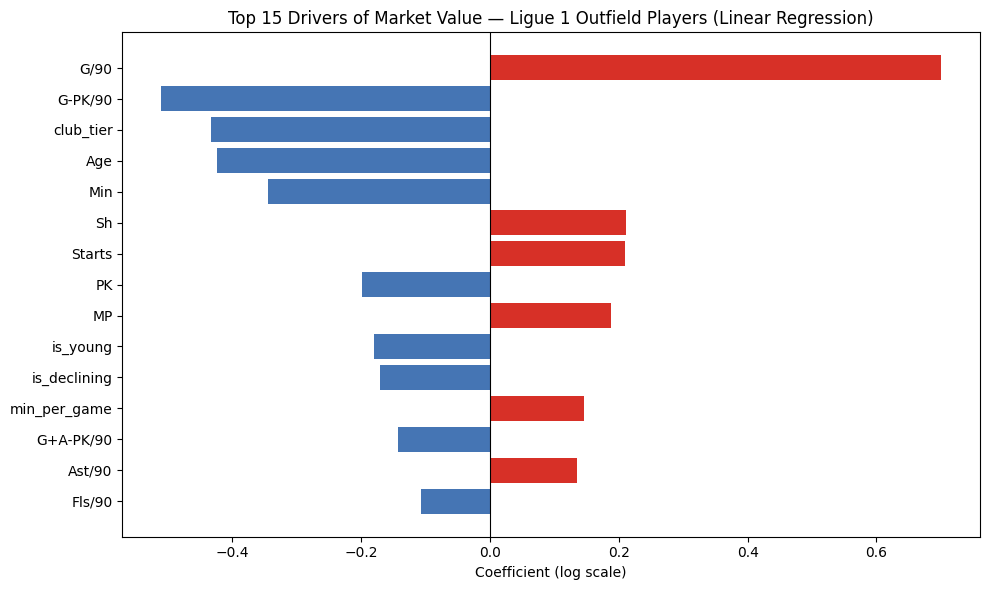


Worst 10 predictions on TEST SET:
        player_name season      actual   predicted       error
       Mauro Icardi  18-19 €80,000,000 €23,070,977 €56,929,023
      Achraf Hakimi  24-25 €80,000,000 €24,885,665 €55,114,335
            Marcelo  17-18 €60,000,000 €10,273,010 €49,726,990
Aurélien Tchouaméni  21-22 €60,000,000 €16,672,086 €43,327,914
          Leny Yoro  23-24 €50,000,000 €11,545,957 €38,454,043
         Marquinhos  19-20 €52,000,000 €13,669,336 €38,330,664
      Houssem Aouar  19-20 €49,500,000 €11,815,382 €37,684,618
  Eduardo Camavinga  20-21 €55,000,000 €18,272,438 €36,727,562
      Achraf Hakimi  23-24 €60,000,000 €24,112,959 €35,887,041
    Ousmane Dembélé  24-25 €90,000,000 €55,492,683 €34,507,317

Sample predictions from TEST SET:
       player_name season      actual   predicted
      Almamy Touré  16-17  €4,000,000  €6,840,417
Julien Le Cardinal  24-25  €2,000,000  €1,951,640
   Florian Thauvin  17-18 €50,000,000 €52,948,496
  Guillaume Gillet  16-17  €1,000,000

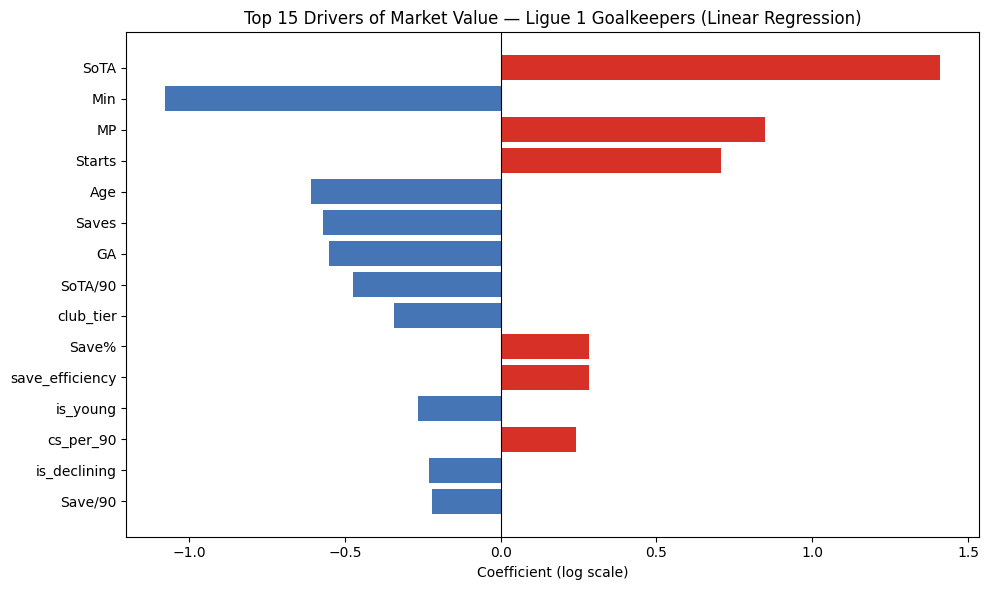


Worst 10 predictions on TEST SET:
         player_name season      actual   predicted       error
Gianluigi Donnarumma  24-25 €40,000,000 €15,890,555 €24,109,445
     Lucas Chevalier  24-25 €30,000,000 €10,645,024 €19,354,976
     Lucas Chevalier  23-24 €25,000,000 €15,371,407  €9,628,593
Gianluigi Donnarumma  22-23 €45,000,000 €35,385,585  €9,614,415
     Alphonse Areola  16-17 €10,000,000  €2,496,017  €7,503,983
        Keylor Navas  18-19 €10,000,000  €3,659,303  €6,340,697
        Alban Lafont  20-21 €10,000,000 €16,074,855  €6,074,855
     Lucas Chevalier  22-23 €10,000,000 €15,300,178  €5,300,178
      Gerónimo Rulli  24-25  €8,000,000  €3,828,675  €4,171,325
       Etienne Green  21-22  €7,000,000  €3,000,484  €3,999,516

Sample predictions from TEST SET:
      player_name season      actual   predicted
       Paul Nardi  20-21  €1,800,000  €2,099,202
      Kevin Trapp  16-17 €10,000,000 €11,202,151
     Keylor Navas  18-19 €10,000,000  €3,659,303
   Steve Mandanda  24-25    €5

In [62]:
#Ligue 1 Linear Regression
ligue1_teams = [
    "Ajaccio", "Amiens", "Angers", "Auxerre",
    "Bastia", "Bordeaux", "Brest", "Caen",
    "Clermont Foot", "Dijon", "Guingamp",
    "Le Havre", "Lens", "Lille", "Lorient",
    "Lyon", "Marseille", "Metz", "Monaco",
    "Montpellier", "Nancy", "Nantes", "Nice",
    "Nîmes", "Paris Saint-Germain", "Reims",
    "Rennes", "Saint-Étienne", "Strasbourg",
    "Toulouse", "Troyes"
]

df_ligue1_outfield = df_outfield[
    df_outfield["Squad"].isin(ligue1_teams)
].copy()

df_ligue1_gk = df_gk_model[
    df_gk_model["Squad"].isin(ligue1_teams)
].copy()

print("Ligue 1 Outfield Rows:", len(df_ligue1_outfield))
print("Ligue 1 GK Rows:", len(df_ligue1_gk))


# ── 1. FEATURE ENGINEERING ────────────────────────────────────────────────────
df_ligue1_outfield = engineer_features(df_ligue1_outfield, is_gk=False)
df_ligue1_gk       = engineer_features(df_ligue1_gk, is_gk=True)


# ── 2. FEATURE LISTS ──────────────────────────────────────────────────────────
LIGUE1_OUTFIELD_FEATURES = [
    f for f in OUTFIELD_FEATURES_FINAL
    if f in df_ligue1_outfield.columns
]

LIGUE1_GK_FEATURES = [
    f for f in GK_FEATURES_FINAL
    if f in df_ligue1_gk.columns
]


# ── 3. RUN EPL MODELS ─────────────────────────────────────────────────────────
ligue1_lr_outfield_pipeline, ligue1_lr_outfield_coefs, df_ligue1_outfield = run_final_lr_model(
    df_ligue1_outfield,
    LIGUE1_OUTFIELD_FEATURES,
    "Ligue 1 Outfield Players"
)

ligue1_lr_gk_pipeline, ligue1_lr_gk_coefs, df_ligue1_gk = run_final_lr_model(
    df_ligue1_gk,
    LIGUE1_GK_FEATURES,
    "Ligue 1 Goalkeepers"
)


# ── 4. SAVE Ligue 1 RESULTS ───────────────────────────────────────────────────────
pd.concat([df_ligue1_outfield, df_ligue1_gk]).to_csv(
    "ligue1_model_predictions_final.csv",
    index=False
)

ligue1_lr_outfield_coefs.to_csv(
    "feature_importance_ligue1_outfield_final.csv",
    index=False
)

ligue1_lr_gk_coefs.to_csv(
    "feature_importance_ligue1_gk_final.csv",
    index=False
)

print("\nLigue 1 models complete and saved.")

RANDOM FORESTS LEAGUE MODEL

EPL Outfield Rows: 3101
EPL GK Rows: 233

── EPL Outfield Players | Final Random Forest ──────────────────────────────
Train rows    : 2480
Test rows     : 621
CV R²         : 0.628 ± 0.024  (train set)
CV MAE        : 0.499 ± 0.019  (log scale)
Test R²       : 0.644  ← honest performance on unseen data
Test MAE      : €7,703,351
Test MSE   : 147,781,138,853,214
Test RMSE  : €12,156,527

Top 15 drivers:
          feature  importance
        club_tier    0.230762
              Age    0.213931
               Sh    0.117629
     is_declining    0.065306
              SoT    0.042488
              Min    0.025599
           G+A-PK    0.024955
              G+A    0.021521
     min_per_game    0.017970
           Starts    0.017033
              Fls    0.014238
              Fld    0.014045
           Fls/90    0.012446
defensive_actions    0.012205
              Crs    0.011709


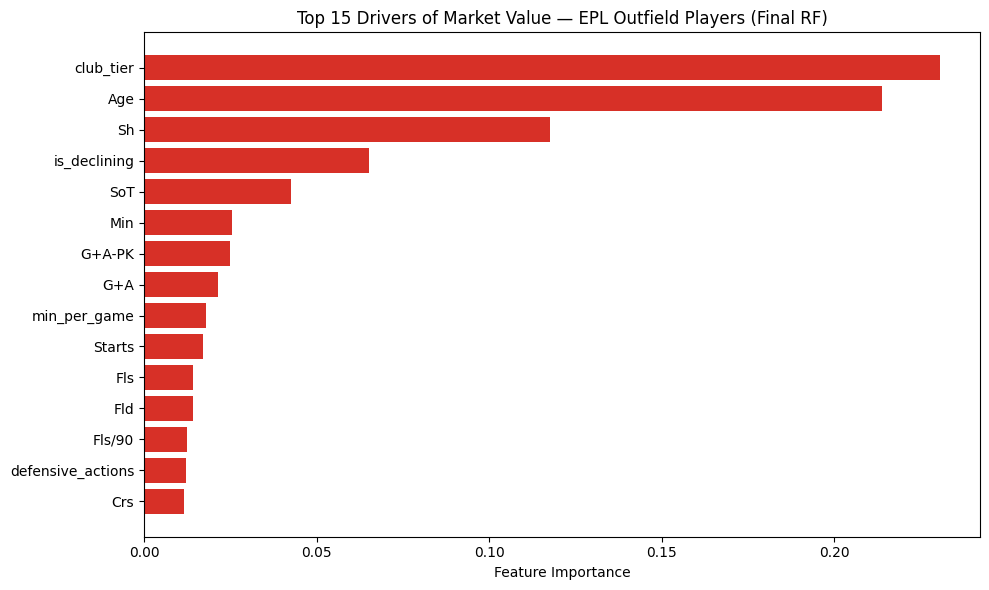


Worst 10 predictions on TEST SET:
        player_name season       actual    predicted       error
     Erling Haaland  23-24 €180,000,000 €105,039,094 €74,960,906
        Declan Rice  22-23  €90,000,000  €26,846,165 €63,153,835
  Christian Eriksen  16-17  €40,000,000  €93,607,271 €53,607,271
    Bruno Guimarães  23-24  €85,000,000  €33,084,139 €51,915,861
         Rúben Dias  22-23  €80,000,000  €28,908,319 €51,091,681
    Bruno Guimarães  24-25  €80,000,000  €30,981,452 €49,018,548
              Rodri  18-19  €80,000,000  €32,921,137 €47,078,863
Alexis Mac Allister  24-25 €100,000,000  €53,209,835 €46,790,165
    Virgil van Dijk  18-19  €90,000,000  €43,683,647 €46,316,353
    Cristian Romero  22-23  €60,000,000  €14,007,879 €45,992,121

Sample predictions from TEST SET:
    player_name season      actual   predicted
   Andy Carroll  16-17 €10,000,000 €15,442,572
Trevoh Chalobah  24-25 €25,000,000 €14,124,042
      Ben White  22-23 €55,000,000 €44,196,204
      Joel Ward  16-17  €5,

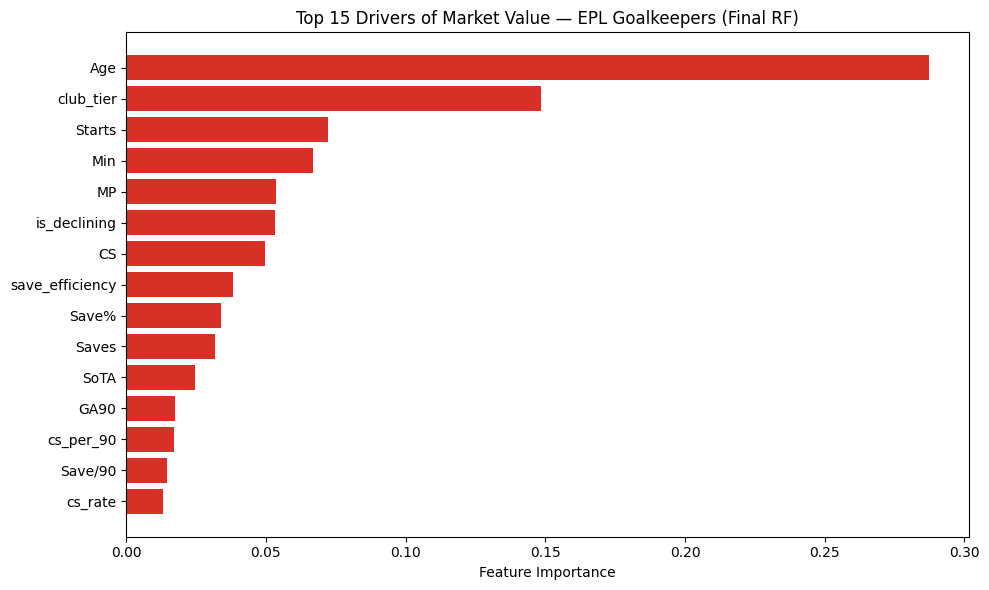


Worst 10 predictions on TEST SET:
      player_name season      actual   predicted       error
          Alisson  19-20 €72,000,000 €17,387,446 €54,612,554
     David de Gea  19-20 €40,000,000 €16,017,703 €23,982,297
Kepa Arrizabalaga  19-20 €32,000,000  €9,626,527 €22,373,473
          Alisson  23-24 €28,000,000 €10,407,963 €17,592,037
          Alisson  20-21  €2,500,000 €18,457,675 €15,957,675
  Jordan Pickford  19-20 €28,000,000 €13,188,139 €14,811,861
Emiliano Martínez  20-21 €30,000,000 €16,644,321 €13,355,679
   Dean Henderson  22-23 €18,000,000  €5,218,665 €12,781,335
          Alisson  24-25 €20,000,000  €9,142,809 €10,857,191
Emiliano Martínez  21-22 €28,000,000 €17,586,738 €10,413,262

Sample predictions from TEST SET:
      player_name season      actual   predicted
Kasper Schmeichel  20-21  €6,000,000  €5,143,056
Ron-Robert Zieler  16-17  €7,000,000  €5,831,906
Kasper Schmeichel  21-22  €4,000,000  €3,320,258
  Thomas Kaminski  23-24  €3,000,000  €7,917,618
      Karl Dar

In [63]:
#EPL Random Forests
df_epl_outfield = df_outfield[
    df_outfield["Squad"].isin(epl_teams)
].copy()

df_epl_gk = df_gk_model[
    df_gk_model["Squad"].isin(epl_teams)
].copy()

print("EPL Outfield Rows:", len(df_epl_outfield))
print("EPL GK Rows:", len(df_epl_gk))


# ── 1. APPLY FEATURE ENGINEERING ──────────────────────────────────────────────
df_epl_outfield = engineer_features(df_epl_outfield, is_gk=False)
df_epl_gk       = engineer_features(df_epl_gk, is_gk=True)


# ── 2. EPL FEATURE LISTS ──────────────────────────────────────────────────────
EPL_OUTFIELD_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min", "SubIn", "min_per_game", 

    # Goal output
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",

    # Rates
    "G/90", "Ast/90", "goal_involvement_90",

    # Shooting
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",

    # Defense
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",

    # Discipline
    "CrdY", "CrdR",

] + [c for c in pos_dummies.columns]

EPL_OUTFIELD_FEATURES = [
    f for f in EPL_OUTFIELD_FEATURES
    if f in df_epl_outfield.columns
]


EPL_GK_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min", 

    # GK core
    "GA", "GA90", "SoTA", "Saves", "Save%",
    "CS", "CS%", "Save/90", "SoTA/90",

    # Engineered
    "save_efficiency", "cs_rate",
    "cs_per_90", "ga_per_sota",

    # Discipline
    "CrdY", "CrdR", "CrdY/90",
    "Fls/90", "Fls", "Int", "TklW",
]

EPL_GK_FEATURES = [
    f for f in EPL_GK_FEATURES
    if f in df_epl_gk.columns
]


# ── 3. RUN EPL RANDOM FOREST MODELS ──────────────────────────────────────────
epl_rf_outfield_pipeline, epl_rf_outfield_coefs, df_epl_outfield = run_final_rf_model(
    df_epl_outfield,
    EPL_OUTFIELD_FEATURES,
    "EPL Outfield Players"
)

epl_rf_gk_pipeline, epl_rf_gk_coefs, df_epl_gk = run_final_rf_model(
    df_epl_gk,
    EPL_GK_FEATURES,
    "EPL Goalkeepers"
)


# ── 4. SAVE EPL RESULTS ───────────────────────────────────────────────────────
pd.concat([df_epl_outfield, df_epl_gk]).to_csv(
    "epl_model_predictions_final.csv",
    index=False
)

epl_rf_outfield_coefs.to_csv(
    "feature_importance_epl_outfield_final.csv",
    index=False
)

epl_rf_gk_coefs.to_csv(
    "feature_importance_epl_gk_final.csv",
    index=False
)

print("\nEPL Random Forest models complete and saved.")

Bundesliga Outfield Rows: 2723
Bundesliga GK Rows: 199

── Bundesliga Outfield Players | Final Random Forest ──────────────────────────────
Train rows    : 2178
Test rows     : 545
CV R²         : 0.630 ± 0.025  (train set)
CV MAE        : 0.560 ± 0.015  (log scale)
Test R²       : 0.639  ← honest performance on unseen data
Test MAE      : €5,445,464
Test MSE   : 97,729,155,147,207
Test RMSE  : €9,885,806

Top 15 drivers:
          feature  importance
        club_tier    0.290269
              Age    0.137021
              Min    0.074677
               Sh    0.056935
     is_declining    0.046460
           G+A-PK    0.041579
              G+A    0.034735
              SoT    0.026893
     min_per_game    0.024383
           Starts    0.022118
           Fls/90    0.015775
defensive_actions    0.013904
              Fls    0.013268
              Fld    0.012080
             G/Sh    0.011928


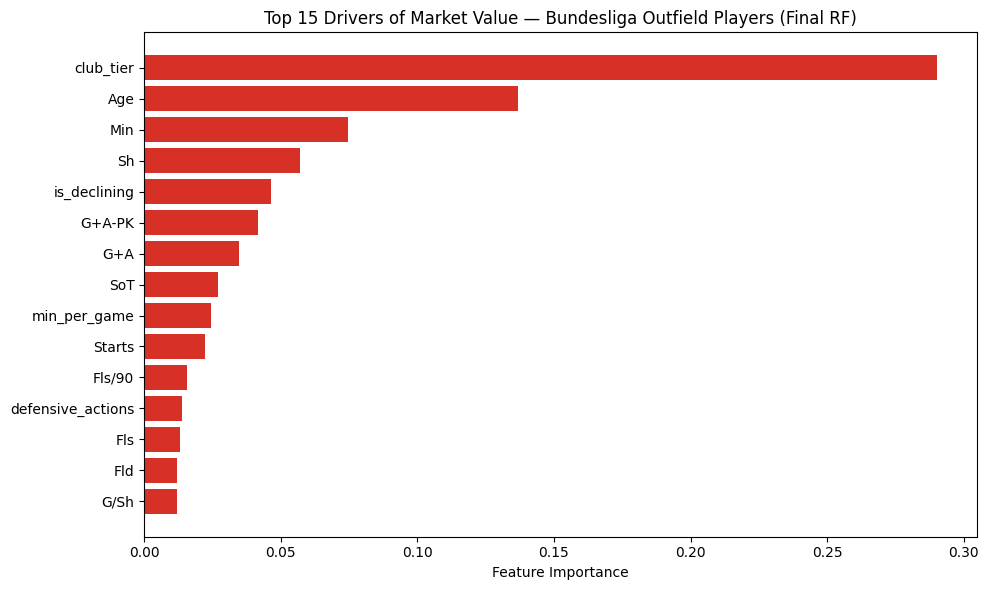


Worst 10 predictions on TEST SET:
      player_name season       actual   predicted       error
   Erling Haaland  21-22 €150,000,000 €77,968,534 €72,031,466
    Jamal Musiala  22-23 €110,000,000 €53,467,832 €56,532,168
     Jadon Sancho  18-19 €100,000,000 €43,874,053 €56,125,947
Randal Kolo Muani  22-23  €80,000,000 €27,705,632 €52,294,368
 Matthijs de Ligt  22-23  €75,000,000 €27,001,814 €47,998,186
      André Silva  21-22   €1,200,000 €44,607,900 €43,407,900
    Jamal Musiala  21-22  €65,000,000 €27,416,678 €37,583,322
    Leon Goretzka  20-21  €70,000,000 €33,010,937 €36,989,063
    Donyell Malen  22-23  €28,000,000 €63,076,135 €35,076,135
   Piero Hincapié  23-24  €40,000,000  €6,172,489 €33,827,511

Sample predictions from TEST SET:
        player_name season      actual   predicted
    Marcin Kaminski  17-18  €2,500,000  €2,005,540
Christopher Trimmel  18-19    €600,000  €1,888,096
    Maxence Lacroix  23-24 €20,000,000 €12,029,321
          Dani Olmo  20-21 €45,000,000 €44,9

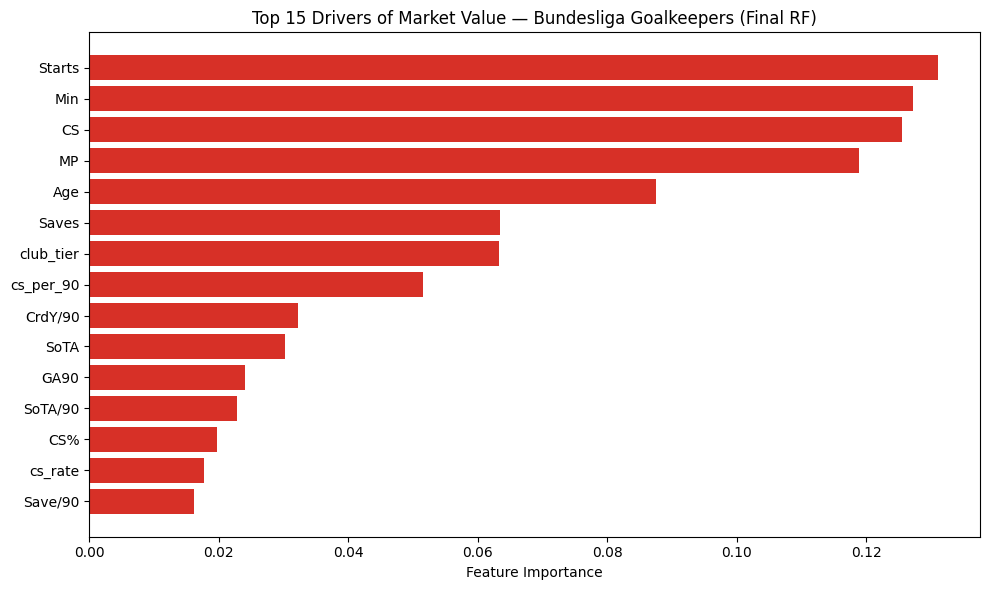


Worst 10 predictions on TEST SET:
       player_name season      actual  predicted       error
      Noah Atubolu  24-25 €18,000,000 €6,069,764 €11,930,236
    Florian Müller  18-19 €10,000,000 €2,161,446  €7,838,554
      Manuel Neuer  21-22 €15,000,000 €7,312,778  €7,687,222
        Bernd Leno  16-17 €16,000,000 €9,742,278  €6,257,722
       Yann Sommer  16-17  €9,000,000 €3,062,445  €5,937,555
Alexander Schwolow  18-19  €9,000,000 €4,091,877  €4,908,123
       Kevin Trapp  22-23  €8,500,000 €3,696,974  €4,803,026
     Koen Casteels  23-24  €6,000,000 €2,051,786  €3,948,214
     Ralf Fährmann  17-18 €13,000,000 €9,246,835  €3,753,165
      Kevin Müller  24-25    €700,000 €4,124,519  €3,424,519

Sample predictions from TEST SET:
   player_name season      actual  predicted
  Manuel Neuer  21-22 €15,000,000 €7,312,778
Lukas Hradecky  19-20  €8,000,000 €8,704,853
  Luca Philipp  24-25    €750,000 €1,507,049
Oliver Baumann  16-17  €7,000,000 €4,960,154
Florian Müller  18-19 €10,000,000 

In [64]:
#Bundesliga Random Forests
df_bundesliga_outfield = df_outfield[
    df_outfield["Squad"].isin(bundesliga_teams)
].copy()

df_bundesliga_gk = df_gk_model[
    df_gk_model["Squad"].isin(bundesliga_teams)
].copy()

print("Bundesliga Outfield Rows:", len(df_bundesliga_outfield))
print("Bundesliga GK Rows:", len(df_bundesliga_gk))


# ── 1. APPLY FEATURE ENGINEERING ──────────────────────────────────────────────
df_bundesliga_outfield = engineer_features(df_bundesliga_outfield, is_gk=False)
df_bundesliga_gk       = engineer_features(df_bundesliga_gk, is_gk=True)


# ── 2. Bundesliga FEATURE LISTS ──────────────────────────────────────────────────────
BUNDESLIGA_OUTFIELD_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min", "SubIn", "min_per_game",

    # Goal output
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",

    # Rates
    "G/90", "Ast/90", "goal_involvement_90",

    # Shooting
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",

    # Defense
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",

    # Discipline
    "CrdY", "CrdR",

] + [c for c in pos_dummies.columns]

BUNDESLIGA_OUTFIELD_FEATURES = [
    f for f in BUNDESLIGA_OUTFIELD_FEATURES
    if f in df_bundesliga_outfield.columns
]


BUNDESLIGA_GK_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min",

    # GK core
    "GA", "GA90", "SoTA", "Saves", "Save%",
    "CS", "CS%", "Save/90", "SoTA/90",

    # Engineered
    "save_efficiency", "cs_rate",
    "cs_per_90", "ga_per_sota",

    # Discipline
    "CrdY", "CrdR", "CrdY/90",
    "Fls/90", "Fls", "Int", "TklW",
]

BUNDESLIGA_GK_FEATURES = [
    f for f in BUNDESLIGA_GK_FEATURES
    if f in df_bundesliga_gk.columns
]


# ── 3. RUN Bundesliga RANDOM FOREST MODELS ──────────────────────────────────────────
bundesliga_rf_outfield_pipeline, bundesliga_rf_outfield_coefs, df_bundesliga_outfield = run_final_rf_model(
    df_bundesliga_outfield,
    BUNDESLIGA_OUTFIELD_FEATURES,
    "Bundesliga Outfield Players"
)

bundesliga_rf_gk_pipeline, bundesliga_rf_gk_coefs, df_bundesliga_gk = run_final_rf_model(
    df_bundesliga_gk,
    BUNDESLIGA_GK_FEATURES,
    "Bundesliga Goalkeepers"
)


# ── 4. SAVE Bundesliga RESULTS ───────────────────────────────────────────────────────
pd.concat([df_bundesliga_outfield, df_bundesliga_gk]).to_csv(
    "bundesliga_model_predictions_final.csv",
    index=False
)

bundesliga_rf_outfield_coefs.to_csv(
    "feature_importance_bundesliga_outfield_final.csv",
    index=False
)

bundesliga_rf_gk_coefs.to_csv(
    "feature_importance_bundesliga_gk_final.csv",
    index=False
)

print("\nBundesliga Random Forest models complete and saved.")

La Liga Outfield Rows: 3078
La Liga GK Rows: 242

── La Liga Outfield Players | Final Random Forest ──────────────────────────────
Train rows    : 2462
Test rows     : 616
CV R²         : 0.636 ± 0.018  (train set)
CV MAE        : 0.591 ± 0.012  (log scale)
Test R²       : 0.601  ← honest performance on unseen data
Test MAE      : €5,314,477
Test MSE   : 119,180,674,067,606
Test RMSE  : €10,916,990

Top 15 drivers:
          feature  importance
        club_tier    0.378050
              Age    0.086840
               Sh    0.060634
              Min    0.053608
     is_declining    0.044521
           G+A-PK    0.040143
           Starts    0.034190
     min_per_game    0.026467
              Fld    0.025629
              SoT    0.025467
defensive_actions    0.020193
              G+A    0.019603
               MP    0.012534
              Fls    0.012435
              Crs    0.012152


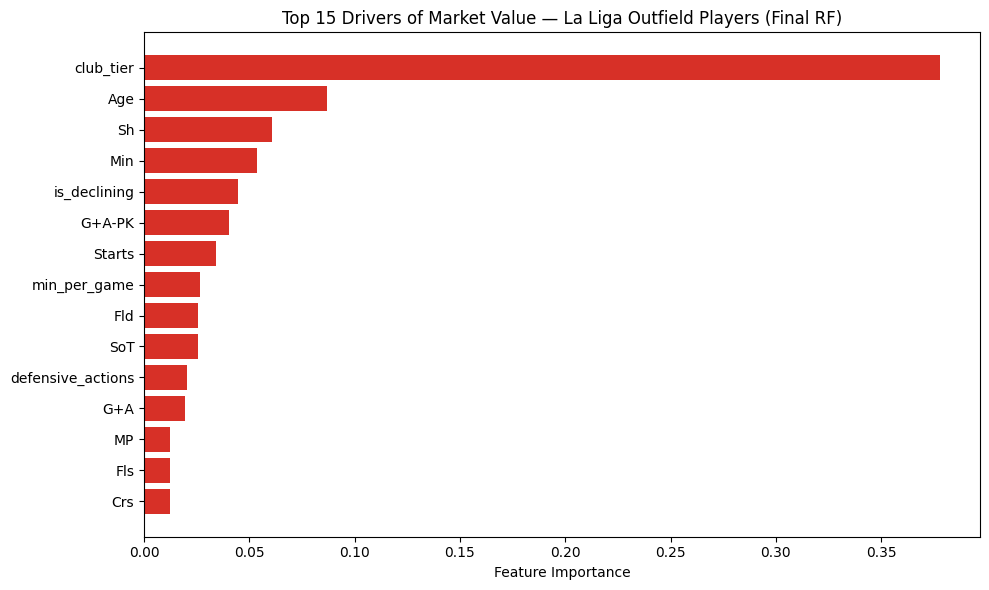


Worst 10 predictions on TEST SET:
      player_name season       actual   predicted       error
            Pedri  24-25 €140,000,000 €57,594,961 €82,405,039
Cristiano Ronaldo  17-18 €100,000,000 €34,174,596 €65,825,404
             Gavi  23-24  €90,000,000 €25,741,504 €64,258,496
Cristiano Ronaldo  16-17 €100,000,000 €37,205,702 €62,794,298
            Rodri  21-22  €80,000,000 €23,100,394 €56,899,606
            Pedri  22-23 €100,000,000 €48,774,591 €51,225,409
            Pedri  21-22  €80,000,000 €28,927,316 €51,072,684
      Pau Cubarsí  24-25  €80,000,000 €29,326,828 €50,673,172
Eduardo Camavinga  22-23  €85,000,000 €38,905,178 €46,094,822
     Jules Koundé  21-22  €60,000,000 €15,147,434 €44,852,566

Sample predictions from TEST SET:
     player_name season      actual   predicted
  Borja Iglesias  24-25  €3,000,000  €5,314,062
   Gonzalo Verdú  22-23    €700,000    €938,563
William Carvalho  24-25  €1,500,000  €1,368,402
    Fermín López  23-24 €30,000,000 €39,514,462
        

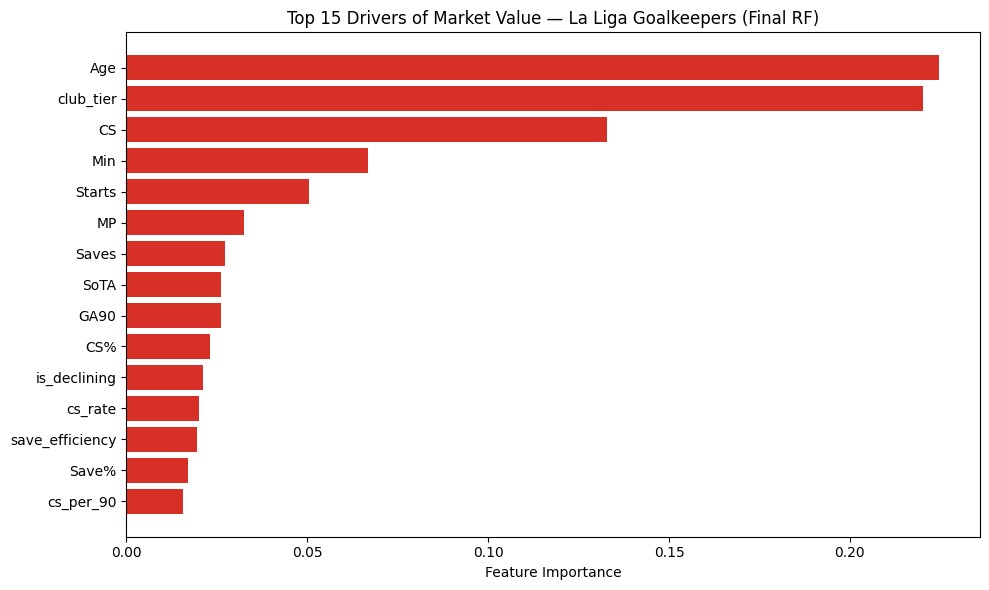


Worst 10 predictions on TEST SET:
          player_name season      actual   predicted       error
Marc-André ter Stegen  18-19 €90,000,000 €49,257,431 €40,742,569
      Filip Jørgensen  23-24 €20,000,000  €5,781,127 €14,218,873
 Giorgi Mamardashvili  22-23 €25,000,000 €11,193,995 €13,806,005
   Julen Agirrezabala  24-25 €15,000,000  €1,969,564 €13,030,436
         Andriy Lunin  24-25 €18,000,000  €6,573,749 €11,426,251
         Tomáš Vaclík  18-19 €18,000,000  €7,353,610 €10,646,390
            Jan Oblak  22-23 €35,000,000 €25,518,179  €9,481,821
            Rui Silva  21-22 €15,000,000  €8,813,375  €6,186,625
       Sergio Herrera  19-20  €1,200,000  €6,930,955  €5,730,955
          Álex Remiro  21-22 €22,000,000 €17,414,351  €4,585,649

Sample predictions from TEST SET:
       player_name season      actual   predicted
   Filip Jørgensen  23-24 €20,000,000  €5,781,127
       Álex Remiro  21-22 €22,000,000 €17,414,351
     Álvaro Valles  23-24 €12,000,000  €8,827,901
    Vicente Gua

In [65]:
#La Liga Random Forests
df_la_liga_outfield = df_outfield[
    df_outfield["Squad"].isin(la_liga_teams)
].copy()

df_la_liga_gk = df_gk_model[
    df_gk_model["Squad"].isin(la_liga_teams)
].copy()

print("La Liga Outfield Rows:", len(df_la_liga_outfield))
print("La Liga GK Rows:", len(df_la_liga_gk))


# ── 1. APPLY FEATURE ENGINEERING ──────────────────────────────────────────────
df_la_liga_outfield = engineer_features(df_la_liga_outfield, is_gk=False)
df_la_liga_gk       = engineer_features(df_la_liga_gk, is_gk=True)


# ── 2. La Liga FEATURE LISTS ──────────────────────────────────────────────────────
LA_LIGA_OUTFIELD_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min", "SubIn", "min_per_game",

    # Goal output
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",

    # Rates
    "G/90", "Ast/90", "goal_involvement_90",

    # Shooting
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",

    # Defense
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",

    # Discipline
    "CrdY", "CrdR",

] + [c for c in pos_dummies.columns]

LA_LIGA_OUTFIELD_FEATURES = [
    f for f in LA_LIGA_OUTFIELD_FEATURES
    if f in df_la_liga_outfield.columns
]


LA_LIGA_GK_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min",

    # GK core
    "GA", "GA90", "SoTA", "Saves", "Save%",
    "CS", "CS%", "Save/90", "SoTA/90",

    # Engineered
    "save_efficiency", "cs_rate",
    "cs_per_90", "ga_per_sota",

    # Discipline
    "CrdY", "CrdR", "CrdY/90",
    "Fls/90", "Fls", "Int", "TklW",
]

LA_LIGA_GK_FEATURES = [
    f for f in LA_LIGA_GK_FEATURES
    if f in df_la_liga_gk.columns
]


# ── 3. RUN La Liga RANDOM FOREST MODELS ──────────────────────────────────────────
la_liga_rf_outfield_pipeline, la_liga_rf_outfield_coefs, df_la_liga_outfield = run_final_rf_model(
    df_la_liga_outfield,
    LA_LIGA_OUTFIELD_FEATURES,
    "La Liga Outfield Players"
)

la_liga_rf_gk_pipeline, la_liga_rf_gk_coefs, df_la_liga_gk = run_final_rf_model(
    df_la_liga_gk,
    LA_LIGA_GK_FEATURES,
    "La Liga Goalkeepers"
)


# ── 4. SAVE La Liga RESULTS ───────────────────────────────────────────────────────
pd.concat([df_la_liga_outfield, df_la_liga_gk]).to_csv(
    "la_liga_model_predictions_final.csv",
    index=False
)

la_liga_rf_outfield_coefs.to_csv(
    "feature_importance_la_liga_outfield_final.csv",
    index=False
)

la_liga_rf_gk_coefs.to_csv(
    "feature_importance_la_liga_gk_final.csv",
    index=False
)

print("\nLa Liga Random Forest models complete and saved.")

Ligue 1 Outfield Rows: 2967
Ligue 1 GK Rows: 227

── Ligue 1 Outfield Players | Final Random Forest ──────────────────────────────
Train rows    : 2373
Test rows     : 594
CV R²         : 0.587 ± 0.017  (train set)
CV MAE        : 0.599 ± 0.020  (log scale)
Test R²       : 0.617  ← honest performance on unseen data
Test MAE      : €3,939,225
Test MSE   : 59,972,704,843,268
Test RMSE  : €7,744,205

Top 15 drivers:
            feature  importance
          club_tier    0.207460
                Age    0.172616
                 Sh    0.084138
                G+A    0.048281
             G+A-PK    0.044658
                SoT    0.039006
       is_declining    0.034433
                Min    0.025685
       min_per_game    0.022080
  defensive_actions    0.021583
goal_involvement_90    0.020816
                Fld    0.020624
                Fls    0.017560
             Starts    0.016205
             Fls/90    0.015214


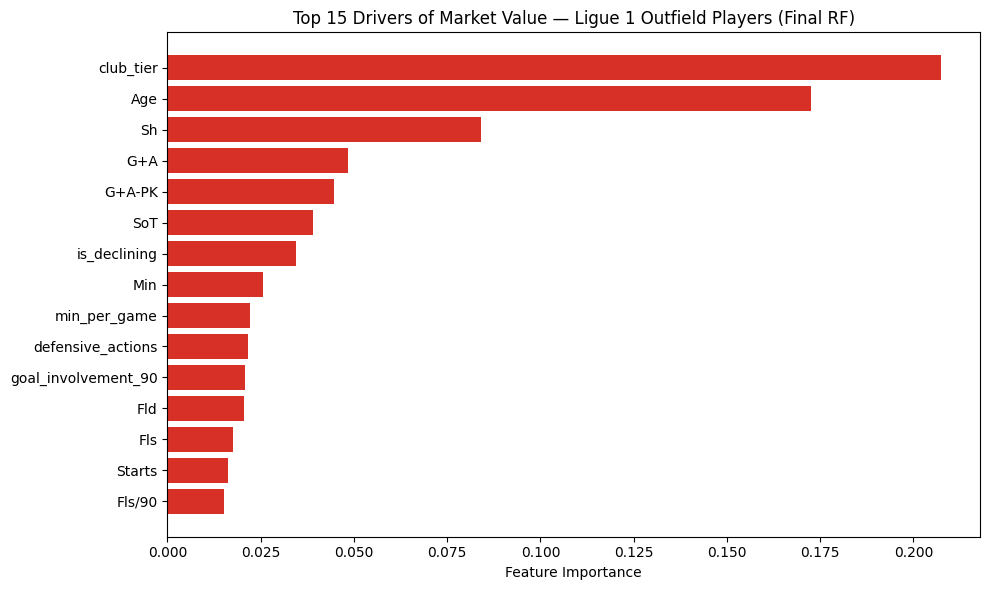


Worst 10 predictions on TEST SET:
        player_name season       actual    predicted       error
            Marcelo  17-18  €60,000,000   €6,677,497 €53,322,503
Aurélien Tchouaméni  21-22  €60,000,000  €11,927,067 €48,072,933
      Kylian Mbappé  21-22 €160,000,000 €115,129,908 €44,870,092
  Eduardo Camavinga  20-21  €55,000,000  €10,416,555 €44,583,445
      Achraf Hakimi  24-25  €80,000,000  €37,859,750 €42,140,250
          Leny Yoro  23-24  €50,000,000  €11,702,360 €38,297,640
      Houssem Aouar  19-20  €49,500,000  €12,869,323 €36,630,677
            Vitinha  23-24  €50,000,000  €15,519,280 €34,480,720
       Mauro Icardi  18-19  €80,000,000  €49,483,798 €30,516,202
    Khéphren Thuram  22-23  €40,000,000  €11,390,355 €28,609,645

Sample predictions from TEST SET:
       player_name season      actual   predicted
      Almamy Touré  16-17  €4,000,000  €4,869,195
Julien Le Cardinal  24-25  €2,000,000  €2,882,878
   Florian Thauvin  17-18 €50,000,000 €22,589,413
  Guillaume Gil

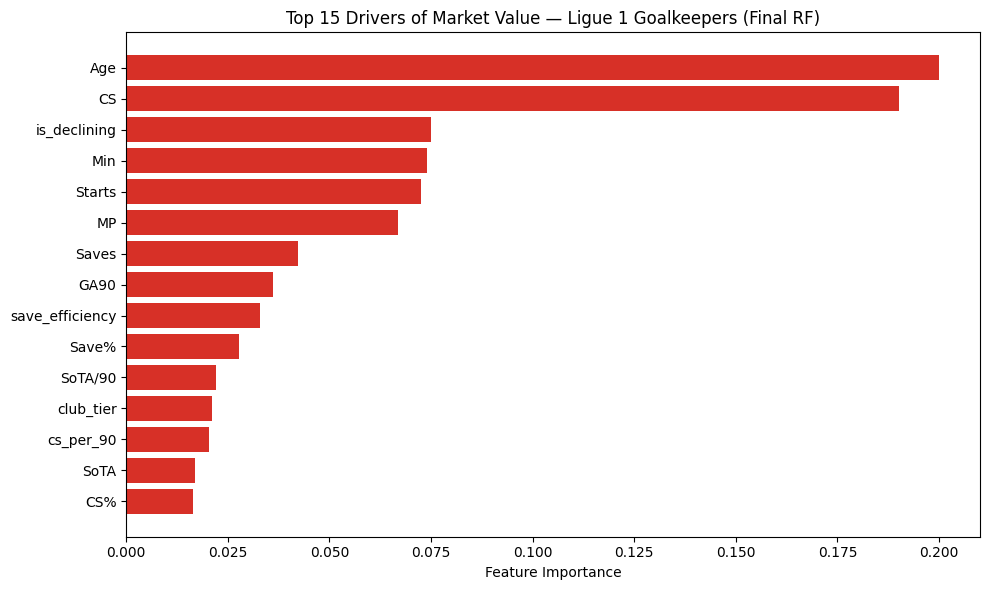


Worst 10 predictions on TEST SET:
         player_name season      actual   predicted       error
Gianluigi Donnarumma  24-25 €40,000,000  €4,039,301 €35,960,699
Gianluigi Donnarumma  22-23 €45,000,000 €12,094,620 €32,905,380
     Lucas Chevalier  24-25 €30,000,000 €10,184,837 €19,815,163
        Mike Maignan  20-21 €25,000,000 €11,521,351 €13,478,649
     Lucas Chevalier  23-24 €25,000,000 €13,302,493 €11,697,507
     Alphonse Areola  16-17 €10,000,000  €1,260,524  €8,739,476
        Keylor Navas  18-19 €10,000,000  €1,982,727  €8,017,273
        Keylor Navas  20-21 €12,000,000  €5,011,800  €6,988,200
       Etienne Green  21-22  €7,000,000  €1,473,619  €5,526,381
      Gerónimo Rulli  24-25  €8,000,000  €2,961,200  €5,038,800

Sample predictions from TEST SET:
      player_name season      actual   predicted
       Paul Nardi  20-21  €1,800,000  €2,145,973
      Kevin Trapp  16-17 €10,000,000  €5,688,177
     Keylor Navas  18-19 €10,000,000  €1,982,727
   Steve Mandanda  24-25    €5

In [66]:
#Ligue 1 Random Forests

df_ligue1_outfield = df_outfield[
    df_outfield["Squad"].isin(ligue1_teams)
].copy()

df_ligue1_gk = df_gk_model[
    df_gk_model["Squad"].isin(ligue1_teams)
].copy()

print("Ligue 1 Outfield Rows:", len(df_ligue1_outfield))
print("Ligue 1 GK Rows:", len(df_ligue1_gk))


# ── 1. APPLY FEATURE ENGINEERING ──────────────────────────────────────────────
df_ligue1_outfield = engineer_features(df_ligue1_outfield, is_gk=False)
df_ligue1_gk       = engineer_features(df_ligue1_gk, is_gk=True)


# ── 2. EPL FEATURE LISTS ──────────────────────────────────────────────────────
LIGUE1_OUTFIELD_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min", "SubIn", "min_per_game",

    # Goal output
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",

    # Rates
    "G/90", "Ast/90", "goal_involvement_90",

    # Shooting
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",

    # Defense
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",

    # Discipline
    "CrdY", "CrdR",

] + [c for c in pos_dummies.columns]

LIGUE1_OUTFIELD_FEATURES = [
    f for f in LIGUE1_OUTFIELD_FEATURES
    if f in df_ligue1_outfield.columns
]


LIGUE1_GK_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min",

    # GK core
    "GA", "GA90", "SoTA", "Saves", "Save%",
    "CS", "CS%", "Save/90", "SoTA/90",

    # Engineered
    "save_efficiency", "cs_rate",
    "cs_per_90", "ga_per_sota",

    # Discipline
    "CrdY", "CrdR", "CrdY/90",
    "Fls/90", "Fls", "Int", "TklW",
]

LIGUE1_GK_FEATURES = [
    f for f in LIGUE1_GK_FEATURES
    if f in df_ligue1_gk.columns
]


# ── 3. RUN Ligue 1 RANDOM FOREST MODELS ──────────────────────────────────────────
ligue1_rf_outfield_pipeline, ligue1_rf_outfield_coefs, df_ligue1_outfield = run_final_rf_model(
    df_ligue1_outfield,
    LIGUE1_OUTFIELD_FEATURES,
    "Ligue 1 Outfield Players"
)

ligue1_rf_gk_pipeline, ligue1_rf_gk_coefs, df_ligue1_gk = run_final_rf_model(
    df_ligue1_gk,
    LIGUE1_GK_FEATURES,
    "Ligue 1 Goalkeepers"
)


# ── 4. SAVE Ligue 1 RESULTS ───────────────────────────────────────────────────────
pd.concat([df_ligue1_outfield, df_ligue1_gk]).to_csv(
    "ligue1_model_predictions_final.csv",
    index=False
)

ligue1_rf_outfield_coefs.to_csv(
    "feature_importance_ligue1_outfield_final.csv",
    index=False
)

ligue1_rf_gk_coefs.to_csv(
    "feature_importance_ligue1_gk_final.csv",
    index=False
)

print("\nLigue 1 Random Forest models complete and saved.")

Serie A Outfield Rows: 3104
Serie A GK Rows: 219

── Serie A Outfield Players | Final Random Forest ──────────────────────────────
Train rows    : 2483
Test rows     : 621
CV R²         : 0.656 ± 0.028  (train set)
CV MAE        : 0.570 ± 0.014  (log scale)
Test R²       : 0.651  ← honest performance on unseen data
Test MAE      : €4,447,403
Test MSE   : 58,069,765,214,441
Test RMSE  : €7,620,352

Top 15 drivers:
          feature  importance
        club_tier    0.271255
              Age    0.148131
               Sh    0.113422
              SoT    0.064296
     is_declining    0.053418
              Min    0.034821
              G+A    0.025756
               MP    0.020026
           G+A-PK    0.019870
     min_per_game    0.017893
           Starts    0.016329
defensive_actions    0.016088
           Fls/90    0.013006
              Crs    0.011940
            Sh/90    0.011506


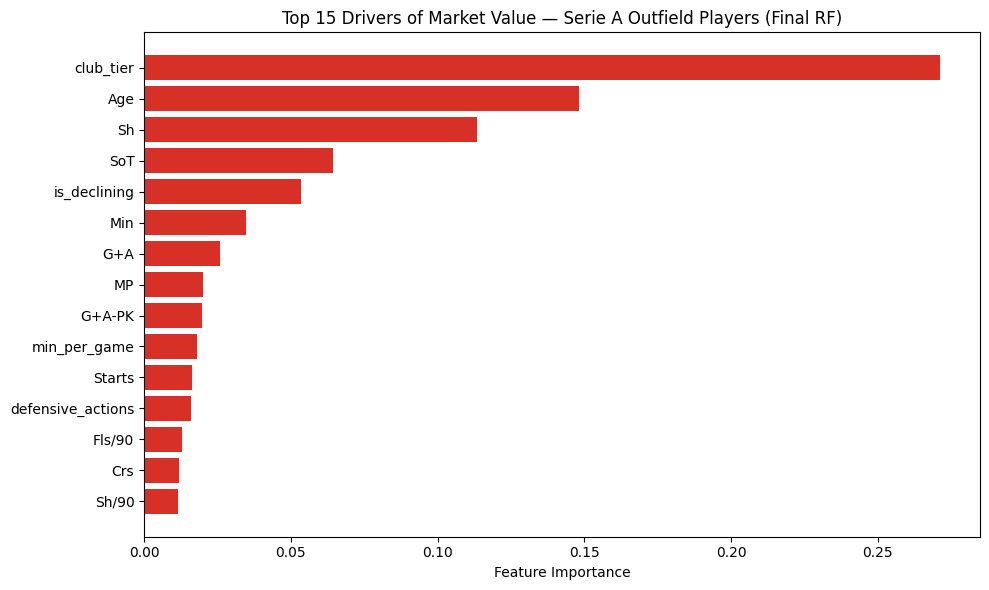


Worst 10 predictions on TEST SET:
     player_name season      actual   predicted       error
  Dušan Vlahović  21-22 €85,000,000 €32,612,280 €52,387,720
  Milan Škriniar  22-23 €50,000,000 €15,353,355 €34,646,645
Radja Nainggolan  17-18 €45,000,000 €11,122,145 €33,877,855
  Nicolò Barella  20-21 €65,000,000 €32,960,544 €32,039,456
 Lorenzo Insigne  18-19 €65,000,000 €33,280,958 €31,719,042
Matthijs de Ligt  19-20 €67,500,000 €35,980,202 €31,519,798
Lautaro Martínez  18-19 €30,000,000 €59,520,566 €29,520,566
     Rafael Leão  22-23 €90,000,000 €62,157,105 €27,842,895
   Douglas Costa  17-18 €55,000,000 €27,297,176 €27,702,824
       Manu Koné  24-25 €40,000,000 €12,899,424 €27,100,576

Sample predictions from TEST SET:
        player_name season      actual   predicted
      Amir Rrahmani  21-22 €25,000,000 €31,432,567
Stephan El Shaarawy  23-24  €5,000,000  €3,539,619
     Ardian Ismajli  20-21  €2,500,000  €2,608,117
      Joan González  23-24  €4,500,000  €3,478,034
       Bruno Am

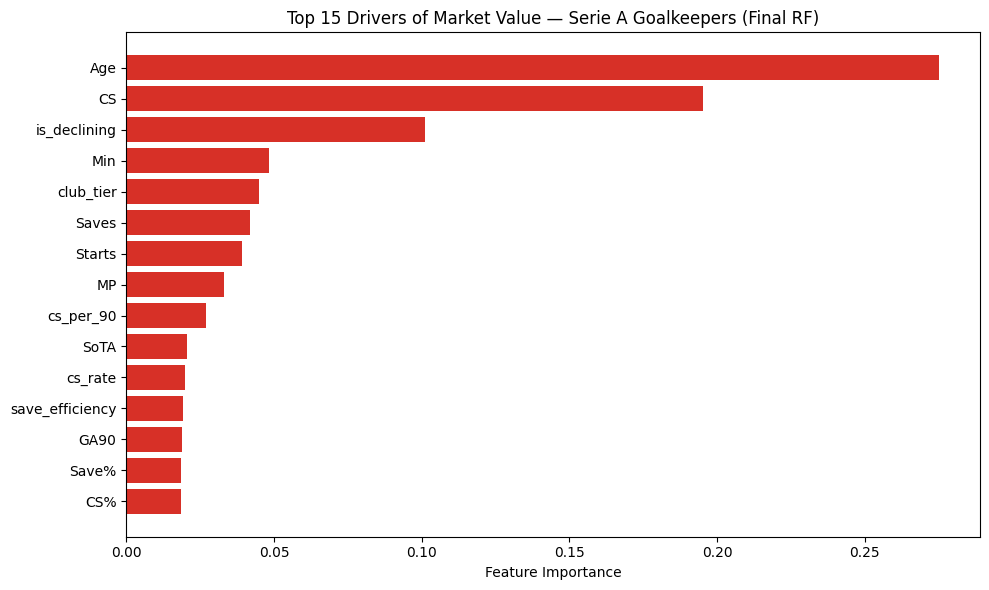


Worst 10 predictions on TEST SET:
         player_name season      actual   predicted       error
Gianluigi Donnarumma  20-21 €60,000,000 €26,252,598 €33,747,402
          Alex Meret  19-20 €28,000,000  €5,011,584 €22,988,416
   Wojciech Szczesny  20-21 €25,000,000  €6,773,530 €18,226,470
      Alessio Cragno  20-21 €20,000,000  €7,518,726 €12,481,274
        Mike Maignan  24-25 €25,000,000 €14,990,288 €10,009,712
         Mile Svilar  24-25 €25,000,000 €16,123,483  €8,876,517
    Marco Sportiello  17-18  €6,000,000 €14,523,623  €8,523,623
   Wojciech Szczesny  17-18 €20,000,000 €12,335,053  €7,664,947
           Pau López  18-19 €20,000,000 €12,335,394  €7,664,606
          Alex Meret  21-22 €10,000,000  €2,755,812  €7,244,188

Sample predictions from TEST SET:
        player_name season      actual   predicted
   Samir Handanovič  18-19  €6,000,000  €2,513,545
 Michele Cerofolini  23-24    €700,000  €1,174,419
Michele Di Gregorio  23-24 €18,000,000 €13,059,073
   Samir Handanovič  1

In [67]:
#Serie A Random Forests

df_serie_a_outfield = df_outfield[
    df_outfield["Squad"].isin(serie_a_teams)
].copy()

df_serie_a_gk = df_gk_model[
    df_gk_model["Squad"].isin(serie_a_teams)
].copy()

print("Serie A Outfield Rows:", len(df_serie_a_outfield))
print("Serie A GK Rows:", len(df_serie_a_gk))


# ── 1. APPLY FEATURE ENGINEERING ──────────────────────────────────────────────
df_serie_a_outfield = engineer_features(df_serie_a_outfield, is_gk=False)
df_serie_a_gk       = engineer_features(df_serie_a_gk, is_gk=True)


# ── 2. SERIE A FEATURE LISTS ──────────────────────────────────────────────────────
SERIE_A_OUTFIELD_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min", "SubIn", "min_per_game",

    # Goal output
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",

    # Rates
    "G/90", "Ast/90", "goal_involvement_90",

    # Shooting
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",

    # Defense
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",

    # Discipline
    "CrdY", "CrdR",

] + [c for c in pos_dummies.columns]

SERIE_A_OUTFIELD_FEATURES = [
    f for f in SERIE_A_OUTFIELD_FEATURES
    if f in df_serie_a_outfield.columns
]


SERIE_A_GK_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min",

    # GK core
    "GA", "GA90", "SoTA", "Saves", "Save%",
    "CS", "CS%", "Save/90", "SoTA/90",

    # Engineered
    "save_efficiency", "cs_rate",
    "cs_per_90", "ga_per_sota",

    # Discipline
    "CrdY", "CrdR", "CrdY/90",
    "Fls/90", "Fls", "Int", "TklW",
]

SERIE_A_GK_FEATURES = [
    f for f in SERIE_A_GK_FEATURES
    if f in df_serie_a_gk.columns
]


# ── 3. RUN SERIE A RANDOM FOREST MODELS ──────────────────────────────────────────
serie_a_rf_outfield_pipeline, serie_a_rf_outfield_coefs, df_serie_a_outfield = run_final_rf_model(
    df_serie_a_outfield,
    SERIE_A_OUTFIELD_FEATURES,
    "Serie A Outfield Players"
)

serie_a_rf_gk_pipeline, serie_a_rf_gk_coefs, df_serie_a_gk = run_final_rf_model(
    df_serie_a_gk,
    SERIE_A_GK_FEATURES,
    "Serie A Goalkeepers"
)


# ── 4. SAVE SERIE_A RESULTS ───────────────────────────────────────────────────────
pd.concat([df_serie_a_outfield, df_serie_a_gk]).to_csv(
    "serie_a_model_predictions_final.csv",
    index=False
)

serie_a_rf_outfield_coefs.to_csv(
    "feature_importance_serie_a_outfield_final.csv",
    index=False
)

serie_a_rf_gk_coefs.to_csv(
    "feature_importance_serie_a_gk_final.csv",
    index=False
)

print("\nSerie A Random Forest models complete and saved.")

####################################################################################################################################################################################
####################                                                   DOING IT BASED ON POSITION                                                               ####################
####################################################################################################################################################################################

RANDOM FORESTS

Forwards dataset rows: 4204

── Forward Players | Final Random Forest ──────────────────────────────
Train rows    : 3363
Test rows     : 841
CV R²         : 0.643 ± 0.021  (train set)
CV MAE        : 0.594 ± 0.020  (log scale)
Test R²       : 0.617  ← honest performance on unseen data
Test MAE      : €8,436,324
Test MSE   : 266,845,344,296,309
Test RMSE  : €16,335,402

Top 15 drivers:
            feature  importance
          club_tier    0.322534
                 Sh    0.097628
                Age    0.090641
                SoT    0.079284
             G+A-PK    0.071082
                G+A    0.041528
       is_declining    0.035515
       min_per_game    0.024242
             Fls/90    0.016868
                Min    0.015760
                Crs    0.011713
goal_involvement_90    0.011574
          G+A-PK/90    0.010817
                Fld    0.010441
goal_contrib_per_sh    0.009210


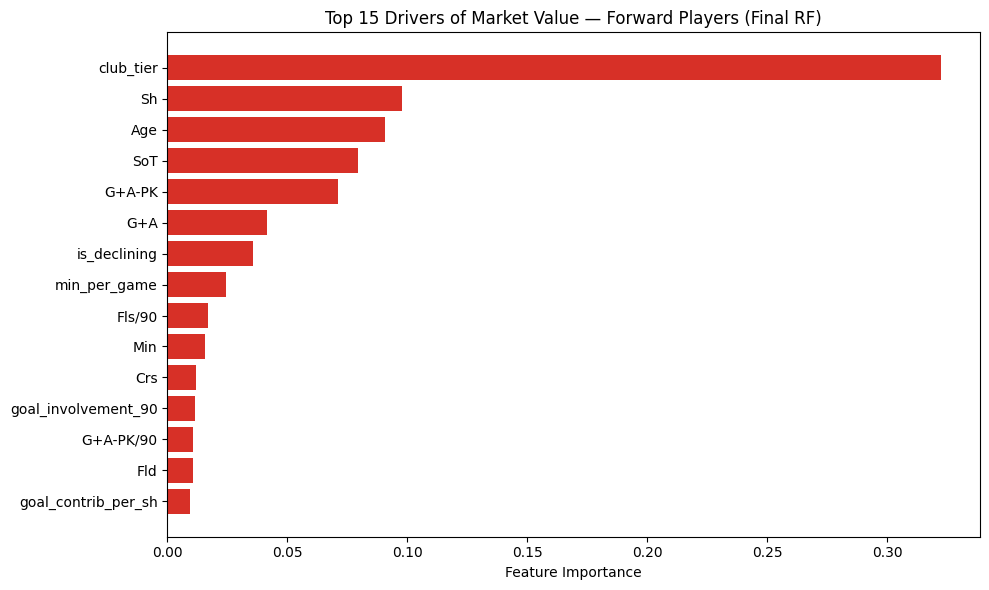


Worst 10 predictions on TEST SET:
    player_name season       actual   predicted        error
         Neymar  18-19 €180,000,000 €57,754,560 €122,245,440
  Kylian Mbappé  18-19 €200,000,000 €96,331,694 €103,668,306
 Erling Haaland  24-25 €180,000,000 €76,980,584 €103,019,416
Vinicius Junior  24-25 €170,000,000 €67,099,882 €102,900,118
 Erling Haaland  23-24 €180,000,000 €81,884,096  €98,115,904
  Kylian Mbappé  24-25 €180,000,000 €91,099,624  €88,900,376
  Kylian Mbappé  19-20 €180,000,000 €93,921,839  €86,078,161
 Alexander Isak  24-25 €120,000,000 €35,699,118  €84,300,882
 Erling Haaland  22-23 €180,000,000 €96,145,862  €83,854,138
  Kylian Mbappé  22-23 €180,000,000 €97,598,218  €82,401,782

Sample predictions from TEST SET:
       player_name season       actual   predicted
   Lorenzo Colombo  23-24   €6,000,000  €4,893,130
    Yassine Kechta  24-25   €5,000,000  €3,801,227
   Alberto Moleiro  23-24  €15,000,000  €6,548,531
     Matheus Cunha  22-23  €25,000,000  €5,816,701
    

In [68]:
#FORWARD Random Forests
df_fw = df_outfield[
    df_outfield["Pos"].str.contains("FW", na=False)
].copy()

print(f"Forwards dataset rows: {len(df_fw)}")


# ── 1. APPLY FEATURE ENGINEERING ──────────────────────────────────────────────
df_fw = engineer_features(df_fw, is_gk=False)


# ── 2. SERIE A FEATURE LISTS ──────────────────────────────────────────────────────
FW_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min", "SubIn", "min_per_game",

    # Goal output
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",

    # Rates
    "G/90", "Ast/90", "goal_involvement_90",

    # Shooting
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",

    # Defense
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",

    # Discipline
    "CrdY", "CrdR",

] + [c for c in pos_dummies.columns]

FW_FEATURES = [
    f for f in FW_FEATURES
    if f in df_fw.columns
]


# ── 3. RUN FORWARD RANDOM FOREST MODELS ──────────────────────────────────────────
fw_rf_pipeline, fw_rf_coefs, df_fw = run_final_rf_model(
    df_fw,
    FW_FEATURES,
    "Forward Players"
)

# ── 4. SAVE FW RESULTS ───────────────────────────────────────────────────────
df_fw.to_csv(
    "forward_model_predictions_final.csv",
    index=False
)

fw_rf_coefs.to_csv(
    "feature_importance_forward_final.csv",
    index=False
)

print("\nForward Random Forest models complete and saved.")

Midfield dataset rows: 8887

── Midfield Players | Final Random Forest ──────────────────────────────
Train rows    : 7109
Test rows     : 1778
CV R²         : 0.588 ± 0.017  (train set)
CV MAE        : 0.616 ± 0.010  (log scale)
Test R²       : 0.634  ← honest performance on unseen data
Test MAE      : €6,451,982
Test MSE   : 152,250,090,115,932
Test RMSE  : €12,338,966

Top 15 drivers:
          feature  importance
        club_tier    0.306230
               Sh    0.136101
              Age    0.112560
              SoT    0.047442
     is_declining    0.043060
           G+A-PK    0.031575
     min_per_game    0.026896
              Min    0.026334
              G+A    0.020886
defensive_actions    0.019272
              Fld    0.016178
           Fls/90    0.014946
           Starts    0.014431
             TklW    0.013092
              Crs    0.011735


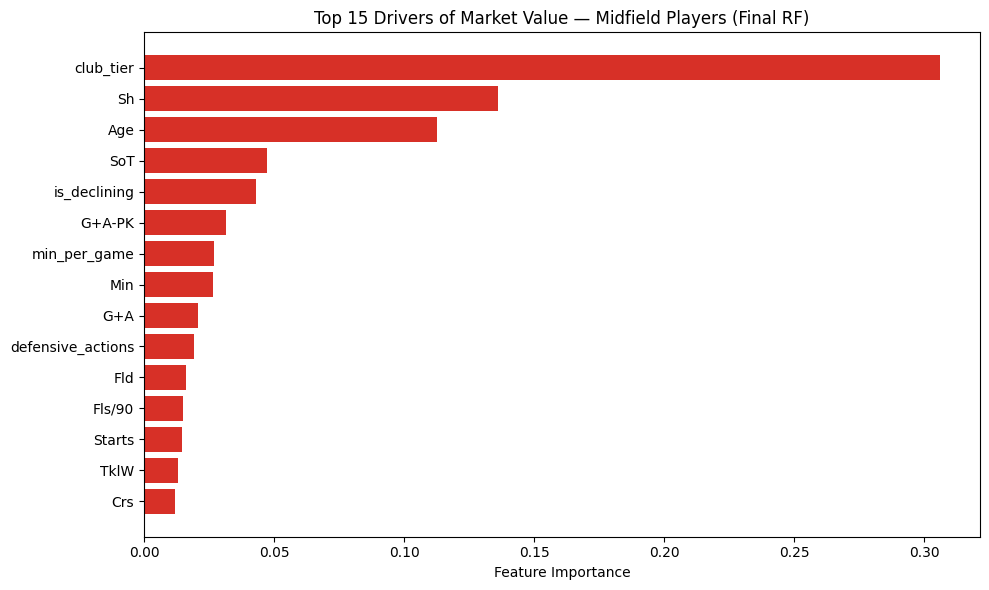


Worst 10 predictions on TEST SET:
      player_name season       actual   predicted        error
    Florian Wirtz  24-25 €140,000,000 €33,838,266 €106,161,734
    Florian Wirtz  23-24 €130,000,000 €30,128,849  €99,871,151
            Rodri  23-24 €120,000,000 €25,570,717  €94,429,283
  Kevin De Bruyne  17-18 €150,000,000 €57,682,634  €92,317,366
            Pedri  24-25 €140,000,000 €49,809,861  €90,190,139
    Jamal Musiala  24-25 €140,000,000 €53,274,442  €86,725,558
Eduardo Camavinga  23-24 €100,000,000 €23,458,696  €76,541,304
           Neymar  19-20 €128,000,000 €57,982,132  €70,017,868
   Moisés Caicedo  24-25  €90,000,000 €20,562,590  €69,437,410
    Jamal Musiala  23-24 €120,000,000 €51,693,682  €68,306,318

Sample predictions from TEST SET:
       player_name season      actual   predicted
         Moi Gómez  19-20  €9,000,000 €10,929,757
      Edgar Méndez  16-17  €2,000,000  €7,645,066
Ruslan Malinovskyi  23-24  €8,000,000  €3,426,170
    Jonathan Bamba  19-20 €16,000,000

In [69]:
#Midfield Random Forests
df_mf = df_outfield[
    df_outfield["Pos"].str.contains("MF", na=False)
].copy()

print(f"Midfield dataset rows: {len(df_mf)}")


# ── 1. APPLY FEATURE ENGINEERING ──────────────────────────────────────────────
df_mf = engineer_features(df_mf, is_gk=False)


# ── 2. Midfield FEATURE LISTS ──────────────────────────────────────────────────────
MF_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min", "SubIn", "min_per_game",

    # Goal output
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",

    # Rates
    "G/90", "Ast/90", "goal_involvement_90",

    # Shooting
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",

    # Defense
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",

    # Discipline
    "CrdY", "CrdR",

] + [c for c in pos_dummies.columns]

MF_FEATURES = [
    f for f in MF_FEATURES
    if f in df_mf.columns
]


# ── 3. RUN Midfield RANDOM FOREST MODELS ──────────────────────────────────────────
mf_rf_pipeline, mf_rf_coefs, df_mf = run_final_rf_model(
    df_mf,
    MF_FEATURES,
    "Midfield Players"
)

# ── 4. SAVE MF RESULTS ───────────────────────────────────────────────────────
df_mf.to_csv(
    "midfield_model_predictions_final.csv",
    index=False
)

mf_rf_coefs.to_csv(
    "feature_importance_midfield_final.csv",
    index=False
)

print("\nMidfield Random Forest models complete and saved.")

Defender dataset rows: 6151


<>:69: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:69: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/var/folders/2j/bknf_0rj7cx6c2xncrgdpc5r0000gn/T/ipykernel_51999/253728474.py:69: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  print("\Defense Random Forest models complete and saved.")



── Defense Players | Final Random Forest ──────────────────────────────
Train rows    : 4920
Test rows     : 1231
CV R²         : 0.590 ± 0.014  (train set)
CV MAE        : 0.622 ± 0.010  (log scale)
Test R²       : 0.603  ← honest performance on unseen data
Test MAE      : €5,244,033
Test MSE   : 87,509,627,075,536
Test RMSE  : €9,354,658

Top 15 drivers:
          feature  importance
        club_tier    0.304851
              Age    0.170166
               Sh    0.096699
     is_declining    0.054799
              Min    0.048471
     min_per_game    0.028719
defensive_actions    0.024171
              SoT    0.023753
           Starts    0.021718
           Fls/90    0.019602
            Sh/90    0.019254
              Crs    0.018648
             TklW    0.014090
          CrdY/90    0.013691
              Int    0.013419


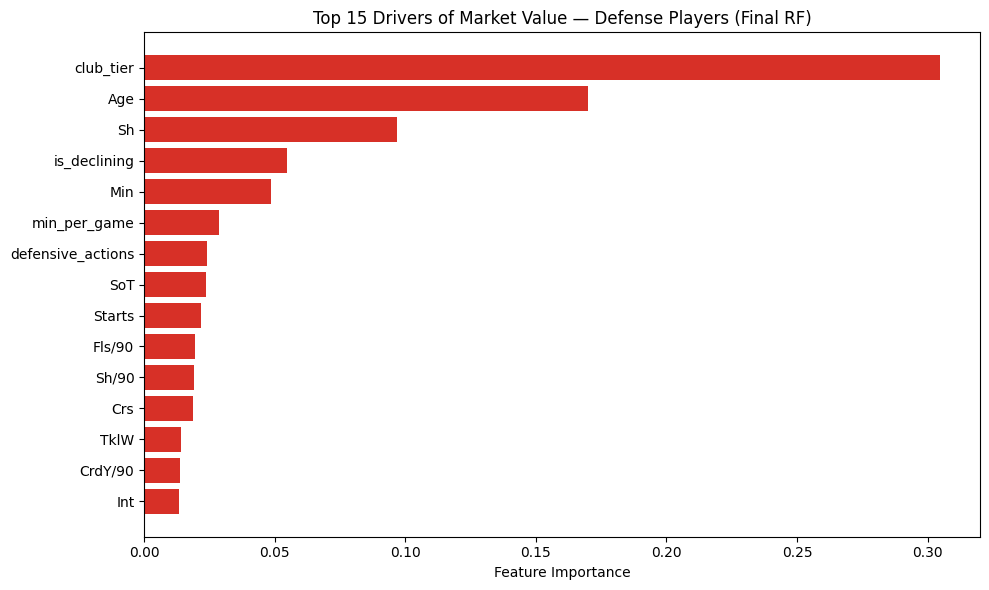


Worst 10 predictions on TEST SET:
      player_name season      actual   predicted       error
      Pau Cubarsí  24-25 €80,000,000 €28,607,089 €51,392,911
Kalidou Koulibaly  18-19 €75,000,000 €23,894,978 €51,105,022
       Rúben Dias  23-24 €80,000,000 €32,001,056 €47,998,944
 Matthijs de Ligt  23-24 €65,000,000 €17,451,706 €47,548,294
  Virgil van Dijk  18-19 €90,000,000 €43,225,286 €46,774,714
      Nuno Mendes  24-25 €70,000,000 €25,157,415 €44,842,585
   Josko Gvardiol  22-23 €75,000,000 €30,394,346 €44,605,654
  Frenkie de Jong  20-21 €90,000,000 €46,244,123 €43,755,877
        Leny Yoro  24-25 €55,000,000 €11,556,520 €43,443,480
       Marquinhos  18-19 €65,000,000 €22,721,214 €42,278,786

Sample predictions from TEST SET:
             player_name season      actual   predicted
             Jhon Lucumí  22-23 €12,000,000 €13,912,170
              Ryan Giles  23-24  €4,500,000  €2,435,352
        Daniel Brosinski  19-20  €2,000,000  €2,713,365
               Joe Bryan  19-20  €5

In [70]:
#Defender Random Forests
df_def = df_outfield[
    df_outfield["Pos"].str.contains("DF", na=False)
].copy()

print(f"Defender dataset rows: {len(df_def)}")


# ── 1. APPLY FEATURE ENGINEERING ──────────────────────────────────────────────
df_def = engineer_features(df_def, is_gk=False)


# ── 2. Defense FEATURE LISTS ──────────────────────────────────────────────────────
DF_FEATURES = [
    # Context
    "club_tier",

    # Age
    "Age", "is_peak_age", "is_young", "is_declining",

    # Playing time
    "MP", "Starts", "Min", "SubIn", "min_per_game",

    # Goal output
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
    "G+A-PK", "G+A-PK/90", "G-PK/90",

    # Rates
    "G/90", "Ast/90", "goal_involvement_90",

    # Shooting
    "Sh", "SoT", "SoT%", "Sh/90", "SoT/90",
    "G/Sh", "G/SoT", "shot_efficiency", "goal_contrib_per_sh",

    # Defense
    "Fls", "Fld", "Off", "Crs", "Int", "TklW",
    "2CrdY", "OG", "DirectRCrd",
    "CrdY/90", "CrdR/90", "Fls/90", "defensive_actions",

    # Discipline
    "CrdY", "CrdR",

] + [c for c in pos_dummies.columns]

DF_FEATURES = [
    f for f in DF_FEATURES
    if f in df_def.columns
]


# ── 3. RUN Defense RANDOM FOREST MODELS ──────────────────────────────────────────
def_rf_pipeline, def_rf_coefs, df_def = run_final_rf_model(
    df_def,
    DF_FEATURES,
    "Defense Players"
)

# ── 4. SAVE Defense RESULTS ───────────────────────────────────────────────────────
df_def.to_csv(
    "defense_model_predictions_final.csv",
    index=False
)

def_rf_coefs.to_csv(
    "feature_importance_defense_final.csv",
    index=False
)

print("\Defense Random Forest models complete and saved.")

LINEAR REGRESSION FOR POSITIONS

Forward Rows: 4204

── Forward Players | Linear Regression ──────────────────────────────
Train rows    : 3363
Test rows     : 841
CV R²         : 0.629 ± 0.014  (train set)
CV MAE        : 0.607 ± 0.012  (log scale)
Test R²       : 0.616  ← honest performance on unseen data
Test MAE      : €8,144,593
Test MSE   : 223,242,771,097,706
Test RMSE  : €14,941,311

Top 15 drivers (by absolute coefficient):
     feature  coefficient
   club_tier    -0.535994
         Age    -0.430980
min_per_game     0.388600
         Min    -0.364953
      Fls/90    -0.233028
          Sh     0.202355
    is_young    -0.198946
   G+A-PK/90     0.184036
     G-PK/90    -0.167200
        G/Sh     0.160775
is_declining    -0.151585
          MP     0.150990
       Sh/90     0.128681
         SoT     0.127540
         Fls     0.124675


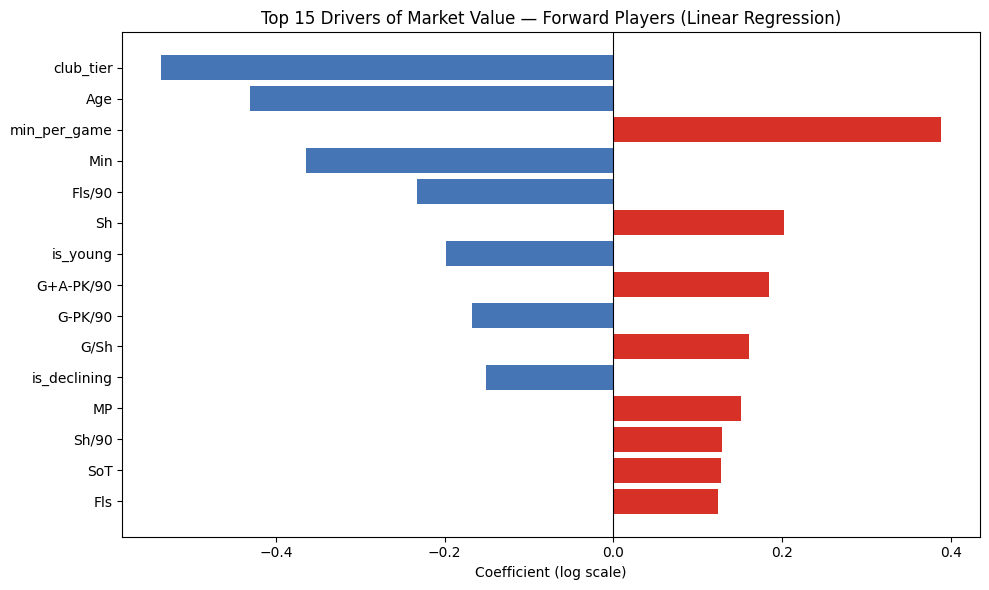


Worst 10 predictions on TEST SET:
      player_name season       actual    predicted        error
           Neymar  18-19 €180,000,000  €69,250,271 €110,749,729
    Kylian Mbappé  19-20 €180,000,000  €70,353,420 €109,646,580
  Vinicius Junior  24-25 €170,000,000  €68,766,541 €101,233,459
   Alexander Isak  24-25 €120,000,000  €40,563,245  €79,436,755
      Loïs Openda  23-24  €60,000,000 €131,388,728  €71,388,728
Antoine Griezmann  19-20  €96,000,000  €27,270,232  €68,729,768
      Eden Hazard  17-18 €110,000,000  €44,140,942  €65,859,058
     Mauro Icardi  16-17  €50,000,000 €113,950,157  €63,950,157
             Gavi  22-23  €90,000,000  €26,868,962  €63,131,038
   Erling Haaland  24-25 €180,000,000 €117,094,086  €62,905,914

Sample predictions from TEST SET:
       player_name season       actual   predicted
   Lorenzo Colombo  23-24   €6,000,000  €4,025,115
    Yassine Kechta  24-25   €5,000,000  €2,789,605
   Alberto Moleiro  23-24  €15,000,000  €5,756,524
     Matheus Cunha  22

In [71]:
#Forwards Linear Regression
df_fw = df_outfield[
    df_outfield["Pos"].str.contains("FW", na=False)
].copy()

print("Forward Rows:", len(df_fw))

# ── 1. FEATURE ENGINEERING ────────────────────────────────────────────────────
df_fw = engineer_features(df_fw, is_gk=False)

# ── 2. FEATURE LISTS ──────────────────────────────────────────────────────────
FW_FEATURES = [
    f for f in OUTFIELD_FEATURES_FINAL
    if f in df_fw.columns
]

# ── 3. RUN FORWARD MODELS ─────────────────────────────────────────────────────────
fw_lr_pipeline, fw_lr_coefs, df_fw = run_final_lr_model(
    df_fw,
    FW_FEATURES,
    "Forward Players"
)

# ── 4. SAVE FORWARD RESULTS ───────────────────────────────────────────────────────
df_fw.to_csv(
    "forward_model_predictions_final.csv",
    index=False
)

fw_lr_coefs.to_csv(
    "feature_importance_forward_final.csv",
    index=False
)

print("\nForward models complete and saved.")

Midfield Rows: 8887

── Midfield Players | Linear Regression ──────────────────────────────
Train rows    : 7109
Test rows     : 1778
CV R²         : 0.562 ± 0.022  (train set)
CV MAE        : 0.634 ± 0.013  (log scale)
Test R²       : 0.604  ← honest performance on unseen data
Test MAE      : €6,760,055
Test MSE   : 165,400,858,083,535
Test RMSE  : €12,860,826

Top 15 drivers (by absolute coefficient):
     feature  coefficient
   club_tier    -0.541525
         Age    -0.353673
   G+A-PK/90    -0.293252
        G/90     0.262996
      Ast/90     0.221842
          Sh     0.190951
      Fls/90    -0.183321
is_declining    -0.164346
min_per_game     0.152021
    is_young    -0.137311
         Fls     0.136049
        SoT%     0.091507
     CrdY/90     0.088683
       Sh/90     0.082877
        TklW     0.073514


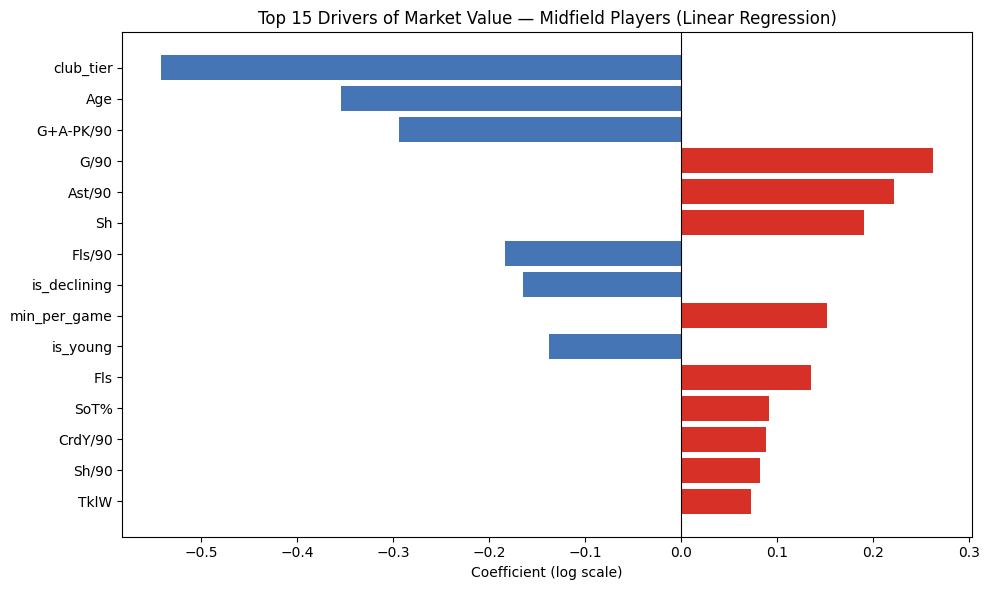


Worst 10 predictions on TEST SET:
      player_name season       actual    predicted        error
    Florian Wirtz  24-25 €140,000,000  €32,172,838 €107,827,162
            Pedri  24-25 €140,000,000  €37,995,035 €102,004,965
    Florian Wirtz  23-24 €130,000,000  €35,433,043  €94,566,957
        Dele Alli  16-17  €45,000,000 €131,553,764  €86,553,764
    Jamal Musiala  24-25 €140,000,000  €58,773,730  €81,226,270
           Neymar  19-20 €128,000,000  €46,885,505  €81,114,495
            Rodri  23-24 €120,000,000  €39,691,111  €80,308,889
Eduardo Camavinga  23-24 €100,000,000  €24,840,194  €75,159,806
       Paul Pogba  19-20  €80,000,000  €14,608,070  €65,391,930
Eduardo Camavinga  22-23  €85,000,000  €20,078,258  €64,921,742

Sample predictions from TEST SET:
       player_name season      actual   predicted
         Moi Gómez  19-20  €9,000,000  €9,945,209
      Edgar Méndez  16-17  €2,000,000  €9,728,552
Ruslan Malinovskyi  23-24  €8,000,000  €4,517,749
    Jonathan Bamba  19-20 

In [72]:
#Midfield Linear Regression
df_mf = df_outfield[
    df_outfield["Pos"].str.contains("MF", na=False)
].copy()

print("Midfield Rows:", len(df_mf))

# ── 1. FEATURE ENGINEERING ────────────────────────────────────────────────────
df_mf = engineer_features(df_mf, is_gk=False)

# ── 2. FEATURE LISTS ──────────────────────────────────────────────────────────
MF_FEATURES = [
    f for f in OUTFIELD_FEATURES_FINAL
    if f in df_mf.columns
]

# ── 3. RUN Midfield MODELS ─────────────────────────────────────────────────────────
mf_lr_pipeline, mf_lr_coefs, df_mf = run_final_lr_model(
    df_mf,
    MF_FEATURES,
    "Midfield Players"
)

# ── 4. SAVE Midfield RESULTS ───────────────────────────────────────────────────────
df_mf.to_csv(
    "midfield_model_predictions_final.csv",
    index=False
)

mf_lr_coefs.to_csv(
    "feature_importance_midfield_final.csv",
    index=False
)

print("\nMidfield models complete and saved.")

Defense Rows: 6151

── Defense Players | Linear Regression ──────────────────────────────
Train rows    : 4920
Test rows     : 1231
CV R²         : 0.548 ± 0.015  (train set)
CV MAE        : 0.650 ± 0.012  (log scale)
Test R²       : 0.553  ← honest performance on unseen data
Test MAE      : €5,765,453
Test MSE   : 110,385,165,181,107
Test RMSE  : €10,506,434

Top 15 drivers (by absolute coefficient):
            feature  coefficient
goal_involvement_90    -0.850956
          G+A-PK/90     0.834519
               G/90     0.798967
            G-PK/90    -0.723767
          club_tier    -0.560269
                Age    -0.474869
                 Sh     0.286541
           is_young    -0.207225
                Fls     0.179376
       is_declining    -0.177844
                Min     0.169490
             Fls/90    -0.150305
                Crs    -0.129043
               SoT%     0.111763
               CrdY    -0.111392


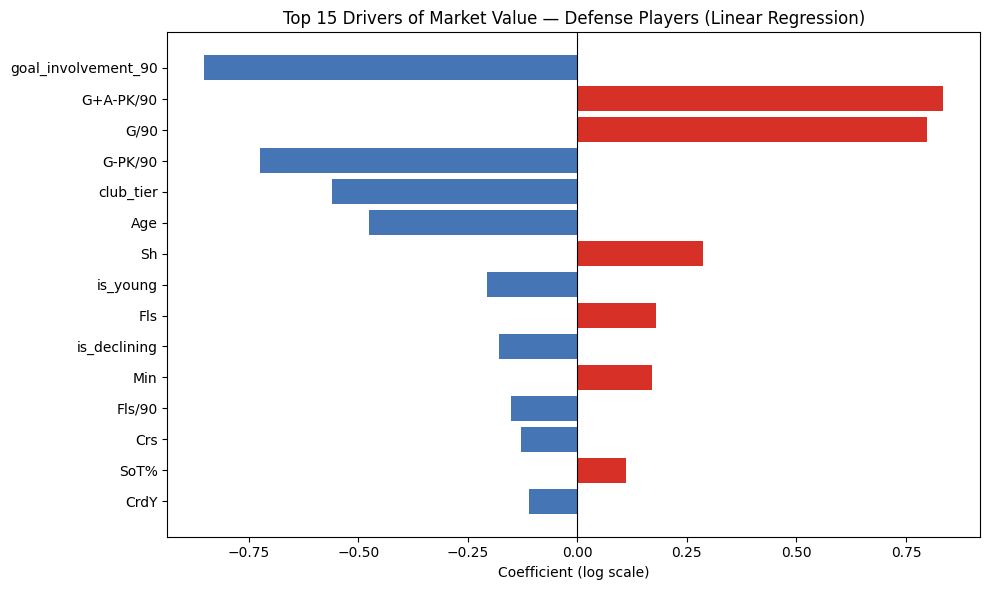


Worst 10 predictions on TEST SET:
           player_name season      actual    predicted       error
           Samuel Lino  23-24 €30,000,000 €108,942,154 €78,942,154
Trent Alexander-Arnold  19-20 €99,000,000  €32,348,689 €66,651,311
           Pedro Porro  23-24 €45,000,000  €98,630,235 €53,630,235
            Rúben Dias  23-24 €80,000,000  €26,898,694 €53,101,306
     Kalidou Koulibaly  18-19 €75,000,000  €22,607,371 €52,392,629
           Nuno Mendes  24-25 €70,000,000  €17,773,286 €52,226,714
        Josko Gvardiol  22-23 €75,000,000  €23,812,564 €51,187,436
       Aymeric Laporte  19-20 €60,000,000  €11,829,540 €48,170,460
          Jules Koundé  21-22 €60,000,000  €12,321,102 €47,678,898
           Pau Cubarsí  24-25 €80,000,000  €32,543,892 €47,456,108

Sample predictions from TEST SET:
             player_name season      actual   predicted
             Jhon Lucumí  22-23 €12,000,000 €12,864,010
              Ryan Giles  23-24  €4,500,000  €2,331,529
        Daniel Brosinski 

In [73]:
#Defense Linear Regression
df_def = df_outfield[
    df_outfield["Pos"].str.contains("DF", na=False)
].copy()

print("Defense Rows:", len(df_def))

# ── 1. FEATURE ENGINEERING ────────────────────────────────────────────────────
df_def = engineer_features(df_def, is_gk=False)

# ── 2. FEATURE LISTS ──────────────────────────────────────────────────────────
DEF_FEATURES = [
    f for f in OUTFIELD_FEATURES_FINAL
    if f in df_def.columns
]

# ── 3. RUN Defense MODELS ─────────────────────────────────────────────────────────
def_lr_pipeline, def_lr_coefs, df_def = run_final_lr_model(
    df_def,
    DEF_FEATURES,
    "Defense Players"
)

# ── 4. SAVE Defense RESULTS ───────────────────────────────────────────────────────
df_def.to_csv(
    "defense_model_predictions_final.csv",
    index=False
)

def_lr_coefs.to_csv(
    "feature_importance_defense_final.csv",
    index=False
)

print("\nDefense models complete and saved.")

######################################################################################################################################################################################
##########################################        USING K-MEAN CLUSTERING ############################
######################################################################################################################################################################################

df_outfield columns after dedup  : 71
df_gk_active columns after dedup : 70

Outfield cluster cols : []
GK cluster cols       : []

Outfield features with cluster : 49
GK features with cluster       : 28

── Outfield Players | RF + Cluster Feature ──────────────────────────────
Train rows    : 11992
Test rows     : 2998
CV R²         : 0.615 ± 0.011  (train set)
CV MAE        : 0.609 ± 0.012  (log scale)
Test R²       : 0.633  ← honest performance on unseen data
Test MAE      : €5,871,577
Test MSE   : 112,664,379,266,242
Test RMSE  : €10,614,348

Top 15 drivers:
          feature  importance
        club_tier    0.321918
              Age    0.125922
               Sh    0.101197
     is_declining    0.067102
           G+A-PK    0.047272
              Min    0.039722
              SoT    0.030876
              G+A    0.026260
     min_per_game    0.022706
           Starts    0.019212
           Fls/90    0.015754
defensive_actions    0.015574
              Crs    0.012131
           

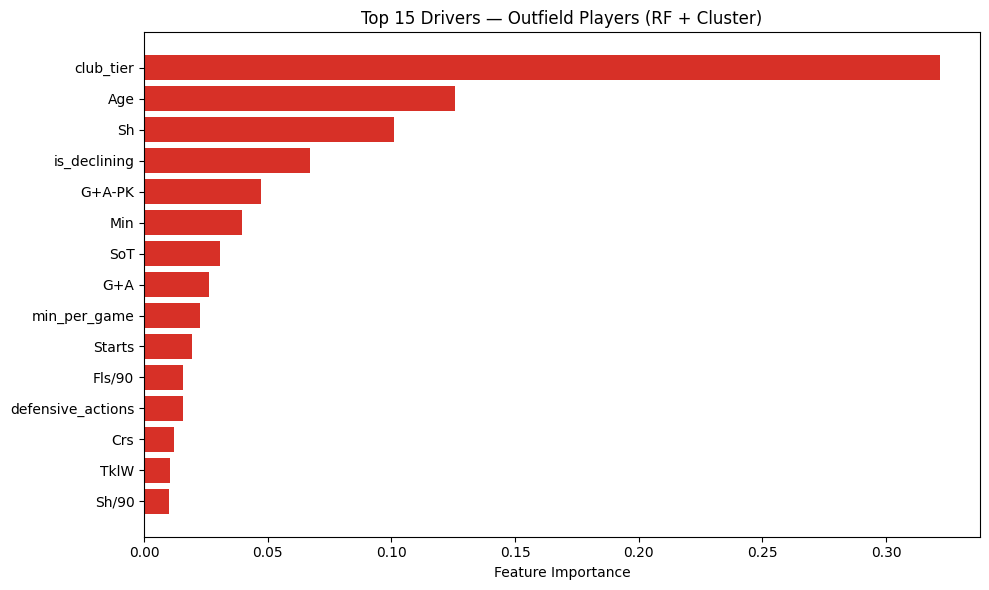


Worst 10 predictions on TEST SET:
      player_name season       actual    predicted       error
      Bukayo Saka  24-25 €150,000,000  €55,079,302 €94,920,698
  Vinicius Junior  22-23 €150,000,000  €72,791,042 €77,208,958
   Erling Haaland  22-23 €180,000,000 €106,095,701 €73,904,299
       Phil Foden  22-23 €110,000,000  €42,347,618 €67,652,382
Christian Eriksen  18-19 €100,000,000  €33,046,628 €66,953,372
      Declan Rice  24-25 €120,000,000  €54,485,464 €65,514,536
    Mohamed Salah  18-19 €150,000,000  €88,735,179 €61,264,821
  Bruno Guimarães  23-24  €85,000,000  €24,213,628 €60,786,372
   Enzo Fernández  22-23  €80,000,000  €21,270,471 €58,729,529
      Bukayo Saka  23-24 €140,000,000  €82,414,307 €57,585,693

Sample predictions from TEST SET:
        player_name season      actual   predicted
      Joris Gnagnon  17-18 €15,000,000 €20,239,982
       Frank Onyeka  21-22  €9,000,000  €2,291,942
Alireza Jahanbakhsh  19-20  €6,500,000  €2,246,698
      Mads Pedersen  22-23  €3,50

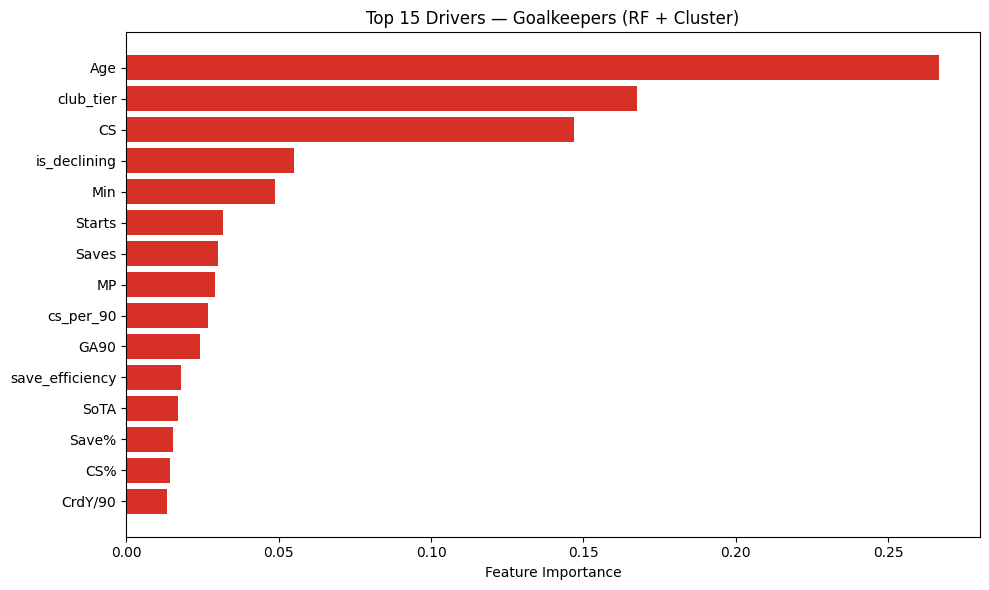


Worst 10 predictions on TEST SET:
         player_name season      actual   predicted       error
             Alisson  18-19 €80,000,000 €25,980,581 €54,019,419
    Thibaut Courtois  22-23 €45,000,000 €19,590,002 €25,409,998
    Thibaut Courtois  17-18 €60,000,000 €36,249,504 €23,750,496
          Unai Simón  24-25 €28,000,000  €6,672,875 €21,327,125
             Alisson  22-23 €35,000,000 €15,401,874 €19,598,126
Giorgi Mamardashvili  24-25 €30,000,000 €11,771,141 €18,228,859
   Guglielmo Vicario  24-25 €32,000,000 €13,882,106 €18,117,894
         Hugo Lloris  17-18 €25,000,000 €41,580,109 €16,580,109
             Alisson  23-24 €28,000,000 €11,905,217 €16,094,783
        Manuel Neuer  20-21 €18,000,000  €2,097,406 €15,902,594

Sample predictions from TEST SET:
    player_name season      actual   predicted
   Noah Atubolu  23-24 €10,000,000  €9,882,785
   Maduka Okoye  24-25  €7,500,000  €5,239,441
        Alisson  22-23 €35,000,000 €15,401,874
      Jan Oblak  17-18 €70,000,000 €58

In [74]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# ── Rebuild df_gk_active if not in scope ─────────────────────────────────────
if "df_gk_active" not in dir():
    df_gk_active = df_gk_model[df_gk_model["Min"] >= 900].copy()
    print(f"Rebuilt df_gk_active: {len(df_gk_active)} rows")

# ── Rebuild log_value if missing ──────────────────────────────────────────────
if "log_value" not in df_outfield.columns:
    df_outfield["log_value"] = np.log1p(df_outfield["value"])
if "log_value" not in df_gk_active.columns:
    df_gk_active["log_value"] = np.log1p(df_gk_active["value"])

# ── Fix duplicate columns ─────────────────────────────────────────────────────
def dedupe_columns(df):
    return df.loc[:, ~df.columns.duplicated()]

df_outfield  = dedupe_columns(df_outfield)
df_gk_active = dedupe_columns(df_gk_active)

# ── 1. RUN RF WITH CLUSTER FEATURE ───────────────────────────────────────────
def run_final_model_with_clusters(df, features, label):
    X = df[features].fillna(0)
    y = df["log_value"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  RandomForestRegressor(
            n_estimators=700,
            max_depth=12,
            min_samples_leaf=5,
            max_features=0.6,
            n_jobs=-1,
            random_state=42
        ))
    ])

    cv_r2  = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="r2")
    cv_mae = cross_val_score(pipeline, X_train, y_train, cv=5,
                             scoring="neg_mean_absolute_error")

    pipeline.fit(X_train, y_train)

    test_preds = pipeline.predict(X_test)
    test_r2    = r2_score(y_test, test_preds)
    test_mae   = mean_absolute_error(
        np.expm1(y_test), np.expm1(test_preds)
    )
    test_mse = mean_squared_error(
        np.expm1(y_test), np.expm1(test_preds)
    )
    test_rmse = np.sqrt(test_mse)

    print(f"\n── {label} | RF + Cluster Feature ──────────────────────────────")
    print(f"Train rows    : {len(X_train)}")
    print(f"Test rows     : {len(X_test)}")
    print(f"CV R²         : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}  (train set)")
    print(f"CV MAE        : {(-cv_mae.mean()):.3f} ± {cv_mae.std():.3f}  (log scale)")
    print(f"Test R²       : {test_r2:.3f}  ← honest performance on unseen data")
    print(f"Test MAE      : €{test_mae:,.0f}")
    print(f"Test MSE   : {test_mse:,.0f}")
    print(f"Test RMSE  : €{test_rmse:,.0f}")
    

    importances = pipeline.named_steps["model"].feature_importances_
    coef_df = (
        pd.DataFrame({"feature": features, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\nTop 15 drivers:")
    print(coef_df.head(15).to_string(index=False))

    # Plot
    top    = coef_df.head(15).sort_values("importance")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top["feature"], top["importance"], color="#d73027")
    ax.set_xlabel("Feature Importance")
    ax.set_title(f"Top 15 Drivers — {label} (RF + Cluster)")
    plt.tight_layout()
    plt.savefig(
        f"feature_importance_{label.lower().replace(' ', '_')}_rf_cluster.png",
        dpi=150
    )
    plt.show()

    # Predictions on full dataset
    df = df.copy()
    df["predicted_log_value"] = pipeline.predict(X)
    df["predicted_value"]     = np.expm1(df["predicted_log_value"])
    df["in_test_set"]         = False
    df.loc[X_test.index, "in_test_set"] = True

    test_df = df[df["in_test_set"]].copy()
    test_df["abs_error"] = (test_df["value"] - test_df["predicted_value"]).abs()

    print(f"\nWorst 10 predictions on TEST SET:")
    print(
        test_df.nlargest(10, "abs_error")
        .assign(
            actual    = lambda d: d["value"].map("€{:,.0f}".format),
            predicted = lambda d: d["predicted_value"].map("€{:,.0f}".format),
            error     = lambda d: d["abs_error"].map("€{:,.0f}".format)
        )[["player_name", "season", "actual", "predicted", "error"]]
        .to_string(index=False)
    )

    print(f"\nSample predictions from TEST SET:")
    print(
        test_df[["player_name", "season", "value", "predicted_value"]]
        .sample(10, random_state=42)
        .assign(
            actual    = lambda d: d["value"].map("€{:,.0f}".format),
            predicted = lambda d: d["predicted_value"].map("€{:,.0f}".format)
        )[["player_name", "season", "actual", "predicted"]]
        .to_string(index=False)
    )

    return pipeline, coef_df, df

# ── Fix duplicate columns ─────────────────────────────────────────────────────
def dedupe_columns(df):
    # Keep only the first occurrence of each column name
    df = df.loc[:, ~df.columns.duplicated()]
    return df

df_outfield  = dedupe_columns(df_outfield)
df_gk_active = dedupe_columns(df_gk_active)

print(f"df_outfield columns after dedup  : {len(df_outfield.columns)}")
print(f"df_gk_active columns after dedup : {len(df_gk_active.columns)}")

# Rebuild cluster dummy lists from what's actually in the dataframes
outfield_cluster_cols = [c for c in df_outfield.columns
                         if c.startswith("cluster_") and c != "cluster_mean_value"]
gk_cluster_cols       = [c for c in df_gk_active.columns
                         if c.startswith("cluster_") and c != "cluster_mean_value"]

print(f"\nOutfield cluster cols : {outfield_cluster_cols}")
print(f"GK cluster cols       : {gk_cluster_cols}")

# Rebuild feature lists cleanly
OUTFIELD_FEATURES_WITH_CLUSTER = [
    f for f in OUTFIELD_FEATURES_FINAL
    if f in df_outfield.columns
] + outfield_cluster_cols

GK_FEATURES_WITH_CLUSTER = [
    f for f in GK_FEATURES_FINAL
    if f in df_gk_active.columns
] + gk_cluster_cols

# Remove any duplicates in the feature lists themselves
OUTFIELD_FEATURES_WITH_CLUSTER = list(dict.fromkeys(OUTFIELD_FEATURES_WITH_CLUSTER))
GK_FEATURES_WITH_CLUSTER       = list(dict.fromkeys(GK_FEATURES_WITH_CLUSTER))

print(f"\nOutfield features with cluster : {len(OUTFIELD_FEATURES_WITH_CLUSTER)}")
print(f"GK features with cluster       : {len(GK_FEATURES_WITH_CLUSTER)}")

# ── Now run the models ────────────────────────────────────────────────────────
outfield_rf_cluster_pipeline, outfield_rf_cluster_coefs, df_outfield = run_final_model_with_clusters(
    df_outfield,  OUTFIELD_FEATURES_WITH_CLUSTER, "Outfield Players"
)
gk_rf_cluster_pipeline, gk_rf_cluster_coefs, df_gk_active = run_final_model_with_clusters(
    df_gk_active, GK_FEATURES_WITH_CLUSTER,       "Goalkeepers"
)

# ── Save ──────────────────────────────────────────────────────────────────────
pd.concat([df_outfield, df_gk_active]).to_csv(
    "model_predictions_rf_cluster.csv", index=False
)
outfield_rf_cluster_coefs.to_csv("feature_importance_outfield_rf_cluster.csv", index=False)
gk_rf_cluster_coefs.to_csv("feature_importance_gk_rf_cluster.csv",             index=False)

print("\nAll files saved.")

FULL MODEL COMPARISON TABLE
                   Dataset             Model   Rows          CV R² Test R²   Test MAE   Test RMSE             Test MSE CV-Test Gap
           All Goalkeepers Linear Regression  1,122  0.657 ± 0.034   0.615 €4,830,968  €9,111,689  €83,022,883,849,659      +0.042
           All Goalkeepers     Random Forest  1,122  0.655 ± 0.019   0.599 €4,584,360  €8,740,140  €76,390,055,491,023      +0.056
All Goalkeepers + Clusters     Random Forest    983  0.611 ± 0.033   0.695 €4,146,082  €7,241,039  €52,432,646,832,940      -0.084
              All Outfield Linear Regression 14,990  0.576 ± 0.015   0.590 €6,231,560 €11,283,746 €127,322,921,093,611      -0.014
              All Outfield     Random Forest 14,990  0.615 ± 0.011   0.633 €5,871,577 €10,614,348 €112,664,379,266,242      -0.018
   All Outfield + Clusters     Random Forest 14,990  0.615 ± 0.011   0.633 €5,871,577 €10,614,348 €112,664,379,266,242      -0.018
                Bundesliga Linear Regression  2,723  0.

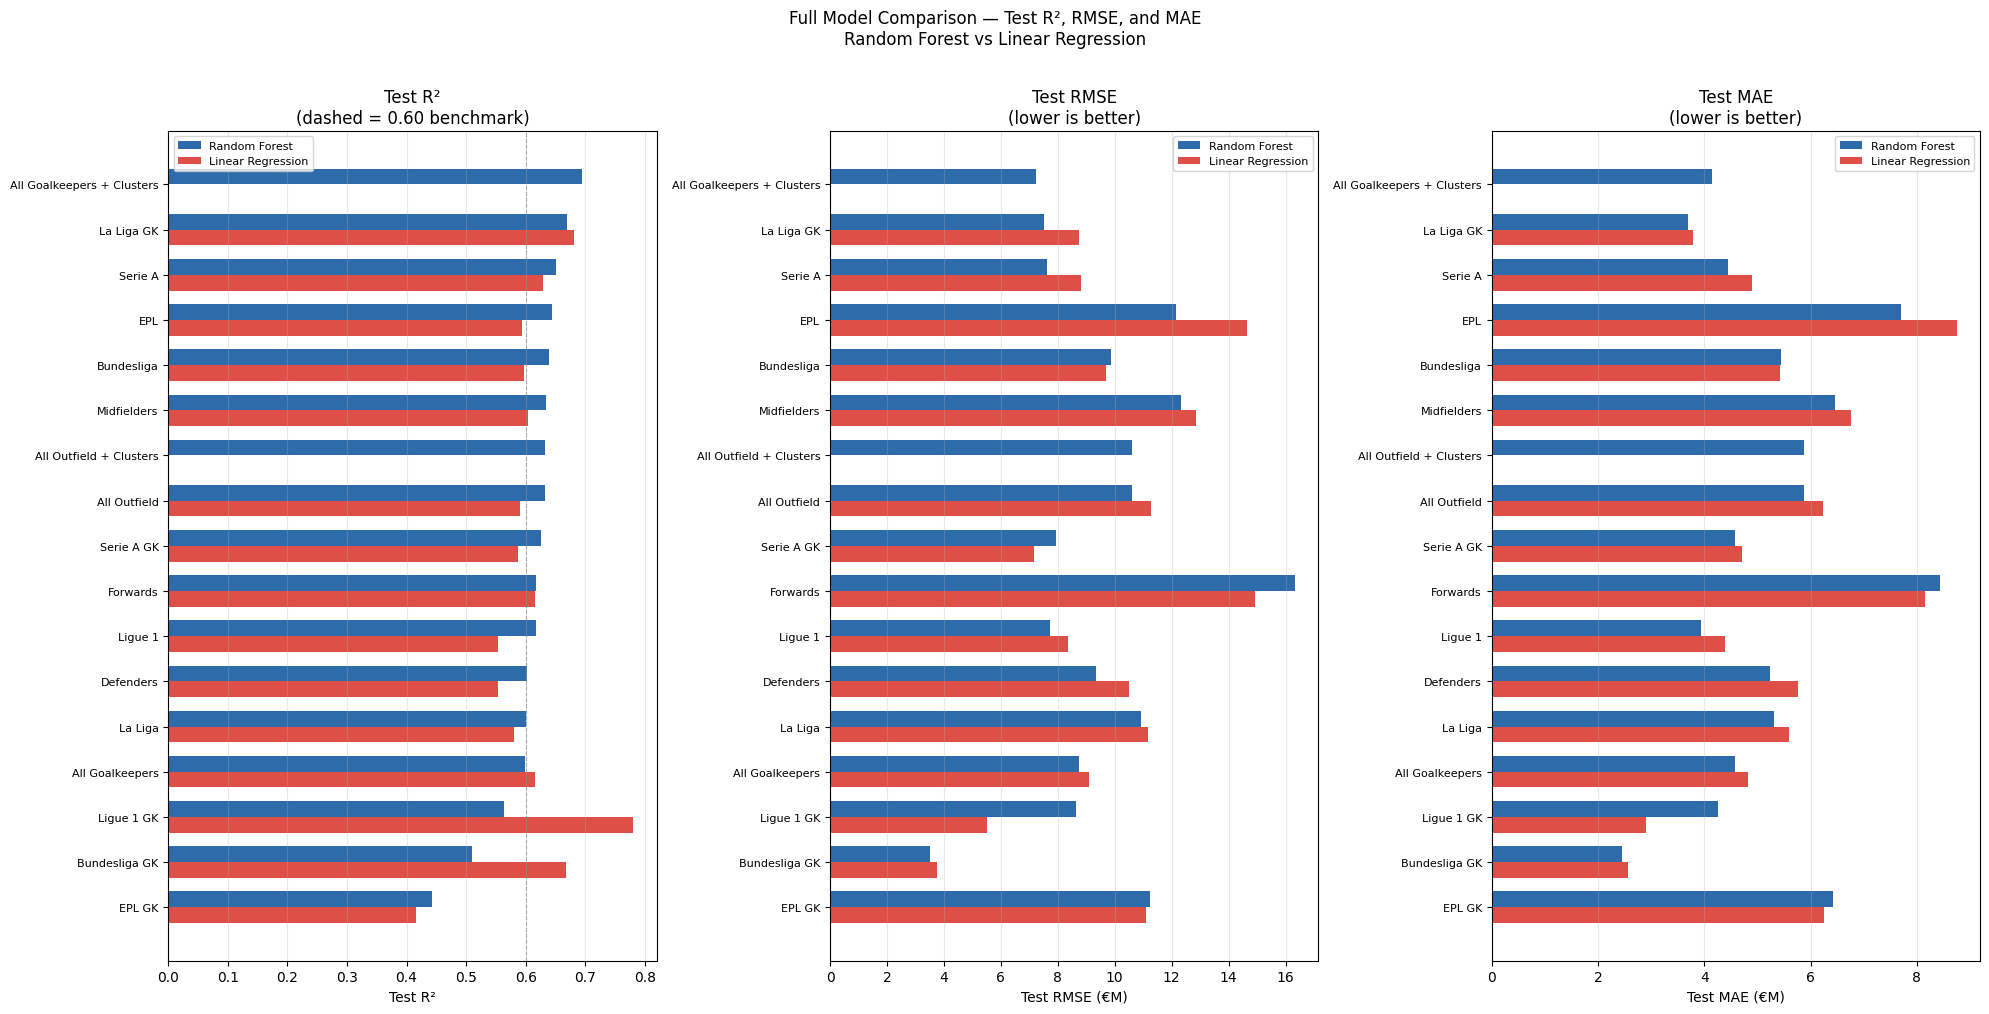


Saved to full_model_comparison.csv and full_model_comparison.png


In [75]:
# Compares the models

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# ── Helper to extract metrics from an already-fitted pipeline ─────────────────
def extract_metrics(label, model_type, pipeline, df, features):
    X = df[features].fillna(0)
    y = df["log_value"]

    # Reproduce the exact same split used during training
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # CV on train set
    cv_r2 = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="r2")

    # Test set evaluation
    test_preds = pipeline.predict(X_test)
    test_r2    = r2_score(y_test, test_preds)
    test_mae   = mean_absolute_error(np.expm1(y_test), np.expm1(test_preds))
    test_mse   = mean_squared_error(np.expm1(y_test),  np.expm1(test_preds))
    test_rmse  = np.sqrt(test_mse)

    return {
        "label":      label,
        "model_type": model_type,
        "n_rows":     len(df),
        "cv_r2":      round(cv_r2.mean(), 3),
        "cv_r2_std":  round(cv_r2.std(),  3),
        "test_r2":    round(test_r2,       3),
        "test_mae":   round(test_mae,      0),
        "test_mse":   round(test_mse,      0),
        "test_rmse":  round(test_rmse,     0),
    }

# ── Extract metrics from all models ──────────────────────────────────────────
all_metrics = []

# 1) All Outfield
all_metrics.append(extract_metrics(
    "All Outfield", "Random Forest",
    outfield_rf_pipeline, df_outfield, OUTFIELD_FEATURES_FINAL
))
all_metrics.append(extract_metrics(
    "All Outfield", "Linear Regression",
    outfield_lr_pipeline, df_outfield, OUTFIELD_FEATURES_FINAL
))

# 2) All Goalkeepers
all_metrics.append(extract_metrics(
    "All Goalkeepers", "Random Forest",
    gk_rf_pipeline, df_gk_model, GK_FEATURES_FINAL
))
all_metrics.append(extract_metrics(
    "All Goalkeepers", "Linear Regression",
    gk_pipeline, df_gk_model, GK_FEATURES_FINAL
))

# 3) EPL
all_metrics.append(extract_metrics(
    "EPL", "Random Forest",
    epl_rf_outfield_pipeline, df_epl_outfield, EPL_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "EPL", "Linear Regression",
    epl_lr_outfield_pipeline, df_epl_outfield, EPL_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "EPL GK", "Random Forest",
    epl_rf_gk_pipeline, df_epl_gk, EPL_GK_FEATURES
))
all_metrics.append(extract_metrics(
    "EPL GK", "Linear Regression",
    epl_lr_gk_pipeline, df_epl_gk, EPL_GK_FEATURES
))

# 4) Bundesliga
all_metrics.append(extract_metrics(
    "Bundesliga", "Random Forest",
    bundesliga_rf_outfield_pipeline, df_bundesliga_outfield, BUNDESLIGA_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "Bundesliga", "Linear Regression",
    bundesliga_lr_outfield_pipeline, df_bundesliga_outfield, BUNDESLIGA_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "Bundesliga GK", "Random Forest",
    bundesliga_rf_gk_pipeline, df_bundesliga_gk, BUNDESLIGA_GK_FEATURES
))
all_metrics.append(extract_metrics(
    "Bundesliga GK", "Linear Regression",
    bundesliga_lr_gk_pipeline, df_bundesliga_gk, BUNDESLIGA_GK_FEATURES
))

# 5) La Liga
all_metrics.append(extract_metrics(
    "La Liga", "Random Forest",
    la_liga_rf_outfield_pipeline, df_la_liga_outfield, LA_LIGA_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "La Liga", "Linear Regression",
    la_liga_lr_outfield_pipeline, df_la_liga_outfield, LA_LIGA_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "La Liga GK", "Random Forest",
    la_liga_rf_gk_pipeline, df_la_liga_gk, LA_LIGA_GK_FEATURES
))
all_metrics.append(extract_metrics(
    "La Liga GK", "Linear Regression",
    la_liga_lr_gk_pipeline, df_la_liga_gk, LA_LIGA_GK_FEATURES
))

# 6) Serie A
all_metrics.append(extract_metrics(
    "Serie A", "Random Forest",
    serie_a_rf_outfield_pipeline, df_serie_a_outfield, SERIE_A_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "Serie A", "Linear Regression",
    serie_a_lr_outfield_pipeline, df_serie_a_outfield, SERIE_A_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "Serie A GK", "Random Forest",
    serie_a_rf_gk_pipeline, df_serie_a_gk, SERIE_A_GK_FEATURES
))
all_metrics.append(extract_metrics(
    "Serie A GK", "Linear Regression",
    serie_a_lr_gk_pipeline, df_serie_a_gk, SERIE_A_GK_FEATURES
))

# 7) Ligue 1
all_metrics.append(extract_metrics(
    "Ligue 1", "Random Forest",
    ligue1_rf_outfield_pipeline, df_ligue1_outfield, LIGUE1_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "Ligue 1", "Linear Regression",
    ligue1_lr_outfield_pipeline, df_ligue1_outfield, LIGUE1_OUTFIELD_FEATURES
))
all_metrics.append(extract_metrics(
    "Ligue 1 GK", "Random Forest",
    ligue1_rf_gk_pipeline, df_ligue1_gk, LIGUE1_GK_FEATURES
))
all_metrics.append(extract_metrics(
    "Ligue 1 GK", "Linear Regression",
    ligue1_lr_gk_pipeline, df_ligue1_gk, LIGUE1_GK_FEATURES
))

# 8) Forwards
all_metrics.append(extract_metrics(
    "Forwards", "Random Forest",
    fw_rf_pipeline, df_fw, FW_FEATURES
))
all_metrics.append(extract_metrics(
    "Forwards", "Linear Regression",
    fw_lr_pipeline, df_fw, FW_FEATURES
))

# 9) Midfielders
all_metrics.append(extract_metrics(
    "Midfielders", "Random Forest",
    mf_rf_pipeline, df_mf, MF_FEATURES
))
all_metrics.append(extract_metrics(
    "Midfielders", "Linear Regression",
    mf_lr_pipeline, df_mf, MF_FEATURES
))

# 10) Defenders
all_metrics.append(extract_metrics(
    "Defenders", "Random Forest",
    def_rf_pipeline, df_def, DF_FEATURES
))
all_metrics.append(extract_metrics(
    "Defenders", "Linear Regression",
    def_lr_pipeline, df_def, DEF_FEATURES
))

# 11) Outfield + Clusters
all_metrics.append(extract_metrics(
    "All Outfield + Clusters", "Random Forest",
    outfield_rf_cluster_pipeline, df_outfield, OUTFIELD_FEATURES_WITH_CLUSTER
))

# 12) GK + Clusters
all_metrics.append(extract_metrics(
    "All Goalkeepers + Clusters", "Random Forest",
    gk_rf_cluster_pipeline, df_gk_active, GK_FEATURES_WITH_CLUSTER
))

# ── Build and print table ─────────────────────────────────────────────────────
metrics_df = pd.DataFrame(all_metrics)

print("=" * 110)
print("FULL MODEL COMPARISON TABLE")
print("=" * 110)
print(
    metrics_df
    .assign(
        CV_R2    = lambda d: d.apply(
            lambda r: f"{r['cv_r2']:.3f} ± {r['cv_r2_std']:.3f}", axis=1
        ),
        Test_R2  = lambda d: d["test_r2"].map("{:.3f}".format),
        Test_MAE = lambda d: d["test_mae"].map("€{:,.0f}".format),
        Test_MSE = lambda d: d["test_mse"].map("€{:,.0f}".format),
        Test_RMSE= lambda d: d["test_rmse"].map("€{:,.0f}".format),
        Gap      = lambda d: (d["cv_r2"] - d["test_r2"]).map("{:+.3f}".format),
        N        = lambda d: d["n_rows"].map("{:,}".format),
    )
    [["label", "model_type", "N", "CV_R2", "Test_R2", "Test_MAE",
      "Test_RMSE", "Test_MSE", "Gap"]]
    .rename(columns={
        "label":      "Dataset",
        "model_type": "Model",
        "N":          "Rows",
        "CV_R2":      "CV R²",
        "Test_R2":    "Test R²",
        "Test_MAE":   "Test MAE",
        "Test_RMSE":  "Test RMSE",
        "Test_MSE":   "Test MSE",
        "Gap":        "CV-Test Gap",
    })
    .sort_values(["Dataset", "Model"])
    .to_string(index=False)
)

# ── Plot Test R² comparison ───────────────────────────────────────────────────
rf_df = (
    metrics_df[metrics_df["model_type"] == "Random Forest"]
    .sort_values("test_r2")
    .reset_index(drop=True)
)
lr_df = (
    metrics_df[metrics_df["model_type"] == "Linear Regression"]
    .set_index("label")
    .reindex(rf_df["label"])
    .reset_index()
)

y_pos  = np.arange(len(rf_df))
height = 0.35

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# ── Plot 1: Test R² ───────────────────────────────────────────────────────────
axes[0].barh(
    y_pos + height / 2, rf_df["test_r2"],
    height=height, color="#08519c", label="Random Forest", alpha=0.85
)
axes[0].barh(
    y_pos - height / 2, lr_df["test_r2"].fillna(0),
    height=height, color="#d73027", label="Linear Regression", alpha=0.85
)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(rf_df["label"], fontsize=8)
axes[0].axvline(0.6, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
axes[0].set_xlabel("Test R²")
axes[0].set_title("Test R²\n(dashed = 0.60 benchmark)")
axes[0].legend(fontsize=8)
axes[0].grid(axis="x", alpha=0.3)

# ── Plot 2: Test RMSE ─────────────────────────────────────────────────────────
axes[1].barh(
    y_pos + height / 2, rf_df["test_rmse"] / 1e6,
    height=height, color="#08519c", label="Random Forest", alpha=0.85
)
axes[1].barh(
    y_pos - height / 2, lr_df["test_rmse"].fillna(0) / 1e6,
    height=height, color="#d73027", label="Linear Regression", alpha=0.85
)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(rf_df["label"], fontsize=8)
axes[1].set_xlabel("Test RMSE (€M)")
axes[1].set_title("Test RMSE\n(lower is better)")
axes[1].legend(fontsize=8)
axes[1].grid(axis="x", alpha=0.3)

# ── Plot 3: Test MAE ──────────────────────────────────────────────────────────
axes[2].barh(
    y_pos + height / 2, rf_df["test_mae"] / 1e6,
    height=height, color="#08519c", label="Random Forest", alpha=0.85
)
axes[2].barh(
    y_pos - height / 2, lr_df["test_mae"].fillna(0) / 1e6,
    height=height, color="#d73027", label="Linear Regression", alpha=0.85
)
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels(rf_df["label"], fontsize=8)
axes[2].set_xlabel("Test MAE (€M)")
axes[2].set_title("Test MAE\n(lower is better)")
axes[2].legend(fontsize=8)
axes[2].grid(axis="x", alpha=0.3)

plt.suptitle(
    "Full Model Comparison — Test R², RMSE, and MAE\nRandom Forest vs Linear Regression",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig("full_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Save ──────────────────────────────────────────────────────────────────────
metrics_df.to_csv("full_model_comparison.csv", index=False)
print("\nSaved to full_model_comparison.csv and full_model_comparison.png")

Markdown for how the assignment is.